In [1]:
!pip install biopython


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from Bio import Entrez
from contextlib import contextmanager
import hashlib
import json
import os
from pathlib import Path
import sqlite3
import time

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, MultipleLocator, PercentFormatter
import seaborn as sns

# Always provide your email when using Entrez.
Entrez.email = "user@example.com"

# Persistent local cache. Override with PUBMED_CACHE_PATH if desired.
PUBMED_CACHE_PATH = Path(
    os.environ.get(
        "PUBMED_CACHE_PATH",
        Path.cwd() / ".pubmed_cache" / "pubmed_counts.sqlite3",
    )
)
PUBMED_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)


def _normalize_pubmed_query(query):
    """Canonicalize harmless formatting differences without changing quoted terms."""
    collapsed = " ".join(query.split())
    normalized = []
    inside_quotes = False
    for index, character in enumerate(collapsed):
        if character == '"':
            inside_quotes = not inside_quotes
            normalized.append(character)
            continue
        if character == " " and not inside_quotes:
            previous_character = collapsed[index - 1] if index else ""
            next_character = collapsed[index + 1] if index + 1 < len(collapsed) else ""
            if previous_character == "(" or next_character == ")":
                continue
        normalized.append(character)
    return "".join(normalized)


def _pubmed_query_key(query):
    normalized_query = _normalize_pubmed_query(query)
    return hashlib.sha256(normalized_query.encode("utf-8")).hexdigest()


@contextmanager
def _open_pubmed_cache():
    connection = sqlite3.connect(PUBMED_CACHE_PATH, timeout=30)
    try:
        connection.execute(
            """
            CREATE TABLE IF NOT EXISTS annual_counts (
                query_key TEXT NOT NULL,
                normalized_query TEXT NOT NULL,
                year INTEGER NOT NULL,
                count INTEGER NOT NULL,
                fetched_at TEXT NOT NULL DEFAULT CURRENT_TIMESTAMP,
                PRIMARY KEY (query_key, year)
            )
            """
        )
        connection.execute(
            """
            CREATE TABLE IF NOT EXISTS target_year_counts (
                query_key TEXT PRIMARY KEY,
                normalized_query TEXT NOT NULL,
                start_year INTEGER NOT NULL,
                end_year INTEGER NOT NULL,
                yearly_counts_json TEXT NOT NULL,
                total_records INTEGER NOT NULL,
                fetched_at TEXT NOT NULL DEFAULT CURRENT_TIMESTAMP
            )
            """
        )
        yield connection
        connection.commit()
    except Exception:
        connection.rollback()
        raise
    finally:
        connection.close()


def read_entrez_with_retries(request_factory, label, max_attempts=3):
    for attempt in range(1, max_attempts + 1):
        try:
            with request_factory() as handle:
                result = Entrez.read(handle)
            # NCBI permits at most three unauthenticated requests per second.
            time.sleep(0.35)
            return result
        except Exception as error:
            if attempt == max_attempts:
                raise RuntimeError(f"PubMed request failed for {label}") from error
            wait_seconds = 2 ** attempt
            print(f"Retrying {label} in {wait_seconds} seconds...")
            time.sleep(wait_seconds)


def get_pubmed_counts(term, start_year, end_year, force_refresh=False):
    """Return annual PubMed counts, fetching only years absent from the cache."""
    normalized_query = _normalize_pubmed_query(term)
    query_key = _pubmed_query_key(term)
    requested_years = list(range(start_year, end_year + 1))

    with _open_pubmed_cache() as connection:
        cached_counts = {
            int(year): int(count)
            for year, count in connection.execute(
                """
                SELECT year, count
                FROM annual_counts
                WHERE query_key = ? AND year BETWEEN ? AND ?
                """,
                (query_key, start_year, end_year),
            )
        }

    missing_years = requested_years if force_refresh else [
        year for year in requested_years if year not in cached_counts
    ]
    print(
        f"PubMed cache: {len(requested_years) - len(missing_years)} hit(s), "
        f"{len(missing_years)} year(s) to fetch."
    )

    for year in missing_years:
        search_query = f"({term}) AND ({year}[pdat])"
        record = read_entrez_with_retries(
            lambda search_query=search_query: Entrez.esearch(
                db="pubmed", term=search_query, retmax=0
            ),
            f"annual count for {year}",
        )
        count = int(record["Count"])
        cached_counts[year] = count
        # Cache only successful responses; transient failures are never stored as zero.
        with _open_pubmed_cache() as connection:
            connection.execute(
                """
                INSERT INTO annual_counts
                    (query_key, normalized_query, year, count, fetched_at)
                VALUES (?, ?, ?, ?, CURRENT_TIMESTAMP)
                ON CONFLICT(query_key, year) DO UPDATE SET
                    normalized_query = excluded.normalized_query,
                    count = excluded.count,
                    fetched_at = CURRENT_TIMESTAMP
                """,
                (query_key, normalized_query, year, count),
            )

    return [cached_counts[year] for year in requested_years]


def pubmed_cache_info():
    """Display the local cache location and number of stored query results."""
    with _open_pubmed_cache() as connection:
        annual_rows = connection.execute(
            "SELECT COUNT(*) FROM annual_counts"
        ).fetchone()[0]
        target_rows = connection.execute(
            "SELECT COUNT(*) FROM target_year_counts"
        ).fetchone()[0]
    return {
        "path": str(PUBMED_CACHE_PATH.resolve()),
        "annual query-year results": annual_rows,
        "target query-range results": target_rows,
    }


## Persistent local PubMed cache

PubMed results are stored in `.pubmed_cache/pubmed_counts.sqlite3`. The cache key is derived from the normalized complete query, with annual counts stored separately by year. Rerunning an existing analysis therefore makes no PubMed requests; a newly added query fetches only its missing years. Molecular-target searches are cached by their complete context, aliases, and date range as well.

Use `force_refresh=True` with `get_pubmed_counts(...)` or `get_target_year_counts(...)` when a deliberate refresh is needed. `pubmed_cache_info()` reports the cache location and number of stored results. Failed requests are not cached.


In [3]:
NEURO_ONCOLOGY_QUERY = """
(
    "Nervous System Neoplasms"[Mesh]
    OR
    (
        "Glioblastoma" OR "Glioblastoma Multiforme" OR "Astrocytoma" OR "Oligodendroglioma"
        OR "Diffuse Midline Glioma" OR "H3 K27-altered" OR "Pilocytic Astrocytoma"
        OR "Pleomorphic Xanthoastrocytoma" OR "Subependymal Giant Cell Astrocytoma"
        OR "Ependymoma" OR "Myxopapillary ependymoma" OR "Ganglioglioma"
        OR "Dysembryoplastic Neuroepithelial Tumor" OR "DNET" OR "Central Neurocytoma"
        OR "Glioma" OR "DIPG" OR "Diffuse Midline Pontine Glioma" OR "Medulloblastoma"
        OR "Atypical Teratoid Rhabdoid Tumor" OR "Pineoblastoma" OR "Germinoma"
        OR "Meningioma" OR "Pituitary Adenoma" OR "Pituitary Neuroendocrine Tumor"
        OR "PNET" OR "Craniopharyngioma" OR "Vestibular Schwannoma"
        OR "Brain Metastasis" OR "Brain Metastases" OR "Leptomeningeal Disease"
        OR "Leptomeningeal Carcinomatosis" OR "Primary CNS Lymphoma" OR "Hemangioblastoma"
        OR "Choroid Plexus Papilloma"
    )
)
""".strip()

GENERAL_NEUROSCIENCE_QUERY = """
(
    ("Nervous System Diseases"[Mesh] OR "Neurology"[Mesh] OR "Neurologic Manifestations"[Mesh])
    OR
    (
        "Stroke" OR "Cerebrovascular Accident" OR "CVA" OR "Ischemic Stroke"
        OR "Intracerebral Hemorrhage" OR "Hemorrhagic Stroke" OR "Subarachnoid Hemorrhage"
        OR "Transient Ischemic Attack" OR "TIA" OR "Cerebral Aneurysm"
        OR "Arteriovenous Malformation" OR "AVM" OR "Cavernous Angioma" OR "Cavernoma"
        OR "Moyamoya Disease" OR "Cerebral Venous Sinus Thrombosis" OR "Alzheimer Disease"
        OR "Alzheimer's Disease" OR "Parkinson Disease" OR "Parkinson's Disease"
        OR "Amyotrophic Lateral Sclerosis" OR "ALS" OR "Frontotemporal Dementia"
        OR "Frontotemporal Lobar Degeneration" OR "Lewy Body Dementia"
        OR "Dementia with Lewy Bodies" OR "Huntington Disease" OR "Huntington's Disease"
        OR "Creutzfeldt-Jakob Disease" OR "Prion Disease" OR "Corticobasal Degeneration"
        OR "Multiple System Atrophy" OR "Shy-Drager Syndrome" OR "Progressive Supranuclear Palsy"
        OR "Multiple Sclerosis" OR "Relapsing-Remitting MS" OR "Neuromyelitis Optica"
        OR "NMO" OR "Devic's Disease" OR "MOG Antibody Disease" OR "MOGAD"
        OR "Acute Disseminated Encephalomyelitis" OR "ADEM"
        OR "Anti-NMDA Receptor Encephalitis" OR "Autoimmune Encephalitis"
        OR "Stiff-Person Syndrome" OR "Epilepsy" OR "Seizure Disorder"
        OR "Status Epilepticus" OR "Temporal Lobe Epilepsy" OR "Lennox-Gastaut Syndrome"
        OR "Dravet Syndrome" OR "West Syndrome" OR "Infantile Spasms"
        OR "Migraine Disorders" OR "Migraine" OR "Cluster Headache" OR "Trigeminal Neuralgia"
        OR "Idiopathic Intracranial Hypertension" OR "Pseudotumor Cerebri"
        OR "Myasthenia Gravis" OR "Guillain-Barre Syndrome" OR "GBS"
        OR "Chronic Inflammatory Demyelinating Polyneuropathy" OR "CIDP"
        OR "Lambert-Eaton Myasthenic Syndrome" OR "Charcot-Marie-Tooth Disease"
        OR "Duchenne Muscular Dystrophy" OR "Spinal Muscular Atrophy" OR "SMA"
        OR "Complex Regional Pain Syndrome" OR "CRPS" OR "Essential Tremor" OR "Dystonia"
        OR "Cervical Dystonia" OR "Tourette Syndrome" OR "Restless Legs Syndrome"
        OR "Ataxia" OR "Spinocerebellar Ataxia" OR "Friedreich Ataxia" OR "Wilson Disease"
        OR "Meningitis" OR "Encephalitis" OR "Brain Abscess" OR "Neurosyphilis"
        OR "Traumatic Brain Injury" OR "TBI" OR "Chronic Traumatic Encephalopathy"
        OR "CTE" OR "Concussion" OR "Spinal Cord Injury" OR "Hydrocephalus"
        OR "Normal Pressure Hydrocephalus" OR "NPH" OR "Chiari Malformation"
        OR "Spina Bifida" OR "Myelomeningocele" OR "Syringomyelia"
    )
)
""".strip()

start_year = 2000
end_year = 2025
years = list(range(start_year, end_year + 1))

print("Fetching general neuroscience publications...")
general_neuroscience_counts = get_pubmed_counts(GENERAL_NEUROSCIENCE_QUERY, start_year, end_year)

print("Fetching neuro-oncology publications...")
neuro_oncology_counts = get_pubmed_counts(NEURO_ONCOLOGY_QUERY, start_year, end_year)

df_pubs = pd.DataFrame({
    "Year": years,
    "General neuroscience": general_neuroscience_counts,
    "Neuro-oncology": neuro_oncology_counts,
})

df_pubs["Neuro-oncology proportion"] = (
    df_pubs["Neuro-oncology"] / df_pubs["General neuroscience"]
)

display(df_pubs.head())

Fetching general neuroscience publications...
PubMed cache: 26 hit(s), 0 year(s) to fetch.
Fetching neuro-oncology publications...
PubMed cache: 26 hit(s), 0 year(s) to fetch.


,Year,General neuroscience,Neuro-oncology,Neuro-oncology proportion
0,2000,60889,5332,0.087569
1,2001,62557,5286,0.084499
2,2002,64356,5164,0.080241
3,2003,69084,5655,0.081857
4,2004,74309,5853,0.078766


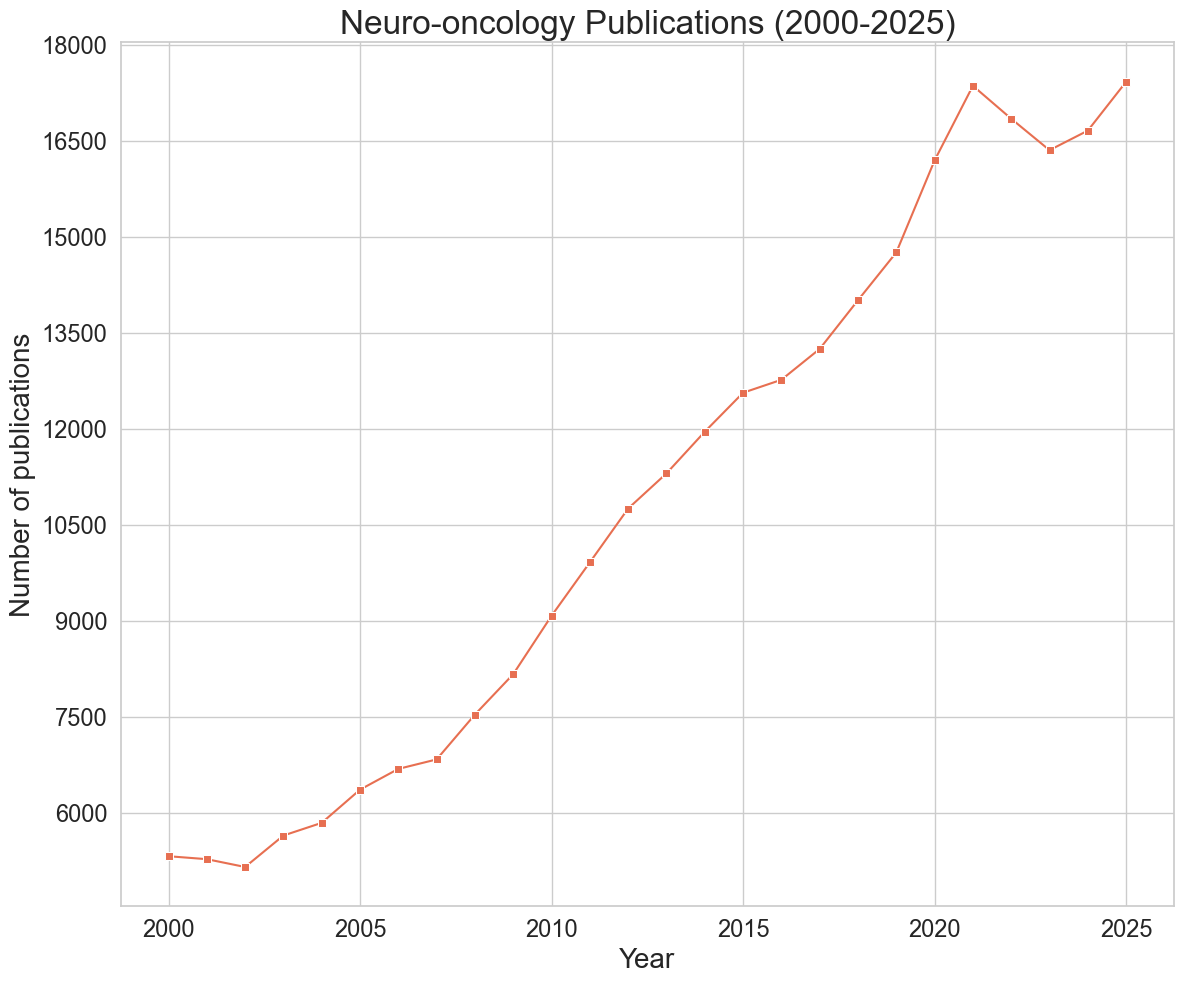

In [4]:
# Set seaborn style
sns.set_theme(style="whitegrid")

# Plot 1: Neuro-oncology literature only
plt.figure(figsize=(12, 10))
sns.lineplot(
    data=df_pubs,
    x="Year",
    y="Neuro-oncology",
    color="#E76F51",
    marker="s",
)
plt.title("Neuro-oncology Publications (2000-2025)", fontsize=24)
plt.ylabel("Number of publications", fontsize=20)
plt.xlabel("Year", fontsize=20)
plt.tick_params(axis="both", labelsize=17)
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

## Top 2025 disease keywords and their historical movement

The candidate keywords are limited to the disease phrases explicitly listed in `NEURO_ONCOLOGY_QUERY`. Each phrase is searched exactly in PubMed's Title/Abstract field within the notebook's neuro-oncology scope. The ten phrases with the largest 2025 publication counts are then tracked annually from 2000 through 2025. Candidate phrases are ranked separately rather than merged into synonym groups.


In [5]:
NEURO_ONCOLOGY_DISEASE_KEYWORDS = [
    "Glioblastoma",
    "Glioblastoma Multiforme",
    "Astrocytoma",
    "Oligodendroglioma",
    "Diffuse Midline Glioma",
    "H3 K27-altered",
    "Pilocytic Astrocytoma",
    "Pleomorphic Xanthoastrocytoma",
    "Subependymal Giant Cell Astrocytoma",
    "Ependymoma",
    "Myxopapillary ependymoma",
    "Ganglioglioma",
    "Dysembryoplastic Neuroepithelial Tumor",
    "DNET",
    "Central Neurocytoma",
    "Glioma",
    "DIPG",
    "Diffuse Midline Pontine Glioma",
    "Medulloblastoma",
    "Atypical Teratoid Rhabdoid Tumor",
    "Pineoblastoma",
    "Germinoma",
    "Meningioma",
    "Pituitary Adenoma",
    "Pituitary Neuroendocrine Tumor",
    "PNET",
    "Craniopharyngioma",
    "Vestibular Schwannoma",
    "Brain Metastasis",
    "Brain Metastases",
    "Leptomeningeal Disease",
    "Leptomeningeal Carcinomatosis",
    "Primary CNS Lymphoma",
    "Hemangioblastoma",
    "Choroid Plexus Papilloma",
]


def disease_keyword_query(keyword):
    safe_keyword = keyword.replace(chr(34), "")
    return f'({NEURO_ONCOLOGY_QUERY}) AND ("{safe_keyword}"[Title/Abstract])'


keyword_2025_rows = []
for keyword in NEURO_ONCOLOGY_DISEASE_KEYWORDS:
    print(f"Fetching 2025 count for {keyword}...")
    publication_count = get_pubmed_counts(
        disease_keyword_query(keyword), 2025, 2025
    )[0]
    keyword_2025_rows.append(
        {"Keyword": keyword, "Publications in 2025": publication_count}
    )

disease_keyword_ranking_2025 = (
    pd.DataFrame(keyword_2025_rows)
    .sort_values(["Publications in 2025", "Keyword"], ascending=[False, True])
    .reset_index(drop=True)
)
disease_keyword_ranking_2025.insert(
    0, "Rank", range(1, len(disease_keyword_ranking_2025) + 1)
)
top_2025_disease_keywords = disease_keyword_ranking_2025.head(10).copy()

display(
    top_2025_disease_keywords.style
    .hide(axis="index")
    .set_caption(
        "Top ten 2025 neuro-oncology disease keywords from the prespecified candidate list"
    )
)


Fetching 2025 count for Glioblastoma...
PubMed cache: 1 hit(s), 0 year(s) to fetch.
Fetching 2025 count for Glioblastoma Multiforme...
PubMed cache: 1 hit(s), 0 year(s) to fetch.
Fetching 2025 count for Astrocytoma...
PubMed cache: 1 hit(s), 0 year(s) to fetch.
Fetching 2025 count for Oligodendroglioma...
PubMed cache: 1 hit(s), 0 year(s) to fetch.
Fetching 2025 count for Diffuse Midline Glioma...
PubMed cache: 1 hit(s), 0 year(s) to fetch.
Fetching 2025 count for H3 K27-altered...
PubMed cache: 1 hit(s), 0 year(s) to fetch.
Fetching 2025 count for Pilocytic Astrocytoma...
PubMed cache: 1 hit(s), 0 year(s) to fetch.
Fetching 2025 count for Pleomorphic Xanthoastrocytoma...
PubMed cache: 1 hit(s), 0 year(s) to fetch.
Fetching 2025 count for Subependymal Giant Cell Astrocytoma...
PubMed cache: 1 hit(s), 0 year(s) to fetch.
Fetching 2025 count for Ependymoma...
PubMed cache: 1 hit(s), 0 year(s) to fetch.
Fetching 2025 count for Myxopapillary ependymoma...
PubMed cache: 1 hit(s), 0 year(s) 

Rank,Keyword,Publications in 2025
1,Glioblastoma,5119
2,Glioma,4648
3,Brain Metastases,1607
4,Meningioma,1318
5,Brain Metastasis,1011
6,Glioblastoma Multiforme,716
7,Pituitary Adenoma,565
8,Astrocytoma,563
9,Medulloblastoma,475
10,Vestibular Schwannoma,420


In [6]:
keyword_trend_frames = []
for keyword_row in top_2025_disease_keywords.itertuples(index=False):
    keyword = keyword_row.Keyword
    keyword_counts = get_pubmed_counts(
        disease_keyword_query(keyword), 2000, 2025
    )
    keyword_trend_frames.append(
        pd.DataFrame(
            {
                "Rank": keyword_row.Rank,
                "Keyword": keyword,
                "Ranked keyword": f"{keyword_row.Rank}. {keyword}",
                "Year": range(2000, 2026),
                "Publications": keyword_counts,
            }
        )
    )
keyword_trends = pd.concat(keyword_trend_frames, ignore_index=True)
keyword_trends.head()


PubMed cache: 26 hit(s), 0 year(s) to fetch.
PubMed cache: 26 hit(s), 0 year(s) to fetch.
PubMed cache: 26 hit(s), 0 year(s) to fetch.
PubMed cache: 26 hit(s), 0 year(s) to fetch.
PubMed cache: 26 hit(s), 0 year(s) to fetch.
PubMed cache: 26 hit(s), 0 year(s) to fetch.
PubMed cache: 26 hit(s), 0 year(s) to fetch.
PubMed cache: 26 hit(s), 0 year(s) to fetch.
PubMed cache: 26 hit(s), 0 year(s) to fetch.
PubMed cache: 26 hit(s), 0 year(s) to fetch.


,Rank,Keyword,Ranked keyword,Year,Publications
0,1,Glioblastoma,1. Glioblastoma,2000,428
1,1,Glioblastoma,1. Glioblastoma,2001,458
2,1,Glioblastoma,1. Glioblastoma,2002,429
3,1,Glioblastoma,1. Glioblastoma,2003,498
4,1,Glioblastoma,1. Glioblastoma,2004,571


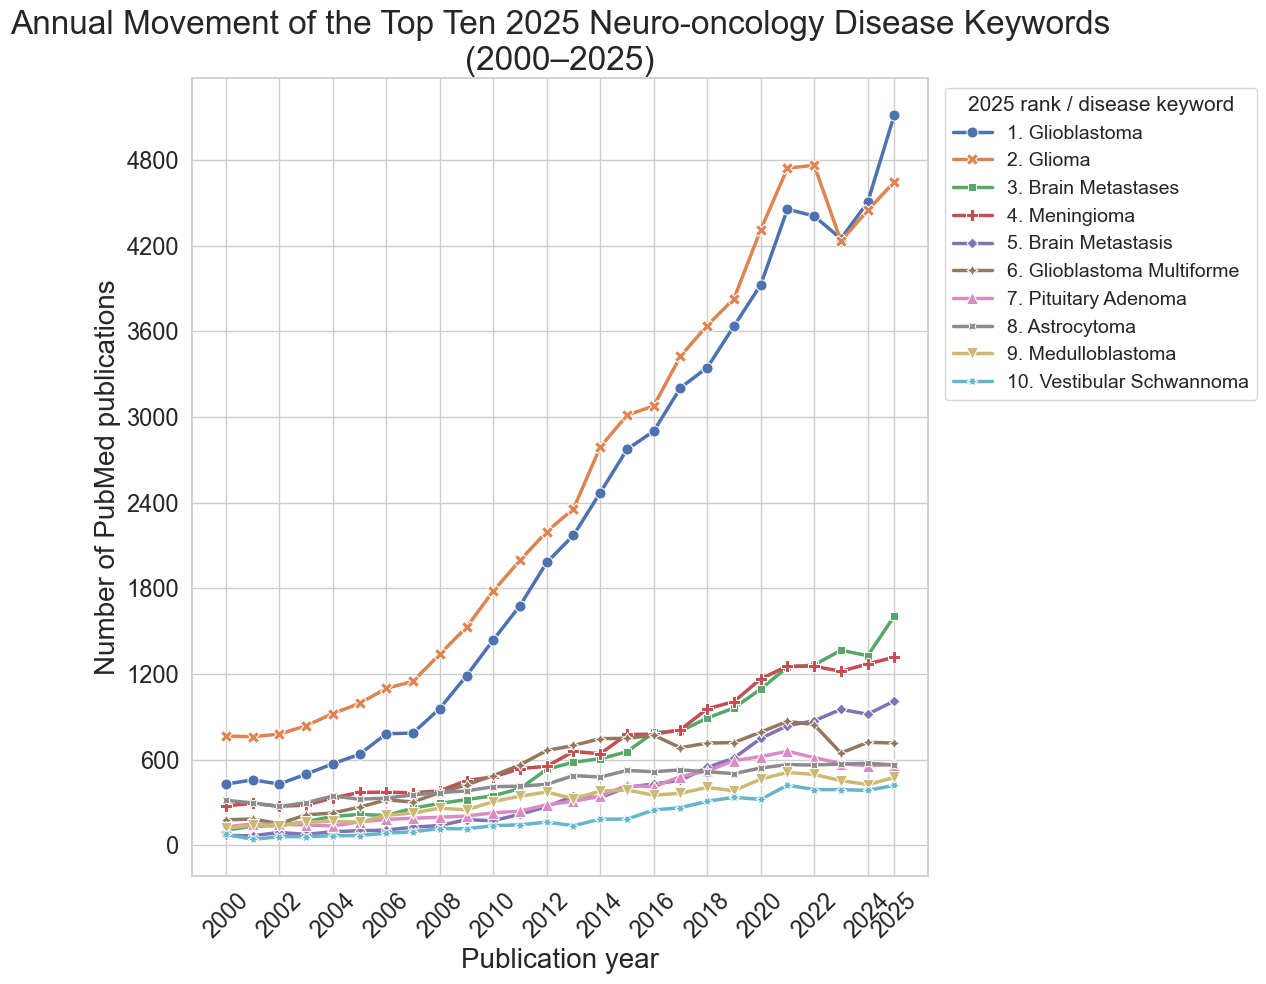

In [7]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.lineplot(
    data=keyword_trends,
    x="Year",
    y="Publications",
    hue="Ranked keyword",
    style="Ranked keyword",
    markers=True,
    dashes=False,
    linewidth=2.5,
    markersize=8,
    ax=ax,
)
ax.set_title(
    "Annual Movement of the Top Ten 2025 Neuro-oncology Disease Keywords\n"
    "(2000–2025)",
    fontsize=24,
)
ax.set_xlabel("Publication year", fontsize=20)
ax.set_ylabel("Number of PubMed publications", fontsize=20)
ax.set_xticks([*range(2000, 2025, 2), 2025])
ax.tick_params(axis="x", rotation=45, labelsize=17)
ax.tick_params(axis="y", labelsize=17)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend(
    title="2025 rank / disease keyword",
    fontsize=14,
    title_fontsize=15,
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
)
fig.tight_layout()
plt.show()


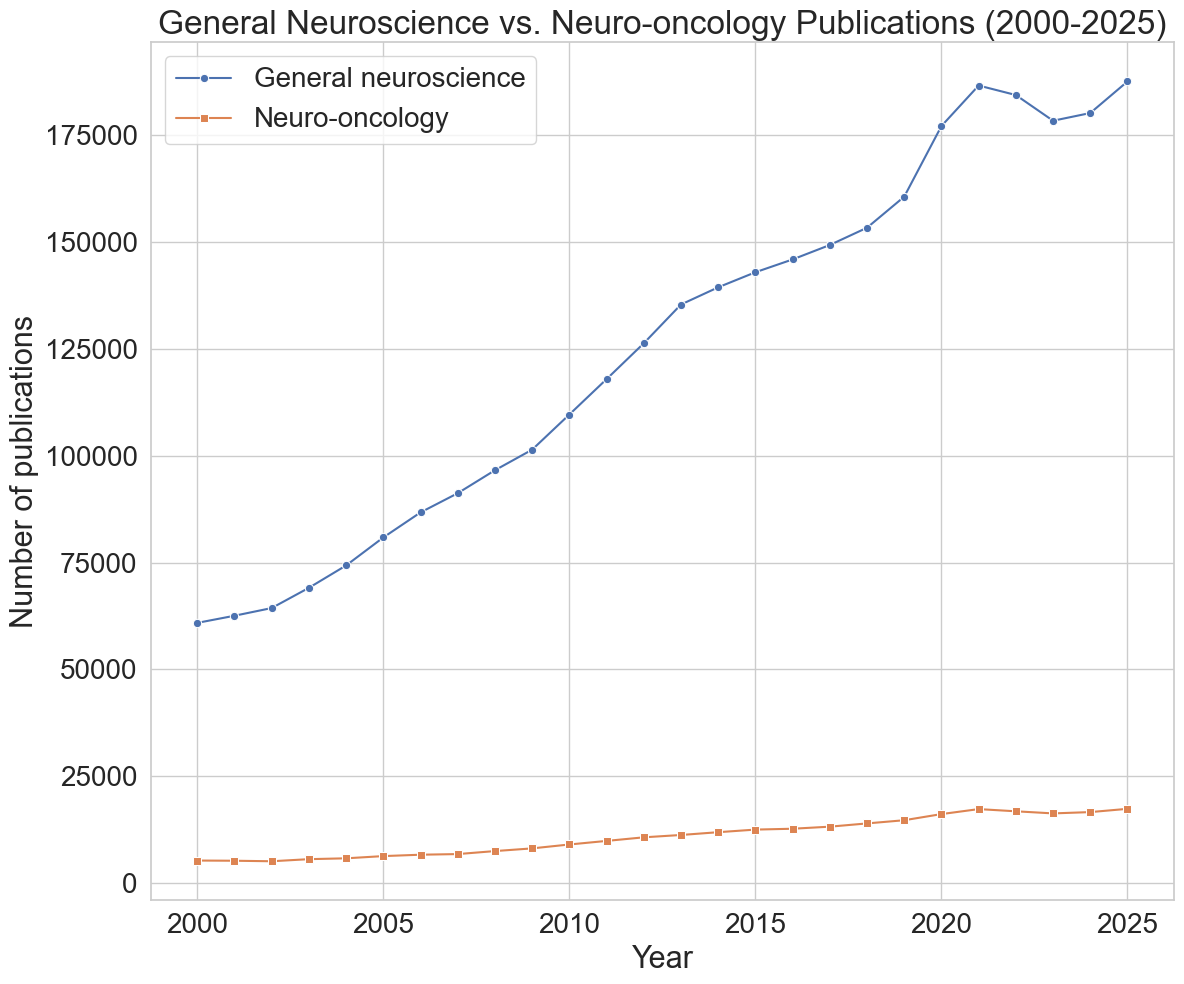

In [8]:
# Plot 2: General neuroscience vs. neuro-oncology
plt.figure(figsize=(12, 10))
sns.lineplot(data=df_pubs, x="Year", y="General neuroscience", label="General neuroscience", marker="o")
sns.lineplot(data=df_pubs, x="Year", y="Neuro-oncology", label="Neuro-oncology", marker="s")
plt.title("General Neuroscience vs. Neuro-oncology Publications (2000-2025)", fontsize=24)
plt.ylabel("Number of publications", fontsize=22)
plt.xlabel("Year", fontsize=22)
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
plt.gca().tick_params(axis="both", labelsize=20)
plt.legend(fontsize=20)
plt.tight_layout()
plt.show()

In [9]:
# Annual literature counts for both publication series
literature_counts_table = (
    df_pubs[["Year", "General neuroscience", "Neuro-oncology"]]
    .rename(columns={"General neuroscience": "Neuroscience literature", "Neuro-oncology": "Neuro-oncology literature"})
)

display(
    literature_counts_table.style
    .hide(axis="index")
    .format({
        "Year": "{:.0f}",
        "Neuroscience literature": "{:,}",
        "Neuro-oncology literature": "{:,}",
    })
    .set_caption("Annual neuroscience and neuro-oncology literature counts (2000-2025)")
)

Year,Neuroscience literature,Neuro-oncology literature
2000,"60,889","5,332"
2001,"62,557","5,286"
2002,"64,356","5,164"
2003,"69,084","5,655"
2004,"74,309","5,853"
2005,"80,853","6,371"
2006,"86,710","6,695"
2007,"91,199","6,843"
2008,"96,572","7,544"
2009,"101,377","8,174"


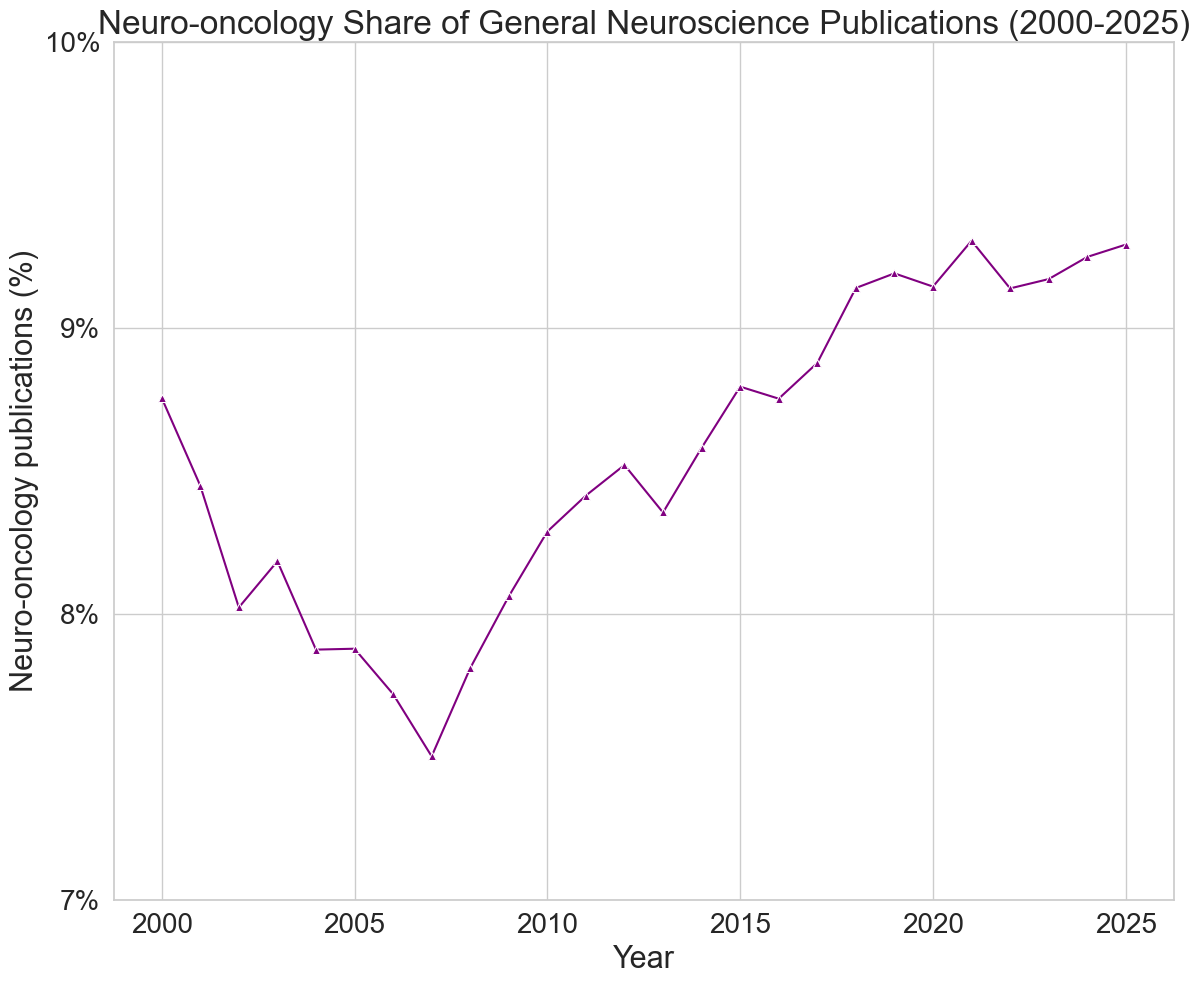

In [10]:
# Plot 3: Neuro-oncology as a proportion of general neuroscience
plt.figure(figsize=(12, 10))
sns.lineplot(data=df_pubs, x="Year", y="Neuro-oncology proportion", color="purple", marker="^")
plt.title("Neuro-oncology Share of General Neuroscience Publications (2000-2025)", fontsize=24)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.01))
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
plt.ylim(0.07, 0.10)
plt.ylabel("Neuro-oncology publications (%)", fontsize=22)
plt.xlabel("Year", fontsize=22)
plt.gca().tick_params(axis="both", labelsize=20)
plt.tight_layout()
plt.show()

In [11]:
# Data points plotted in the neuro-oncology share chart
neuro_oncology_share_table = (
    df_pubs[["Year", "Neuro-oncology proportion"]]
    .assign(**{"Neuro-oncology share (%)": lambda data: data["Neuro-oncology proportion"] * 100})
    .drop(columns="Neuro-oncology proportion")
)

display(
    neuro_oncology_share_table.style
    .hide(axis="index")
    .format({"Year": "{:.0f}", "Neuro-oncology share (%)": "{:.2f}%"})
    .set_caption("Annual neuro-oncology share of general neuroscience publications (2000-2025)")
)

Year,Neuro-oncology share (%)
2000,8.76%
2001,8.45%
2002,8.02%
2003,8.19%
2004,7.88%
2005,7.88%
2006,7.72%
2007,7.50%
2008,7.81%
2009,8.06%


## Chemotherapy-related neuro-oncology literature, 2000–2025

This analysis tracks annual PubMed records matching the specified neuro-oncology disease terms and chemotherapy terms across completed calendar years.

https://pmc.ncbi.nlm.nih.gov/articles/PMC9140894/
https://www.frontiersin.org/journals/neurology/articles/10.3389/fneur.2025.1606149/full
https://pmc.ncbi.nlm.nih.gov/articles/PMC13013171/
https://www.frontiersin.org/journals/oncology/articles/10.3389/fonc.2024.1287725/full

In [12]:
CHEMOTHERAPY_NEURO_ONCOLOGY_QUERY = """
(
    "Glioblastoma" OR "Glioblastoma Multiforme" OR "Astrocytoma" OR "Oligodendroglioma"
    OR "Diffuse Midline Glioma" OR "H3 K27-altered" OR "Pilocytic Astrocytoma"
    OR "Pleomorphic Xanthoastrocytoma" OR "Subependymal Giant Cell Astrocytoma"
    OR "Ependymoma" OR "Myxopapillary ependymoma" OR "Ganglioglioma"
    OR "Dysembryoplastic Neuroepithelial Tumor" OR "DNET" OR "Central Neurocytoma"
    OR "Glioma" OR "DIPG" OR "Diffuse Midline Pontine Glioma" OR "Medulloblastoma"
    OR "Atypical Teratoid Rhabdoid Tumor" OR "Pineoblastoma" OR "Germinoma"
    OR "Meningioma" OR "Pituitary Adenoma" OR "Pituitary Neuroendocrine Tumor"
    OR "PNET" OR "Craniopharyngioma" OR "Vestibular Schwannoma"
    OR "Brain Metastasis" OR "Brain Metastases" OR "Leptomeningeal Disease"
    OR "Leptomeningeal Carcinomatosis" OR "Primary CNS Lymphoma" OR "Hemangioblastoma"
    OR "Choroid Plexus Papilloma"
)
AND
(
    "Chemotherapy" OR "Chemotherapeutic" OR "Chemotherapeutic Agents"
    OR "Cytotoxic Chemotherapy" OR "Antineoplastic Agents"
    OR "Alkylating Agent" OR "Alkylating Agents"
    OR "Nitrosourea" OR "Nitrosoureas" OR "Chloroethyl Nitrosourea"

    OR "Temozolomide" OR "TMZ"

    OR "Lomustine" OR "CCNU" OR "Carmustine" OR "BCNU" OR "Fotemustine"

    OR "Procarbazine" OR "Vincristine" OR "PCV"

    OR "Carboplatin" OR "Vinblastine" OR "Thioguanine" OR "TPCV" OR "Etoposide"

    OR "Cisplatin" OR "Cyclophosphamide"

    OR "Pemetrexed" OR "Capecitabine" OR "Eribulin"
    OR "Anthracycline" OR "Anthracyclines"

    OR "Irinotecan"
)
""".strip()

chemotherapy_start_year = 2000
chemotherapy_end_year = 2025
chemotherapy_years = list(range(chemotherapy_start_year, chemotherapy_end_year + 1))

print("Fetching chemotherapy-related neuro-oncology publications...")
chemotherapy_counts = get_pubmed_counts(
    CHEMOTHERAPY_NEURO_ONCOLOGY_QUERY,
    chemotherapy_start_year,
    chemotherapy_end_year,
)

chemotherapy_trend = pd.DataFrame({
    "Year": chemotherapy_years,
    "Publications": chemotherapy_counts,
})
chemotherapy_trend["Year-over-year change (%)"] = (
    chemotherapy_trend["Publications"].pct_change() * 100
)
chemotherapy_trend["3-year rolling average"] = (
    chemotherapy_trend["Publications"].rolling(window=3, min_periods=3)
    .mean()
)

display(chemotherapy_trend.round({"Year-over-year change (%)": 1, "3-year rolling average": 1}))

Fetching chemotherapy-related neuro-oncology publications...
PubMed cache: 26 hit(s), 0 year(s) to fetch.


,Year,Publications,Year-over-year change (%),3-year rolling average
0,2000,597,NaN,NaN
1,2001,575,-3.7,NaN
2,2002,588,2.3,586.7
3,2003,664,12.9,609.0
4,2004,727,9.5,659.7
5,2005,782,7.6,724.3
6,2006,901,15.2,803.3
7,2007,973,8.0,885.3
8,2008,1146,17.8,1006.7
9,2009,1274,11.2,1131.0


In [13]:
complete_chemotherapy_years = chemotherapy_trend[chemotherapy_trend["Year"] <= 2025]
first_row = complete_chemotherapy_years.iloc[0]
last_row = complete_chemotherapy_years.iloc[-1]
peak_row = complete_chemotherapy_years.loc[complete_chemotherapy_years["Publications"].idxmax()]
year_span = int(last_row["Year"] - first_row["Year"])
overall_change = (last_row["Publications"] / first_row["Publications"] - 1) * 100
cagr = (last_row["Publications"] / first_row["Publications"]) ** (1 / year_span) - 1
chemotherapy_summary = pd.DataFrame({
    "Metric": [
        "Publications in 2000",
        "Publications in 2025 (last complete year)",
        "Absolute increase, 2000–2025",
        "Percentage increase, 2000–2025",
        "Compound annual growth rate, 2000–2025",
        "Peak complete year",
        "Publications in peak complete year",
    ],
    "Value": [
        f"{int(first_row['Publications']):,}",
        f"{int(last_row['Publications']):,}",
        f"{int(last_row['Publications'] - first_row['Publications']):,}",
        f"{overall_change:.1f}%",
        f"{cagr:.1%}",
        f"{int(peak_row['Year'])}",
        f"{int(peak_row['Publications']):,}",
    ],
})
display(chemotherapy_summary)

,Metric,Value
0,Publications in 2000,597
1,Publications in 2025 (last complete year),"2,918"
2,"Absolute increase, 2000–2025","2,321"
3,"Percentage increase, 2000–2025",388.8%
4,"Compound annual growth rate, 2000–2025",6.6%
5,Peak complete year,2025
6,Publications in peak complete year,"2,918"


## Small-molecule and targeted-therapy neuro-oncology literature, 2000–2025

This analysis tracks annual PubMed records that match the same neuro-oncology disease context used above and at least one of the specified targeted-therapy, inhibitor-class, or named small-molecule terms.

In [14]:
SMALL_MOLECULE_TARGETED_THERAPY_QUERY = """
(
    "Targeted Therapy" OR "Targeted Therapies"
    OR "Molecularly Targeted Therapy" OR "Molecular Targeted Therapy"
    OR "Small Molecule Inhibitor" OR "Small Molecule Inhibitors"
    OR "Tyrosine Kinase Inhibitor" OR "Tyrosine Kinase Inhibitors" OR "TKI" OR "TKIs"

    OR "EGFR Inhibitor" OR "EGFR Inhibitors"
    OR "Erlotinib" OR "Gefitinib" OR "Afatinib" OR "Dacomitinib"
    OR "Osimertinib" OR "BDTX-1535" OR "WSD0922"

    OR "VEGFR Inhibitor" OR "VEGFR Inhibitors"
    OR "Axitinib" OR "Cediranib" OR "Vatalanib" OR "PTK787" OR "Apatinib"

    OR "PDGFR Inhibitor" OR "PDGFR Inhibitors" OR "Imatinib"

    OR "BRAF Inhibitor" OR "BRAF Inhibitors" OR "RAF Inhibitor" OR "RAF Inhibitors"
    OR "Vemurafenib" OR "Dabrafenib" OR "Encorafenib" OR "Tovorafenib"
    OR "Plixorafenib" OR "PLX8394"

    OR "MEK Inhibitor" OR "MEK Inhibitors"
    OR "Trametinib" OR "Selumetinib" OR "Binimetinib" OR "Cobimetinib"

    OR "IDH Inhibitor" OR "IDH Inhibitors" OR "IDH1 Inhibitor" OR "IDH2 Inhibitor"
    OR "Mutant IDH Inhibitor" OR "Vorasidenib" OR "AG-881" OR "Ivosidenib"
    OR "Safusidenib" OR "Olutasidenib" OR "FT-2102" OR "DS-1001"
    OR "BAY 1436032" OR "MRK-A"

    OR "NTRK Inhibitor" OR "NTRK Inhibitors" OR "TRK Inhibitor" OR "TRK Inhibitors"
    OR "Larotrectinib" OR "Entrectinib"

    OR "ALK Inhibitor" OR "ALK Inhibitors"
    OR "Alectinib" OR "Ceritinib" OR "Brigatinib" OR "Lorlatinib" OR "Crizotinib"

    OR "ROS1 Inhibitor" OR "ROS1 Inhibitors"

    OR "MET Inhibitor" OR "MET Inhibitors" OR "Capmatinib" OR "Tepotinib"

    OR "RET Inhibitor" OR "RET Inhibitors" OR "Selpercatinib" OR "Pralsetinib"

    OR "KRAS Inhibitor" OR "KRAS G12C Inhibitor" OR "Sotorasib"

    OR "HER2 Inhibitor" OR "HER2 Inhibitors"
    OR "Lapatinib" OR "Neratinib" OR "Tucatinib"

    OR "CDK4/6 Inhibitor" OR "CDK4/6 Inhibitors" OR "Abemaciclib"

    OR "PI3K Inhibitor" OR "PI3K Inhibitors" OR "Alpelisib"

    OR "mTOR Inhibitor" OR "mTOR Inhibitors" OR "Everolimus" OR "Temsirolimus"

    OR "PARP Inhibitor" OR "PARP Inhibitors" OR "Olaparib"

    OR "Farnesyl Transferase Inhibitor" OR "Farnesyl Transferase Inhibitors"
    OR "Tipifarnib" OR "Lonafarnib"

    OR "HDAC Inhibitor" OR "HDAC Inhibitors" OR "Vorinostat" OR "Romidepsin"

    OR "Integrin Inhibitor" OR "Integrin Inhibitors" OR "Cilengitide"

    OR "Dordaviprone" OR "ONC201"

    OR "MCT Inhibitor" OR "MCT Inhibitors"
)
""".strip()

NEURO_ONCOLOGY_DISEASE_CONTEXT = CHEMOTHERAPY_NEURO_ONCOLOGY_QUERY.split("\nAND\n", 1)[0]
SMALL_MOLECULE_NEURO_ONCOLOGY_QUERY = (
    f"{NEURO_ONCOLOGY_DISEASE_CONTEXT}\nAND\n{SMALL_MOLECULE_TARGETED_THERAPY_QUERY}"
)

small_molecule_start_year = 2000
small_molecule_end_year = 2025
small_molecule_years = list(range(small_molecule_start_year, small_molecule_end_year + 1))

print("Fetching small-molecule and targeted-therapy neuro-oncology publications...")
small_molecule_counts = get_pubmed_counts(
    SMALL_MOLECULE_NEURO_ONCOLOGY_QUERY,
    small_molecule_start_year,
    small_molecule_end_year,
)

small_molecule_trend = pd.DataFrame({
    "Year": small_molecule_years,
    "Publications": small_molecule_counts,
})
small_molecule_trend["Year-over-year change (%)"] = (
    small_molecule_trend["Publications"].pct_change() * 100
)
small_molecule_trend["3-year rolling average"] = (
    small_molecule_trend["Publications"].rolling(window=3, min_periods=3).mean()
)

display(small_molecule_trend.round({"Year-over-year change (%)": 1, "3-year rolling average": 1}))

Fetching small-molecule and targeted-therapy neuro-oncology publications...
PubMed cache: 26 hit(s), 0 year(s) to fetch.


,Year,Publications,Year-over-year change (%),3-year rolling average
0,2000,15,NaN,NaN
1,2001,24,60.0,NaN
2,2002,31,29.2,23.3
3,2003,45,45.2,33.3
4,2004,71,57.8,49.0
5,2005,90,26.8,68.7
6,2006,135,50.0,98.7
7,2007,139,3.0,121.3
8,2008,169,21.6,147.7
9,2009,226,33.7,178.0


In [15]:
complete_small_molecule_years = small_molecule_trend[small_molecule_trend["Year"] <= 2025]
small_molecule_first_row = complete_small_molecule_years.iloc[0]
small_molecule_last_row = complete_small_molecule_years.iloc[-1]
small_molecule_peak_row = complete_small_molecule_years.loc[
    complete_small_molecule_years["Publications"].idxmax()
]
small_molecule_year_span = int(
    small_molecule_last_row["Year"] - small_molecule_first_row["Year"]
)
small_molecule_overall_change = (
    small_molecule_last_row["Publications"] / small_molecule_first_row["Publications"] - 1
) * 100
small_molecule_cagr = (
    small_molecule_last_row["Publications"] / small_molecule_first_row["Publications"]
) ** (1 / small_molecule_year_span) - 1

small_molecule_summary = pd.DataFrame({
    "Metric": [
        "Publications in 2000",
        "Publications in 2025 (last complete year)",
        "Absolute increase, 2000–2025",
        "Percentage increase, 2000–2025",
        "Compound annual growth rate, 2000–2025",
        "Peak complete year",
        "Publications in peak complete year",
    ],
    "Value": [
        f"{int(small_molecule_first_row['Publications']):,}",
        f"{int(small_molecule_last_row['Publications']):,}",
        f"{int(small_molecule_last_row['Publications'] - small_molecule_first_row['Publications']):,}",
        f"{small_molecule_overall_change:.1f}%",
        f"{small_molecule_cagr:.1%}",
        f"{int(small_molecule_peak_row['Year'])}",
        f"{int(small_molecule_peak_row['Publications']):,}",
    ],
})
display(small_molecule_summary)

,Metric,Value
0,Publications in 2000,15
1,Publications in 2025 (last complete year),"1,409"
2,"Absolute increase, 2000–2025","1,394"
3,"Percentage increase, 2000–2025",9293.3%
4,"Compound annual growth rate, 2000–2025",19.9%
5,Peak complete year,2025
6,Publications in peak complete year,"1,409"


## Antibody and antibody-drug conjugate neuro-oncology literature, 2000–2025

This analysis tracks annual PubMed records that match the same neuro-oncology disease context and at least one of the specified antibody or antibody-drug conjugate terms.

https://pmc.ncbi.nlm.nih.gov/articles/PMC12263320/
https://pmc.ncbi.nlm.nih.gov/articles/PMC10912007/
https://www.frontiersin.org/journals/oncology/articles/10.3389/fonc.2026.1811494/full
https://www.nature.com/articles/s41571-023-00756-z

In [16]:
BIOLOGIC_ANTIBODY_THERAPY_QUERY = """
(
    "Bevacizumab"

    OR "Cetuximab" OR "Panitumumab" OR "Nimotuzumab"

    OR "Depatuxizumab Mafodotin" OR "Depatuximab Mafodotin"
    OR "ABT-414" OR "AMG595"

    OR "Trastuzumab" OR "Pertuzumab"

    OR "Ado-Trastuzumab Emtansine" OR "Trastuzumab Emtansine" OR "T-DM1"

    OR "Trastuzumab Deruxtecan" OR "T-DXd"

    OR "Sacituzumab Govitecan"

    OR "Amivantamab"

    OR "EGFR Antibody" OR "EGFR Antibodies"
    OR "EGFRvIII Antibody" OR "EGFRvIII Antibodies"

    OR "HER2 Antibody" OR "HER2 Antibodies"
    OR "ERBB2 Antibody" OR "ERBB2 Antibodies"

    OR "HER3 Antibody" OR "HER3 Antibodies"
    OR "ERBB3 Antibody" OR "ERBB3 Antibodies"

    OR "TROP2 Antibody" OR "TROP2 Antibodies"
    OR "TACSTD2 Antibody" OR "TACSTD2 Antibodies"

    OR "B7-H3 Antibody" OR "B7-H3 Antibodies"
    OR "CD276 Antibody" OR "CD276 Antibodies"

    OR "GD2 Antibody" OR "GD2 Antibodies"

    OR "FOLR1 Antibody" OR "FOLR1 Antibodies"
    OR "Folate Receptor Alpha Antibody" OR "Folate Receptor Alpha Antibodies"

    OR "NECTIN4 Antibody" OR "NECTIN4 Antibodies"
    OR "Nectin-4 Antibody" OR "Nectin-4 Antibodies"

    OR "CLDN6 Antibody" OR "CLDN6 Antibodies"
    OR "Claudin 6 Antibody" OR "Claudin 6 Antibodies"

    OR "CLDN18 Antibody" OR "CLDN18 Antibodies"
    OR "CLDN18.2 Antibody" OR "CLDN18.2 Antibodies"
    OR "Claudin 18.2 Antibody" OR "Claudin 18.2 Antibodies"

    OR "Tissue Factor Antibody" OR "Tissue Factor Antibodies"
    OR "CD142 Antibody" OR "CD142 Antibodies"

    OR "ALCAM Antibody" OR "ALCAM Antibodies"
    OR "CD166 Antibody" OR "CD166 Antibodies"

    OR "ROR1 Antibody" OR "ROR1 Antibodies"
    OR "ROR2 Antibody" OR "ROR2 Antibodies"

    OR "ZIP6 Antibody" OR "ZIP6 Antibodies"
    OR "SLC39A6 Antibody" OR "SLC39A6 Antibodies"

    OR "B7-H4 Antibody" OR "B7-H4 Antibodies"
    OR "VTCN1 Antibody" OR "VTCN1 Antibodies"

    OR "Antibody-Drug Conjugate" OR "Antibody Drug Conjugate"
    OR "Antibody-Drug Conjugates" OR "Antibody Drug Conjugates"
    OR "ADC" OR "ADCs"
)
""".strip()

BIOLOGIC_NEURO_ONCOLOGY_QUERY = (
    f"{NEURO_ONCOLOGY_DISEASE_CONTEXT}\nAND\n{BIOLOGIC_ANTIBODY_THERAPY_QUERY}"
)

biologic_start_year = 2000
biologic_end_year = 2025
biologic_years = list(range(biologic_start_year, biologic_end_year + 1))

print("Fetching antibody and antibody-drug conjugate neuro-oncology publications...")
biologic_counts = get_pubmed_counts(
    BIOLOGIC_NEURO_ONCOLOGY_QUERY,
    biologic_start_year,
    biologic_end_year,
)

biologic_trend = pd.DataFrame({
    "Year": biologic_years,
    "Publications": biologic_counts,
})
biologic_trend["Year-over-year change (%)"] = (
    biologic_trend["Publications"].pct_change() * 100
)
biologic_trend["3-year rolling average"] = (
    biologic_trend["Publications"].rolling(window=3, min_periods=3).mean()
)

display(biologic_trend.round({"Year-over-year change (%)": 1, "3-year rolling average": 1}))

Fetching antibody and antibody-drug conjugate neuro-oncology publications...
PubMed cache: 26 hit(s), 0 year(s) to fetch.


,Year,Publications,Year-over-year change (%),3-year rolling average
0,2000,11,NaN,NaN
1,2001,17,54.5,NaN
2,2002,25,47.1,17.7
3,2003,21,-16.0,21.0
4,2004,44,109.5,30.0
5,2005,28,-36.4,31.0
6,2006,57,103.6,43.0
7,2007,72,26.3,52.3
8,2008,129,79.2,86.0
9,2009,150,16.3,117.0


In [17]:
complete_biologic_years = biologic_trend[biologic_trend["Year"] <= 2025]
biologic_first_row = complete_biologic_years.iloc[0]
biologic_last_row = complete_biologic_years.iloc[-1]
biologic_peak_row = complete_biologic_years.loc[
    complete_biologic_years["Publications"].idxmax()
]
biologic_year_span = int(biologic_last_row["Year"] - biologic_first_row["Year"])
biologic_overall_change = (
    biologic_last_row["Publications"] / biologic_first_row["Publications"] - 1
) * 100
biologic_cagr = (
    biologic_last_row["Publications"] / biologic_first_row["Publications"]
) ** (1 / biologic_year_span) - 1

biologic_summary = pd.DataFrame({
    "Metric": [
        "Publications in 2000",
        "Publications in 2025 (last complete year)",
        "Absolute increase, 2000–2025",
        "Percentage increase, 2000–2025",
        "Compound annual growth rate, 2000–2025",
        "Peak complete year",
        "Publications in peak complete year",
    ],
    "Value": [
        f"{int(biologic_first_row['Publications']):,}",
        f"{int(biologic_last_row['Publications']):,}",
        f"{int(biologic_last_row['Publications'] - biologic_first_row['Publications']):,}",
        f"{biologic_overall_change:.1f}%",
        f"{biologic_cagr:.1%}",
        f"{int(biologic_peak_row['Year'])}",
        f"{int(biologic_peak_row['Publications']):,}",
    ],
})
display(biologic_summary)

,Metric,Value
0,Publications in 2000,11
1,Publications in 2025 (last complete year),504
2,"Absolute increase, 2000–2025",493
3,"Percentage increase, 2000–2025",4481.8%
4,"Compound annual growth rate, 2000–2025",16.5%
5,Peak complete year,2025
6,Publications in peak complete year,504


## Immunotherapy-related neuro-oncology literature, 2000–2025

This analysis tracks annual PubMed records that match the same neuro-oncology disease context and at least one of the specified checkpoint-inhibitor, vaccine, cellular-therapy, or oncolytic-virus terms.

In [18]:
IMMUNOTHERAPY_QUERY = """
(
    "Immunotherapy" OR "Cancer Immunotherapy" OR "Tumor Immunotherapy" OR "Immunotherapeutic"

    OR "Immune Checkpoint Inhibitor" OR "Immune Checkpoint Inhibitors"
    OR "Checkpoint Inhibitor" OR "Checkpoint Inhibitors"
    OR "Immune Checkpoint Blockade" OR "Checkpoint Blockade"

    OR "PD-1 Inhibitor" OR "PD-1 Inhibitors"
    OR "PD-L1 Inhibitor" OR "PD-L1 Inhibitors"
    OR "Anti-PD-1" OR "Anti-PD-L1"

    OR "CTLA-4 Inhibitor" OR "CTLA-4 Inhibitors" OR "Anti-CTLA-4"

    OR "Pembrolizumab" OR "Nivolumab" OR "Ipilimumab"

    OR "TIM-3" OR "TIM-3 Inhibitor" OR "Anti-TIM-3" OR "BGB-A425" OR "Tislelizumab"

    OR "LAG-3" OR "LAG-3 Inhibitor"

    OR "Cancer Vaccine" OR "Cancer Vaccines" OR "Tumor Vaccine" OR "Tumor Vaccines"
    OR "Peptide Vaccine" OR "Peptide Vaccines"
    OR "Dendritic Cell Vaccine" OR "Dendritic Cell Vaccines"
    OR "Cell Vaccine" OR "Vaccine Therapy"

    OR "Rindopepimut" OR "CDX-110" OR "IMA950" OR "HSPPC-96" OR "DCVax-L"
    OR "IDH1 Peptide Vaccine" OR "WT1 Vaccine" OR "CMV pp65"

    OR "CAR-T" OR "CAR T" OR "CAR T-cell" OR "CAR T Cell" OR "CAR T-cell Therapy"
    OR "Chimeric Antigen Receptor T Cell" OR "Chimeric Antigen Receptor T Cells"
    OR "Adoptive Immunotherapy" OR "Adoptive Cell Therapy" OR "Adoptive T Cell Therapy"

    OR "IL13Rα2 CAR-T" OR "IL13Ralpha2 CAR-T" OR "EGFRvIII CAR-T" OR "HER2 CAR-T"
    OR "EphA2 CAR-T" OR "GD2 CAR-T" OR "B7-H3 CAR-T" OR "Chlorotoxin CAR-T"
    OR "CD317 CAR-T" OR "TanCAR" OR "TanCART"

    OR "Oncolytic Virus" OR "Oncolytic Viruses"
    OR "Oncolytic Viral Therapy" OR "Oncolytic Virotherapy" OR "Viral Therapy"

    OR "Parvovirus" OR "Newcastle Disease Virus" OR "Reovirus" OR "Delta-24-RGD"
    OR "DNX-2401" OR "Toca 511" OR "ONYX-015" OR "PVSRIPO"
    OR "G47-delta" OR "G47Δ"
)
""".strip()

IMMUNOTHERAPY_NEURO_ONCOLOGY_QUERY = (
    f"{NEURO_ONCOLOGY_DISEASE_CONTEXT}\nAND\n{IMMUNOTHERAPY_QUERY}"
)

immunotherapy_start_year = 2000
immunotherapy_end_year = 2025
immunotherapy_years = list(range(immunotherapy_start_year, immunotherapy_end_year + 1))

print("Fetching immunotherapy-related neuro-oncology publications...")
immunotherapy_counts = get_pubmed_counts(
    IMMUNOTHERAPY_NEURO_ONCOLOGY_QUERY,
    immunotherapy_start_year,
    immunotherapy_end_year,
)

immunotherapy_trend = pd.DataFrame({
    "Year": immunotherapy_years,
    "Publications": immunotherapy_counts,
})
immunotherapy_trend["Year-over-year change (%)"] = (
    immunotherapy_trend["Publications"].pct_change() * 100
)
immunotherapy_trend["3-year rolling average"] = (
    immunotherapy_trend["Publications"].rolling(window=3, min_periods=3).mean()
)

display(immunotherapy_trend.round({"Year-over-year change (%)": 1, "3-year rolling average": 1}))

Fetching immunotherapy-related neuro-oncology publications...
PubMed cache: 26 hit(s), 0 year(s) to fetch.


,Year,Publications,Year-over-year change (%),3-year rolling average
0,2000,60,NaN,NaN
1,2001,59,-1.7,NaN
2,2002,49,-16.9,56.0
3,2003,73,49.0,60.3
4,2004,71,-2.7,64.3
5,2005,86,21.1,76.7
6,2006,107,24.4,88.0
7,2007,119,11.2,104.0
8,2008,120,0.8,115.3
9,2009,132,10.0,123.7


In [19]:
complete_immunotherapy_years = immunotherapy_trend[immunotherapy_trend["Year"] <= 2025]
immunotherapy_first_row = complete_immunotherapy_years.iloc[0]
immunotherapy_last_row = complete_immunotherapy_years.iloc[-1]
immunotherapy_peak_row = complete_immunotherapy_years.loc[
    complete_immunotherapy_years["Publications"].idxmax()
]
immunotherapy_year_span = int(
    immunotherapy_last_row["Year"] - immunotherapy_first_row["Year"]
)
immunotherapy_overall_change = (
    immunotherapy_last_row["Publications"] / immunotherapy_first_row["Publications"] - 1
) * 100
immunotherapy_cagr = (
    immunotherapy_last_row["Publications"] / immunotherapy_first_row["Publications"]
) ** (1 / immunotherapy_year_span) - 1

immunotherapy_summary = pd.DataFrame({
    "Metric": [
        "Publications in 2000",
        "Publications in 2025 (last complete year)",
        "Absolute increase, 2000–2025",
        "Percentage increase, 2000–2025",
        "Compound annual growth rate, 2000–2025",
        "Peak complete year",
        "Publications in peak complete year",
    ],
    "Value": [
        f"{int(immunotherapy_first_row['Publications']):,}",
        f"{int(immunotherapy_last_row['Publications']):,}",
        f"{int(immunotherapy_last_row['Publications'] - immunotherapy_first_row['Publications']):,}",
        f"{immunotherapy_overall_change:.1f}%",
        f"{immunotherapy_cagr:.1%}",
        f"{int(immunotherapy_peak_row['Year'])}",
        f"{int(immunotherapy_peak_row['Publications']):,}",
    ],
})
display(immunotherapy_summary)

,Metric,Value
0,Publications in 2000,60
1,Publications in 2025 (last complete year),"1,602"
2,"Absolute increase, 2000–2025","1,542"
3,"Percentage increase, 2000–2025",2570.0%
4,"Compound annual growth rate, 2000–2025",14.0%
5,Peak complete year,2025
6,Publications in peak complete year,"1,602"


## Comparison of four neuro-oncology treatment modalities, 2000–2025

This figure compares cumulative PubMed publication counts through each year for all four treatment categories.

PubMed cache: 26 hit(s), 0 year(s) to fetch.
PubMed cache: 26 hit(s), 0 year(s) to fetch.
PubMed cache: 26 hit(s), 0 year(s) to fetch.
PubMed cache: 26 hit(s), 0 year(s) to fetch.


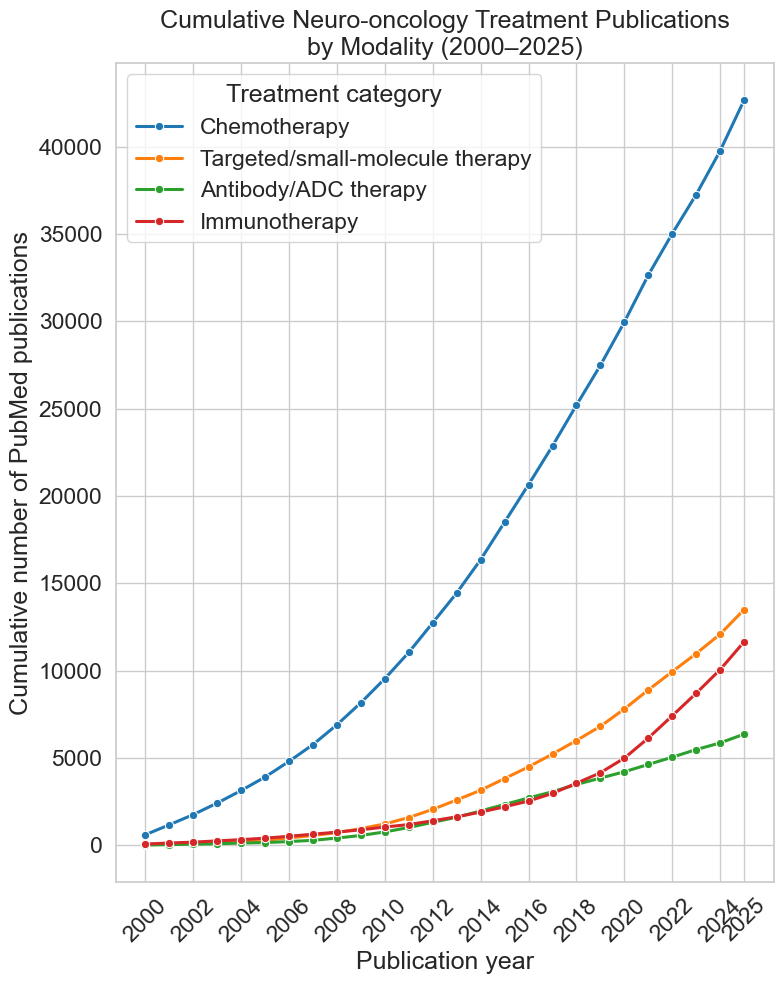

In [20]:
TREATMENT_PUBLICATION_EXCLUSION = """
(
    "Prophylactic Cranial Irradiation"[Title/Abstract]
)
""".strip()

overall_treatment_queries = {
    "Chemotherapy": CHEMOTHERAPY_NEURO_ONCOLOGY_QUERY,
    "Targeted/small-molecule therapy": SMALL_MOLECULE_NEURO_ONCOLOGY_QUERY,
    "Antibody/ADC therapy": BIOLOGIC_NEURO_ONCOLOGY_QUERY,
    "Immunotherapy": IMMUNOTHERAPY_NEURO_ONCOLOGY_QUERY,
}

combined_treatment_frames = []
for category, treatment_query in overall_treatment_queries.items():
    filtered_query = f"{treatment_query}\nNOT\n{TREATMENT_PUBLICATION_EXCLUSION}"
    counts = get_pubmed_counts(filtered_query, 2000, 2025)
    combined_treatment_frames.append(pd.DataFrame({
        "Year": range(2000, 2026),
        "Publications": counts,
        "Category": category,
    }))
combined_treatment_trends = pd.concat(combined_treatment_frames, ignore_index=True)
combined_treatment_cumulative = combined_treatment_trends.copy()
combined_treatment_cumulative["Cumulative publications"] = (
    combined_treatment_cumulative.groupby("Category", sort=False)["Publications"].cumsum()
)

treatment_colors = {
    "Chemotherapy": "#1f77b4",
    "Targeted/small-molecule therapy": "#ff7f0e",
    "Antibody/ADC therapy": "#2ca02c",
    "Immunotherapy": "#d62728",
}

fig, ax = plt.subplots(figsize=(8, 10))
sns.lineplot(
    data=combined_treatment_cumulative,
    x="Year",
    y="Cumulative publications",
    hue="Category",
    palette=treatment_colors,
    marker="o",
    linewidth=2.2,
    ax=ax,
)
ax.set_title("Cumulative Neuro-oncology Treatment Publications\nby Modality (2000–2025)", fontsize=18)
ax.set_xlabel("Publication year", fontsize=18)
ax.set_ylabel("Cumulative number of PubMed publications", fontsize=18)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xticks([*range(2000, 2025, 2), 2025])
ax.tick_params(axis="x", rotation=45, labelsize=16.5)
ax.tick_params(axis="y", labelsize=16.5)
ax.legend(
    title="Treatment category",
    fontsize=16.5,
    title_fontsize=18,
)
plt.tight_layout()
plt.show()

## Four treatment modalities in primary CNS tumors and CNS metastasis

The primary-CNS analysis uses the non-metastatic primary intracranial and CNS tumor terms from the neuro-oncology disease list. The CNS-metastasis analysis uses brain metastasis, brain metastases, leptomeningeal disease, and leptomeningeal carcinomatosis. Both figures show cumulative publication counts through each year.

In [21]:
PRIMARY_CNS_DISEASE_CONTEXT = """
(
    "Glioblastoma" OR "Glioblastoma Multiforme" OR "Astrocytoma" OR "Oligodendroglioma"
    OR "Diffuse Midline Glioma" OR "H3 K27-altered" OR "Pilocytic Astrocytoma"
    OR "Pleomorphic Xanthoastrocytoma" OR "Subependymal Giant Cell Astrocytoma"
    OR "Ependymoma" OR "Myxopapillary ependymoma" OR "Ganglioglioma"
    OR "Dysembryoplastic Neuroepithelial Tumor" OR "DNET" OR "Central Neurocytoma"
    OR "Glioma" OR "DIPG" OR "Diffuse Midline Pontine Glioma" OR "Medulloblastoma"
    OR "Atypical Teratoid Rhabdoid Tumor" OR "Pineoblastoma" OR "Germinoma"
    OR "Meningioma" OR "Pituitary Adenoma" OR "Pituitary Neuroendocrine Tumor"
    OR "PNET" OR "Craniopharyngioma" OR "Vestibular Schwannoma"
    OR "Primary CNS Lymphoma" OR "Hemangioblastoma" OR "Choroid Plexus Papilloma"
)
""".strip()

CNS_METASTASIS_DISEASE_CONTEXT = """
(
    "Brain Metastasis" OR "Brain Metastases"
    OR "Leptomeningeal Disease" OR "Leptomeningeal Carcinomatosis"
)
""".strip()

CHEMOTHERAPY_THERAPY_QUERY = CHEMOTHERAPY_NEURO_ONCOLOGY_QUERY.split("\nAND\n", 1)[1]
TREATMENT_MODALITY_QUERIES = {
    "Chemotherapy": CHEMOTHERAPY_THERAPY_QUERY,
    "Targeted/small-molecule therapy": SMALL_MOLECULE_TARGETED_THERAPY_QUERY,
    "Antibody/ADC therapy": BIOLOGIC_ANTIBODY_THERAPY_QUERY,
    "Immunotherapy": IMMUNOTHERAPY_QUERY,
}

TREATMENT_PUBLICATION_EXCLUSION = """
(
    "Prophylactic Cranial Irradiation"[Title/Abstract]
)
""".strip()

def get_context_modality_trends(context_query, start_year=2000, end_year=2025):
    frames = []
    for category, therapy_query in TREATMENT_MODALITY_QUERIES.items():
        print(f"Fetching {category} publications...")
        combined_query = (
            f"{context_query}\nAND\n{therapy_query}"
            f"\nNOT\n{TREATMENT_PUBLICATION_EXCLUSION}"
        )
        counts = get_pubmed_counts(combined_query, start_year, end_year)
        frames.append(pd.DataFrame({
            "Year": range(start_year, end_year + 1),
            "Publications": counts,
            "Category": category,
        }))
    return pd.concat(frames, ignore_index=True)

print("Fetching primary CNS tumor trends by treatment modality...")
primary_cns_treatment_trends = get_context_modality_trends(PRIMARY_CNS_DISEASE_CONTEXT)

Fetching primary CNS tumor trends by treatment modality...
Fetching Chemotherapy publications...
PubMed cache: 26 hit(s), 0 year(s) to fetch.
Fetching Targeted/small-molecule therapy publications...
PubMed cache: 26 hit(s), 0 year(s) to fetch.
Fetching Antibody/ADC therapy publications...
PubMed cache: 26 hit(s), 0 year(s) to fetch.
Fetching Immunotherapy publications...
PubMed cache: 26 hit(s), 0 year(s) to fetch.


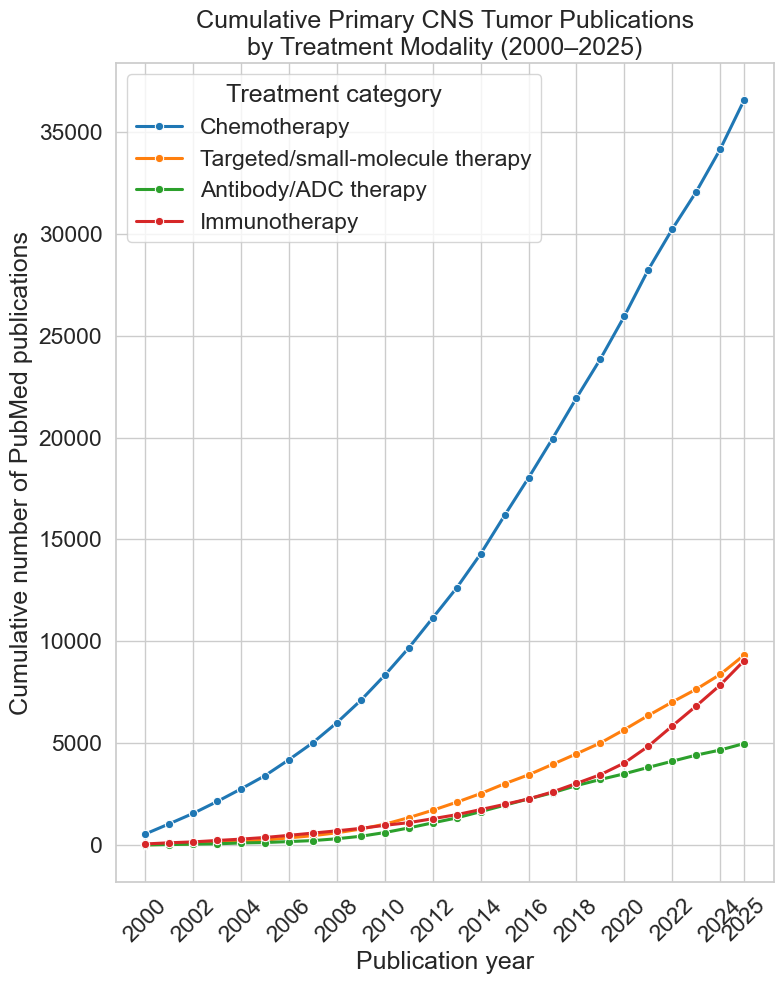

In [22]:
primary_cns_treatment_cumulative = primary_cns_treatment_trends.copy()
primary_cns_treatment_cumulative["Cumulative publications"] = (
    primary_cns_treatment_cumulative.groupby("Category", sort=False)["Publications"].cumsum()
)

fig, ax = plt.subplots(figsize=(8, 10))
sns.lineplot(
    data=primary_cns_treatment_cumulative,
    x="Year",
    y="Cumulative publications",
    hue="Category",
    palette=treatment_colors,
    marker="o",
    linewidth=2.2,
    ax=ax,
)
ax.set_title("Cumulative Primary CNS Tumor Publications\nby Treatment Modality (2000–2025)", fontsize=18)
ax.set_xlabel("Publication year", fontsize=18)
ax.set_ylabel("Cumulative number of PubMed publications", fontsize=18)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xticks([*range(2000, 2025, 2), 2025])
ax.tick_params(axis="x", rotation=45, labelsize=16.5)
ax.tick_params(axis="y", labelsize=16.5)
ax.legend(
    title="Treatment category",
    fontsize=16.5,
    title_fontsize=18,
)
plt.tight_layout()
plt.show()

In [23]:
print("Fetching CNS metastasis trends by treatment modality...")
cns_metastasis_treatment_trends = get_context_modality_trends(CNS_METASTASIS_DISEASE_CONTEXT)

Fetching CNS metastasis trends by treatment modality...
Fetching Chemotherapy publications...
PubMed cache: 26 hit(s), 0 year(s) to fetch.
Fetching Targeted/small-molecule therapy publications...
PubMed cache: 26 hit(s), 0 year(s) to fetch.
Fetching Antibody/ADC therapy publications...
PubMed cache: 26 hit(s), 0 year(s) to fetch.
Fetching Immunotherapy publications...
PubMed cache: 26 hit(s), 0 year(s) to fetch.


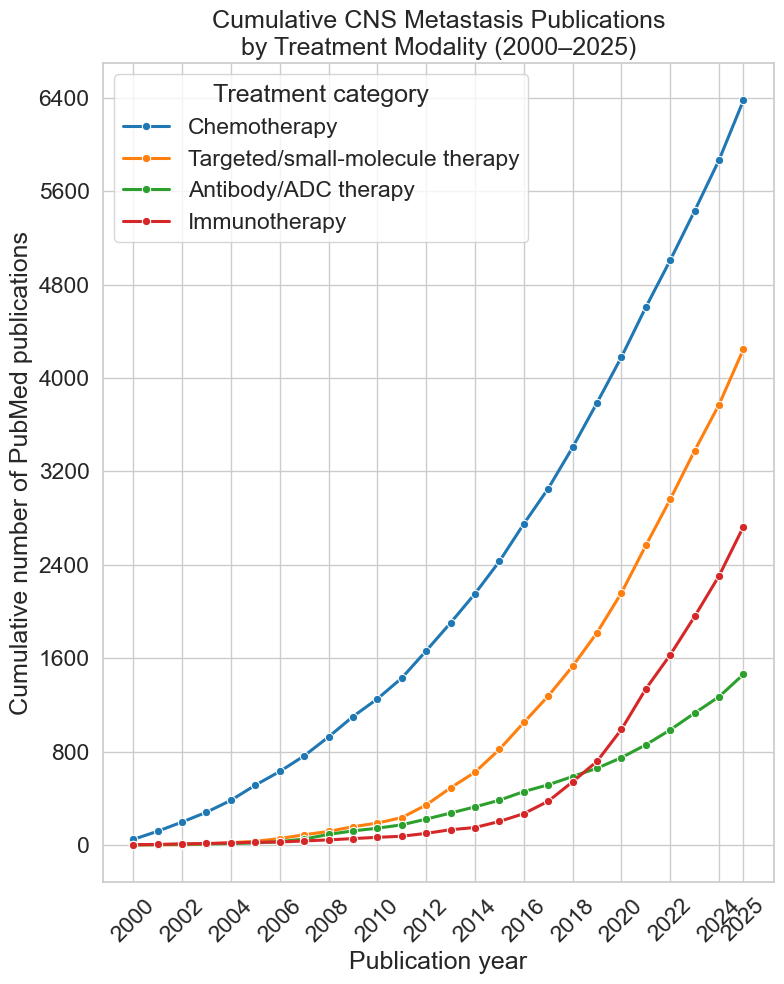

In [24]:
cns_metastasis_treatment_cumulative = cns_metastasis_treatment_trends.copy()
cns_metastasis_treatment_cumulative["Cumulative publications"] = (
    cns_metastasis_treatment_cumulative.groupby("Category", sort=False)["Publications"].cumsum()
)

fig, ax = plt.subplots(figsize=(8, 10))
sns.lineplot(
    data=cns_metastasis_treatment_cumulative,
    x="Year",
    y="Cumulative publications",
    hue="Category",
    palette=treatment_colors,
    marker="o",
    linewidth=2.2,
    ax=ax,
)
ax.set_title("Cumulative CNS Metastasis Publications\nby Treatment Modality (2000–2025)", fontsize=18)
ax.set_xlabel("Publication year", fontsize=18)
ax.set_ylabel("Cumulative number of PubMed publications", fontsize=18)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xticks([*range(2000, 2025, 2), 2025])
ax.tick_params(axis="x", rotation=45, labelsize=16.5)
ax.tick_params(axis="y", labelsize=16.5)
ax.legend(
    title="Treatment category",
    fontsize=16.5,
    title_fontsize=18,
)
plt.tight_layout()
plt.show()

## Phase III trial publications by treatment modality, 2000–2025

These three integrated figures apply the phase III publication-type/title-abstract criterion to the overall neuro-oncology, primary-CNS, and CNS-metastasis contexts. They show cumulative publication counts through each year.

In [25]:
PHASE_III_CRITERIA = """
(
    "Clinical Trial, Phase III"[Publication Type]
    OR "phase III"[Title/Abstract]
    OR "phase 3"[Title/Abstract]
)
""".strip()

PHASE_III_ARTICLE_TYPE_CRITERIA = """
(
    "Clinical Trial"[Publication Type]
    OR "Clinical Trial, Phase III"[Publication Type]
)
NOT
(
    "Review"[Publication Type]
    OR "Systematic Review"[Publication Type]
    OR "Meta-Analysis"[Publication Type]
)
""".strip()

def get_phase_iii_context_modality_trends(context_query, start_year=2000, end_year=2025):
    frames = []
    for category, therapy_query in TREATMENT_MODALITY_QUERIES.items():
        print(f"Fetching phase III {category} publications...")
        combined_query = (
            f"{context_query}\nAND\n{therapy_query}\nAND\n{PHASE_III_CRITERIA}"
            f"\nAND\n{PHASE_III_ARTICLE_TYPE_CRITERIA}"
            f"\nNOT\n{TREATMENT_PUBLICATION_EXCLUSION}"
        )
        counts = get_pubmed_counts(combined_query, start_year, end_year)
        frames.append(pd.DataFrame({
            "Year": range(start_year, end_year + 1),
            "Publications": counts,
            "Category": category,
        }))
    return pd.concat(frames, ignore_index=True)

print("Fetching overall neuro-oncology phase III trends by treatment modality...")
phase_iii_overall_trends = get_phase_iii_context_modality_trends(
    NEURO_ONCOLOGY_DISEASE_CONTEXT
)

Fetching overall neuro-oncology phase III trends by treatment modality...
Fetching phase III Chemotherapy publications...
PubMed cache: 26 hit(s), 0 year(s) to fetch.
Fetching phase III Targeted/small-molecule therapy publications...
PubMed cache: 26 hit(s), 0 year(s) to fetch.
Fetching phase III Antibody/ADC therapy publications...
PubMed cache: 26 hit(s), 0 year(s) to fetch.
Fetching phase III Immunotherapy publications...
PubMed cache: 26 hit(s), 0 year(s) to fetch.


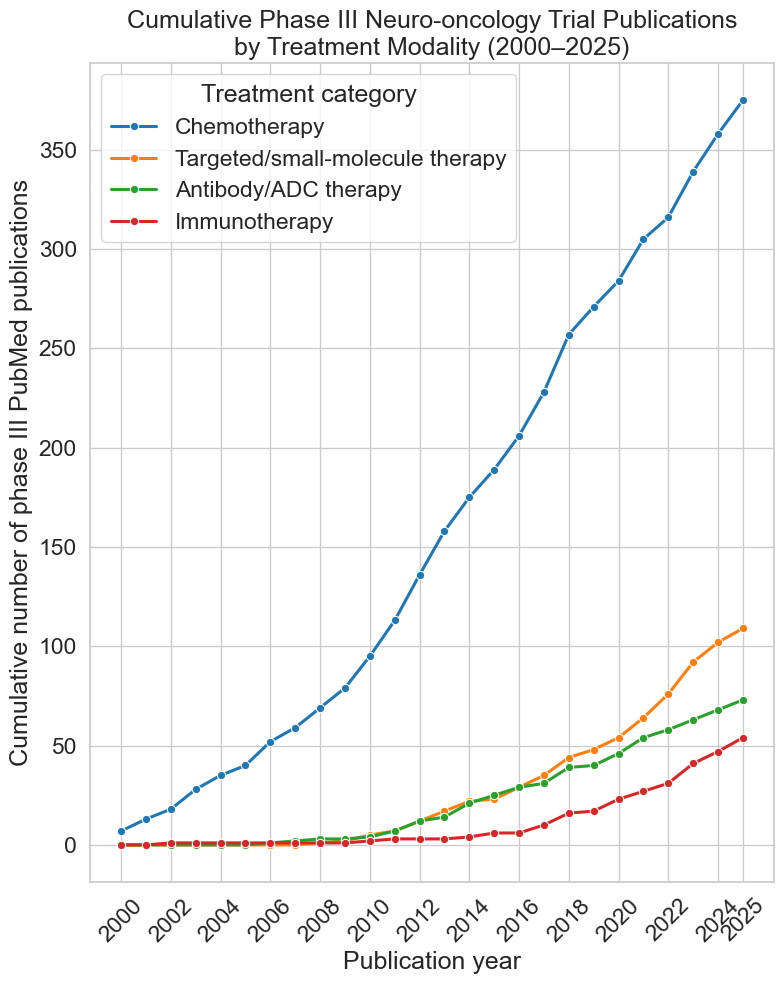

In [26]:
phase_iii_overall_cumulative = phase_iii_overall_trends.copy()
phase_iii_overall_cumulative["Cumulative publications"] = (
    phase_iii_overall_cumulative.groupby("Category", sort=False)["Publications"].cumsum()
)

fig, ax = plt.subplots(figsize=(8, 10))
sns.lineplot(
    data=phase_iii_overall_cumulative,
    x="Year",
    y="Cumulative publications",
    hue="Category",
    palette=treatment_colors,
    marker="o",
    linewidth=2.2,
    ax=ax,
)
ax.set_title("Cumulative Phase III Neuro-oncology Trial Publications\nby Treatment Modality (2000–2025)", fontsize=18)
ax.set_xlabel("Publication year", fontsize=18)
ax.set_ylabel("Cumulative number of phase III PubMed publications", fontsize=18)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xticks([*range(2000, 2025, 2), 2025])
ax.tick_params(axis="x", rotation=45, labelsize=16.5)
ax.tick_params(axis="y", labelsize=16.5)
ax.legend(
    title="Treatment category",
    fontsize=16.5,
    title_fontsize=18,
)
plt.tight_layout()
plt.show()

In [27]:
print("Fetching primary CNS tumor phase III trends by treatment modality...")
phase_iii_primary_cns_trends = get_phase_iii_context_modality_trends(
    PRIMARY_CNS_DISEASE_CONTEXT
)

Fetching primary CNS tumor phase III trends by treatment modality...
Fetching phase III Chemotherapy publications...
PubMed cache: 26 hit(s), 0 year(s) to fetch.
Fetching phase III Targeted/small-molecule therapy publications...
PubMed cache: 26 hit(s), 0 year(s) to fetch.
Fetching phase III Antibody/ADC therapy publications...
PubMed cache: 26 hit(s), 0 year(s) to fetch.
Fetching phase III Immunotherapy publications...
PubMed cache: 26 hit(s), 0 year(s) to fetch.


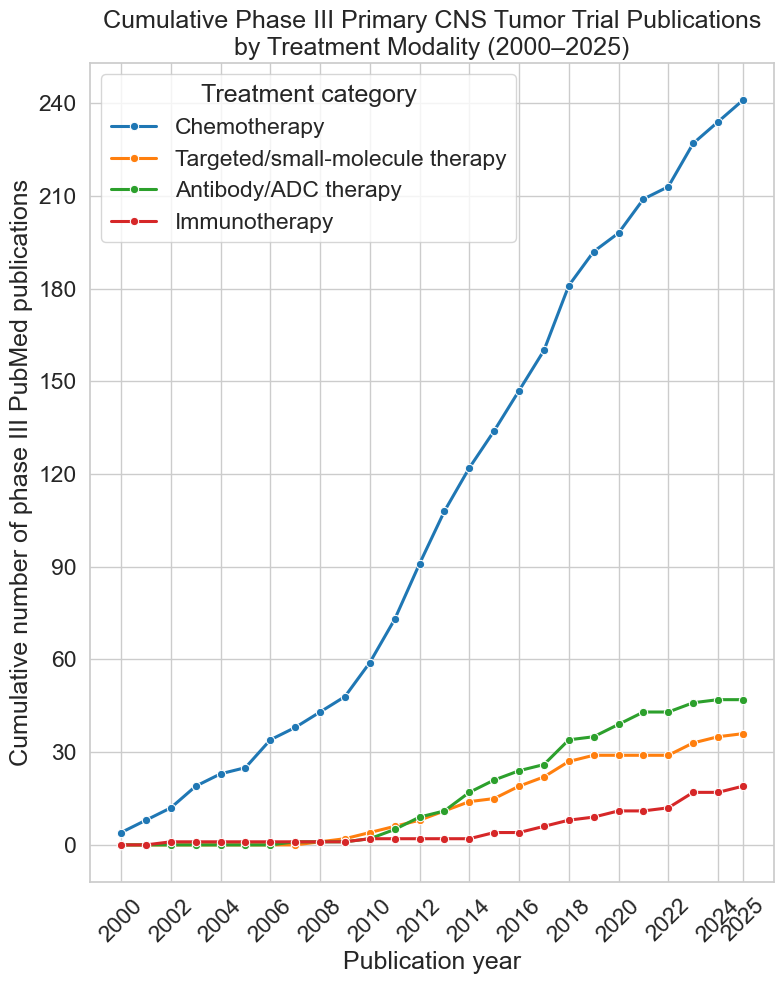

In [28]:
phase_iii_primary_cns_cumulative = phase_iii_primary_cns_trends.copy()
phase_iii_primary_cns_cumulative["Cumulative publications"] = (
    phase_iii_primary_cns_cumulative.groupby("Category", sort=False)["Publications"].cumsum()
)

fig, ax = plt.subplots(figsize=(8, 10))
sns.lineplot(
    data=phase_iii_primary_cns_cumulative,
    x="Year",
    y="Cumulative publications",
    hue="Category",
    palette=treatment_colors,
    marker="o",
    linewidth=2.2,
    ax=ax,
)
ax.set_title("Cumulative Phase III Primary CNS Tumor Trial Publications\nby Treatment Modality (2000–2025)", fontsize=18)
ax.set_xlabel("Publication year", fontsize=18)
ax.set_ylabel("Cumulative number of phase III PubMed publications", fontsize=18)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xticks([*range(2000, 2025, 2), 2025])
ax.tick_params(axis="x", rotation=45, labelsize=16.5)
ax.tick_params(axis="y", labelsize=16.5)
ax.legend(
    title="Treatment category",
    fontsize=16.5,
    title_fontsize=18,
)
plt.tight_layout()
plt.show()

In [29]:
PHASE_III_CNS_METASTASIS_CONTEXT = """
(
    "neurologic progression"[Title/Abstract]
    OR "Neurocognitive progression"[Title/Abstract]
    OR "survival"[Title/Abstract]
)
AND
(
    "Brain Metastasis"[Title/Abstract]
    OR "CNS Metastasis"[Title/Abstract]
)
""".strip()

print("Fetching CNS metastasis phase III trends by treatment modality...")
phase_iii_cns_metastasis_trends = get_phase_iii_context_modality_trends(
    PHASE_III_CNS_METASTASIS_CONTEXT
)

Fetching CNS metastasis phase III trends by treatment modality...
Fetching phase III Chemotherapy publications...
PubMed cache: 26 hit(s), 0 year(s) to fetch.
Fetching phase III Targeted/small-molecule therapy publications...
PubMed cache: 26 hit(s), 0 year(s) to fetch.
Fetching phase III Antibody/ADC therapy publications...
PubMed cache: 26 hit(s), 0 year(s) to fetch.
Fetching phase III Immunotherapy publications...
PubMed cache: 26 hit(s), 0 year(s) to fetch.


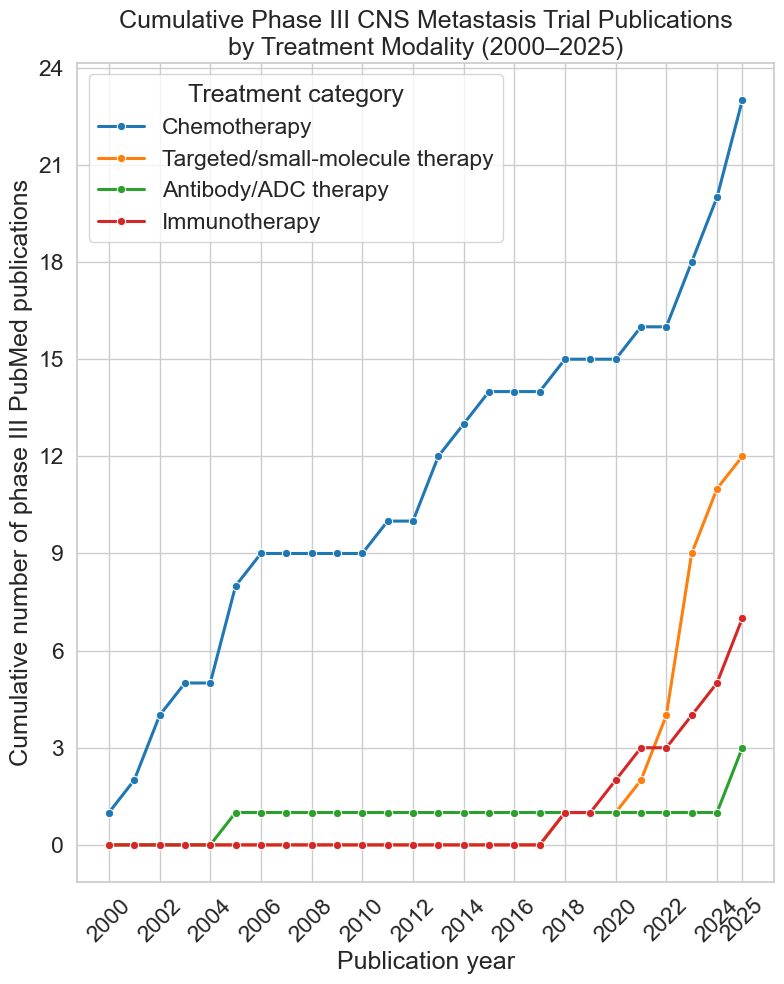

In [30]:
phase_iii_cns_metastasis_cumulative = phase_iii_cns_metastasis_trends.copy()
phase_iii_cns_metastasis_cumulative["Cumulative publications"] = (
    phase_iii_cns_metastasis_cumulative.groupby("Category", sort=False)["Publications"].cumsum()
)

fig, ax = plt.subplots(figsize=(8, 10))
sns.lineplot(
    data=phase_iii_cns_metastasis_cumulative,
    x="Year",
    y="Cumulative publications",
    hue="Category",
    palette=treatment_colors,
    marker="o",
    linewidth=2.2,
    ax=ax,
)
ax.set_title("Cumulative Phase III CNS Metastasis Trial Publications\nby Treatment Modality (2000–2025)", fontsize=18)
ax.set_xlabel("Publication year", fontsize=18)
ax.set_ylabel("Cumulative number of phase III PubMed publications", fontsize=18)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xticks([*range(2000, 2025, 2), 2025])
ax.tick_params(axis="x", rotation=45, labelsize=16.5)
ax.tick_params(axis="y", labelsize=16.5)
ax.legend(
    title="Treatment category",
    fontsize=16.5,
    title_fontsize=18,
)
plt.tight_layout()
plt.show()

## Molecular-target publication trends by target family, 2000–2025

Each target is searched in PubMed titles and abstracts using its symbol plus established aliases. Results are limited to records indexed as Clinical Study, Clinical Trial (including phase, protocol, controlled, randomized, adaptive, pragmatic, and equivalence trial types), Multicenter Study, or Journal Article, while excluding Review, Systematic Review, and Meta-Analysis publication types. Targets are shown as separate annual lines within family panels, and members of the same family use shades from the same color map. Three figures cover overall neuro-oncology, primary CNS tumors, and CNS metastasis. Within each context, target series with zero publications across the full 2000–2025 interval are omitted.

In [31]:
import math
import re
import textwrap
import numpy as np

MOLECULAR_TARGET_FAMILIES = {
    "ErbB / EGFR family": {
        "EGFR": ["EGFR", "ERBB1", "epidermal growth factor receptor"],
        "HER2": ["HER2", "ERBB2", "human epidermal growth factor receptor 2"],
        "HER4": ["HER4", "ERBB4", "human epidermal growth factor receptor 4"],
    },
    "VEGFR family": {
        "VEGFR1": ["VEGFR1", "VEGFR-1", "FLT1", "vascular endothelial growth factor receptor 1"],
        "VEGFR2": ["VEGFR2", "VEGFR-2", "KDR", "vascular endothelial growth factor receptor 2"],
        "VEGFR3": ["VEGFR3", "VEGFR-3", "FLT4", "vascular endothelial growth factor receptor 3"],
    },
    "PDGFR / KIT / ABL": {
        "PDGFRα": ["PDGFRA", "PDGFR alpha", "PDGFR-alpha", "PDGFRα", "platelet-derived growth factor receptor alpha"],
        "PDGFRβ": ["PDGFRB", "PDGFR beta", "PDGFR-beta", "PDGFRβ", "platelet-derived growth factor receptor beta"],
        "KIT": ["c-KIT", "CD117", "KIT receptor", "KIT proto-oncogene"],
        "ABL1": ["ABL1", "c-ABL", "ABL proto-oncogene 1"],
        "BCR-ABL": ["BCR-ABL", "BCR-ABL1", "BCR::ABL1"],
    },
    "RAF / MAPK pathway": {
        "BRAF": ["BRAF", "B-RAF"],
        "CRAF": ["CRAF", "C-RAF", "RAF1"],
        "ARAF": ["ARAF", "A-RAF"],
        "MEK1": ["MEK1", "MAP2K1"],
        "MEK2": ["MEK2", "MAP2K2"],
    },
    "IDH": {
        "IDH1": ["IDH1", "isocitrate dehydrogenase 1"],
        "IDH2": ["IDH2", "isocitrate dehydrogenase 2"],
    },
    "TRK / NTRK": {
        "TRKA": ["TRKA", "NTRK1"],
        "TRKB": ["TRKB", "NTRK2"],
        "TRKC": ["TRKC", "NTRK3"],
    },
    "Receptor tyrosine kinases": {
        "ALK": ["ALK", "anaplastic lymphoma kinase"],
        "ROS1": ["ROS1", "ROS proto-oncogene 1"],
        "MET": ["c-MET", "MET receptor", "MET proto-oncogene", "hepatocyte growth factor receptor"],
        "RET": ["RET receptor", "RET proto-oncogene"],
    },
    "RAS": {
        "KRAS": ["KRAS", "K-RAS"],
    },
    "Cell-cycle regulators": {
        "CDK4": ["CDK4", "cyclin-dependent kinase 4"],
        "CDK6": ["CDK6", "cyclin-dependent kinase 6"],
    },
    "PI3K–AKT–mTOR pathway": {
        "PI3Kα": ["PI3K alpha", "PI3K-alpha", "PI3Kα", "PIK3CA"],
        "mTOR": ["mTOR", "mechanistic target of rapamycin"],
        "FKBP12": ["FKBP12", "FKBP1A"],
    },
    "DNA repair": {
        "PARP1": ["PARP1", "poly ADP ribose polymerase 1"],
        "PARP2": ["PARP2", "poly ADP ribose polymerase 2"],
        "PARP3": ["PARP3", "poly ADP ribose polymerase 3"],
    },
    "Protein prenylation": {
        "Farnesyltransferase": ["Farnesyltransferase", "Farnesyl transferase", "FTase"],
    },
    "Epigenetic regulators": {
        "HDAC1": ["HDAC1", "histone deacetylase 1"],
        "HDAC2": ["HDAC2", "histone deacetylase 2"],
        "HDAC3": ["HDAC3", "histone deacetylase 3"],
        "HDAC6": ["HDAC6", "histone deacetylase 6"],
    },
    "Integrins": {
        "Integrin αvβ3": ["integrin αvβ3", "integrin alpha v beta 3", "alpha(v)beta(3) integrin"],
        "Integrin αvβ5": ["integrin αvβ5", "integrin alpha v beta 5", "alpha(v)beta(5) integrin"],
    },
    "ONC201 / dordaviprone targets": {
        "ClpP": ["CLPP", "caseinolytic mitochondrial matrix peptidase proteolytic subunit"],
        "DRD2": ["DRD2", "dopamine D2 receptor"],
    },
    "Monocarboxylate transporters": {
        "MCT1": ["MCT1", "SLC16A1", "monocarboxylate transporter 1"],
        "MCT2": ["MCT2", "SLC16A7", "monocarboxylate transporter 2"],
        "MCT4": ["MCT4", "SLC16A3", "monocarboxylate transporter 4"],
    },
}

TARGET_FAMILY_COLORMAPS = {
    "ErbB / EGFR family": "Reds",
    "VEGFR family": "Blues",
    "PDGFR / KIT / ABL": "Purples",
    "RAF / MAPK pathway": "Oranges",
    "IDH": "Greens",
    "TRK / NTRK": "PuRd",
    "Receptor tyrosine kinases": "GnBu",
    "RAS": "YlOrBr",
    "Cell-cycle regulators": "RdPu",
    "PI3K–AKT–mTOR pathway": "BuPu",
    "DNA repair": "YlGn",
    "Protein prenylation": "Greys",
    "Epigenetic regulators": "PuBu",
    "Integrins": "YlOrRd",
    "ONC201 / dordaviprone targets": "cool",
    "Monocarboxylate transporters": "winter",
}

PRIMARY_LITERATURE_FILTER = """
(
    "Clinical Study"[pt]
    OR "Clinical Trial"[pt]
    OR "Clinical Trial, Phase I"[pt]
    OR "Clinical Trial, Phase II"[pt]
    OR "Clinical Trial, Phase III"[pt]
    OR "Clinical Trial, Phase IV"[pt]
    OR "Clinical Trial Protocol"[pt]
    OR "Controlled Clinical Trial"[pt]
    OR "Randomized Controlled Trial"[pt]
    OR "Adaptive Clinical Trial"[pt]
    OR "Pragmatic Clinical Trial"[pt]
    OR "Equivalence Trial"[pt]
    OR "Multicenter Study"[pt]
    OR "Journal Article"[pt]
)
AND NOT (
    "Review"[pt]
    OR "Systematic Review"[pt]
    OR "Meta-Analysis"[pt]
)
""".strip()


def build_target_query(aliases):
    return "(" + " OR ".join(
        f'"{alias}"[Title/Abstract]' for alias in aliases
    ) + ")"

def get_target_year_counts(
    context_query,
    aliases,
    start_year=2000,
    end_year=2025,
    force_refresh=False,
):
    target_query = build_target_query(aliases)
    search_query = (
        f"({context_query}) AND {target_query} "
        f"AND ({start_year}:{end_year}[pdat]) "
        f"AND {PRIMARY_LITERATURE_FILTER}"
    )
    normalized_query = _normalize_pubmed_query(search_query)
    query_key = _pubmed_query_key(search_query)

    if not force_refresh:
        with _open_pubmed_cache() as connection:
            cached = connection.execute(
                """
                SELECT yearly_counts_json, total_records
                FROM target_year_counts
                WHERE query_key = ?
                """,
                (query_key,),
            ).fetchone()
        if cached is not None:
            yearly_counts = {
                int(year): int(count)
                for year, count in json.loads(cached[0]).items()
            }
            return yearly_counts, int(cached[1])

    search_record = read_entrez_with_retries(
        lambda: Entrez.esearch(
            db="pubmed", term=search_query, retmax=0, usehistory="y"
        ),
        "target search",
    )
    total_records = int(search_record["Count"])
    yearly_counts = {year: 0 for year in range(start_year, end_year + 1)}
    batch_size = 1000
    for retstart in range(0, total_records, batch_size):
        summaries = read_entrez_with_retries(
            lambda retstart=retstart: Entrez.esummary(
                db="pubmed",
                query_key=search_record["QueryKey"],
                WebEnv=search_record["WebEnv"],
                retstart=retstart,
                retmax=batch_size,
            ),
            f"target summaries starting at {retstart}",
        )
        for summary in summaries:
            year_match = re.search(r"\b(19|20)\d{2}\b", str(summary.get("PubDate", "")))
            if year_match:
                year = int(year_match.group(0))
                if year in yearly_counts:
                    yearly_counts[year] += 1

    # Store only a fully successful target retrieval.
    with _open_pubmed_cache() as connection:
        connection.execute(
            """
            INSERT INTO target_year_counts
                (query_key, normalized_query, start_year, end_year,
                 yearly_counts_json, total_records, fetched_at)
            VALUES (?, ?, ?, ?, ?, ?, CURRENT_TIMESTAMP)
            ON CONFLICT(query_key) DO UPDATE SET
                normalized_query = excluded.normalized_query,
                start_year = excluded.start_year,
                end_year = excluded.end_year,
                yearly_counts_json = excluded.yearly_counts_json,
                total_records = excluded.total_records,
                fetched_at = CURRENT_TIMESTAMP
            """,
            (
                query_key,
                normalized_query,
                start_year,
                end_year,
                json.dumps(yearly_counts, sort_keys=True),
                total_records,
            ),
        )
    return yearly_counts, total_records

def remove_zero_only_target_series(data):
    """Remove targets with no publications in any year for the current context."""
    totals = data.groupby(["Context", "Family", "Target"])["Publications"].transform("sum")
    zero_only = data.loc[totals.eq(0), "Target"].drop_duplicates().tolist()
    if zero_only:
        print("Removed zero-only target series: " + ", ".join(zero_only))
    return data.loc[totals.gt(0)].copy()


def get_molecular_target_trends(context_label, context_query, start_year=2000, end_year=2025):
    rows = []
    for family, targets in MOLECULAR_TARGET_FAMILIES.items():
        for target, aliases in targets.items():
            yearly_counts, total_records = get_target_year_counts(
                context_query, aliases, start_year, end_year
            )
            print(f"{context_label} | {family} | {target}: {total_records:,} publications")
            rows.extend(
                {
                    "Context": context_label,
                    "Family": family,
                    "Target": target,
                    "Year": year,
                    "Publications": count,
                }
                for year, count in yearly_counts.items()
            )
    return remove_zero_only_target_series(pd.DataFrame(rows))

def plot_molecular_target_families(data, title):
    families = [
        family for family in MOLECULAR_TARGET_FAMILIES
        if family in set(data["Family"])
    ]
    ncols = 3
    nrows = math.ceil(len(families) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 27), constrained_layout=True)
    line_styles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]
    for ax, family in zip(axes.flat, families):
        targets = [
            target for target in MOLECULAR_TARGET_FAMILIES[family]
            if target in set(data.loc[data["Family"] == family, "Target"])
        ]
        cmap = plt.get_cmap(TARGET_FAMILY_COLORMAPS[family])
        shade_positions = np.linspace(0.45, 0.9, len(targets)) if len(targets) > 1 else [0.7]
        for index, (target, shade_position) in enumerate(zip(targets, shade_positions)):
            target_data = data[(data["Family"] == family) & (data["Target"] == target)].sort_values("Year").copy()
            target_data["Cumulative publications"] = target_data["Publications"].cumsum()
            ax.plot(
                target_data["Year"],
                target_data["Cumulative publications"],
                label=target,
                color=cmap(shade_position),
                linestyle=line_styles[index % len(line_styles)],
                linewidth=2,
            )
        ax.set_title(textwrap.fill(family, width=24), fontsize=27, fontweight="bold")
        ax.set_xticks([2000, 2005, 2010, 2015, 2020, 2025])
        ax.tick_params(axis="x", rotation=45, labelsize=22.5)
        ax.tick_params(axis="y", labelsize=22.5)
        ax.grid(alpha=0.25)
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        ax.legend(loc="upper left", fontsize=18, frameon=True)
    for ax in axes.flat[len(families):]:
        ax.set_visible(False)
    wrapped_title = title.replace(" Publications in ", " Publications\nin ")
    fig.suptitle(wrapped_title, fontsize=40.5, fontweight="bold", linespacing=1.0)
    fig.supxlabel("Publication year", fontsize=27)
    fig.supylabel("Cumulative number of primary PubMed publications", fontsize=27)
    return fig

print("Fetching molecular-target trends for overall neuro-oncology...")
all_neuro_oncology_target_trends = get_molecular_target_trends(
    "Overall neuro-oncology", NEURO_ONCOLOGY_DISEASE_CONTEXT
)

Fetching molecular-target trends for overall neuro-oncology...
Overall neuro-oncology | ErbB / EGFR family | EGFR: 1,002 publications
Overall neuro-oncology | ErbB / EGFR family | HER2: 346 publications
Overall neuro-oncology | ErbB / EGFR family | HER4: 11 publications
Overall neuro-oncology | VEGFR family | VEGFR1: 23 publications
Overall neuro-oncology | VEGFR family | VEGFR2: 36 publications
Overall neuro-oncology | VEGFR family | VEGFR3: 5 publications
Overall neuro-oncology | PDGFR / KIT / ABL | PDGFRα: 55 publications
Overall neuro-oncology | PDGFR / KIT / ABL | PDGFRβ: 7 publications
Overall neuro-oncology | PDGFR / KIT / ABL | KIT: 28 publications
Overall neuro-oncology | PDGFR / KIT / ABL | ABL1: 3 publications
Overall neuro-oncology | PDGFR / KIT / ABL | BCR-ABL: 11 publications
Overall neuro-oncology | RAF / MAPK pathway | BRAF: 440 publications
Overall neuro-oncology | RAF / MAPK pathway | CRAF: 6 publications
Overall neuro-oncology | RAF / MAPK pathway | ARAF: 0 publicati

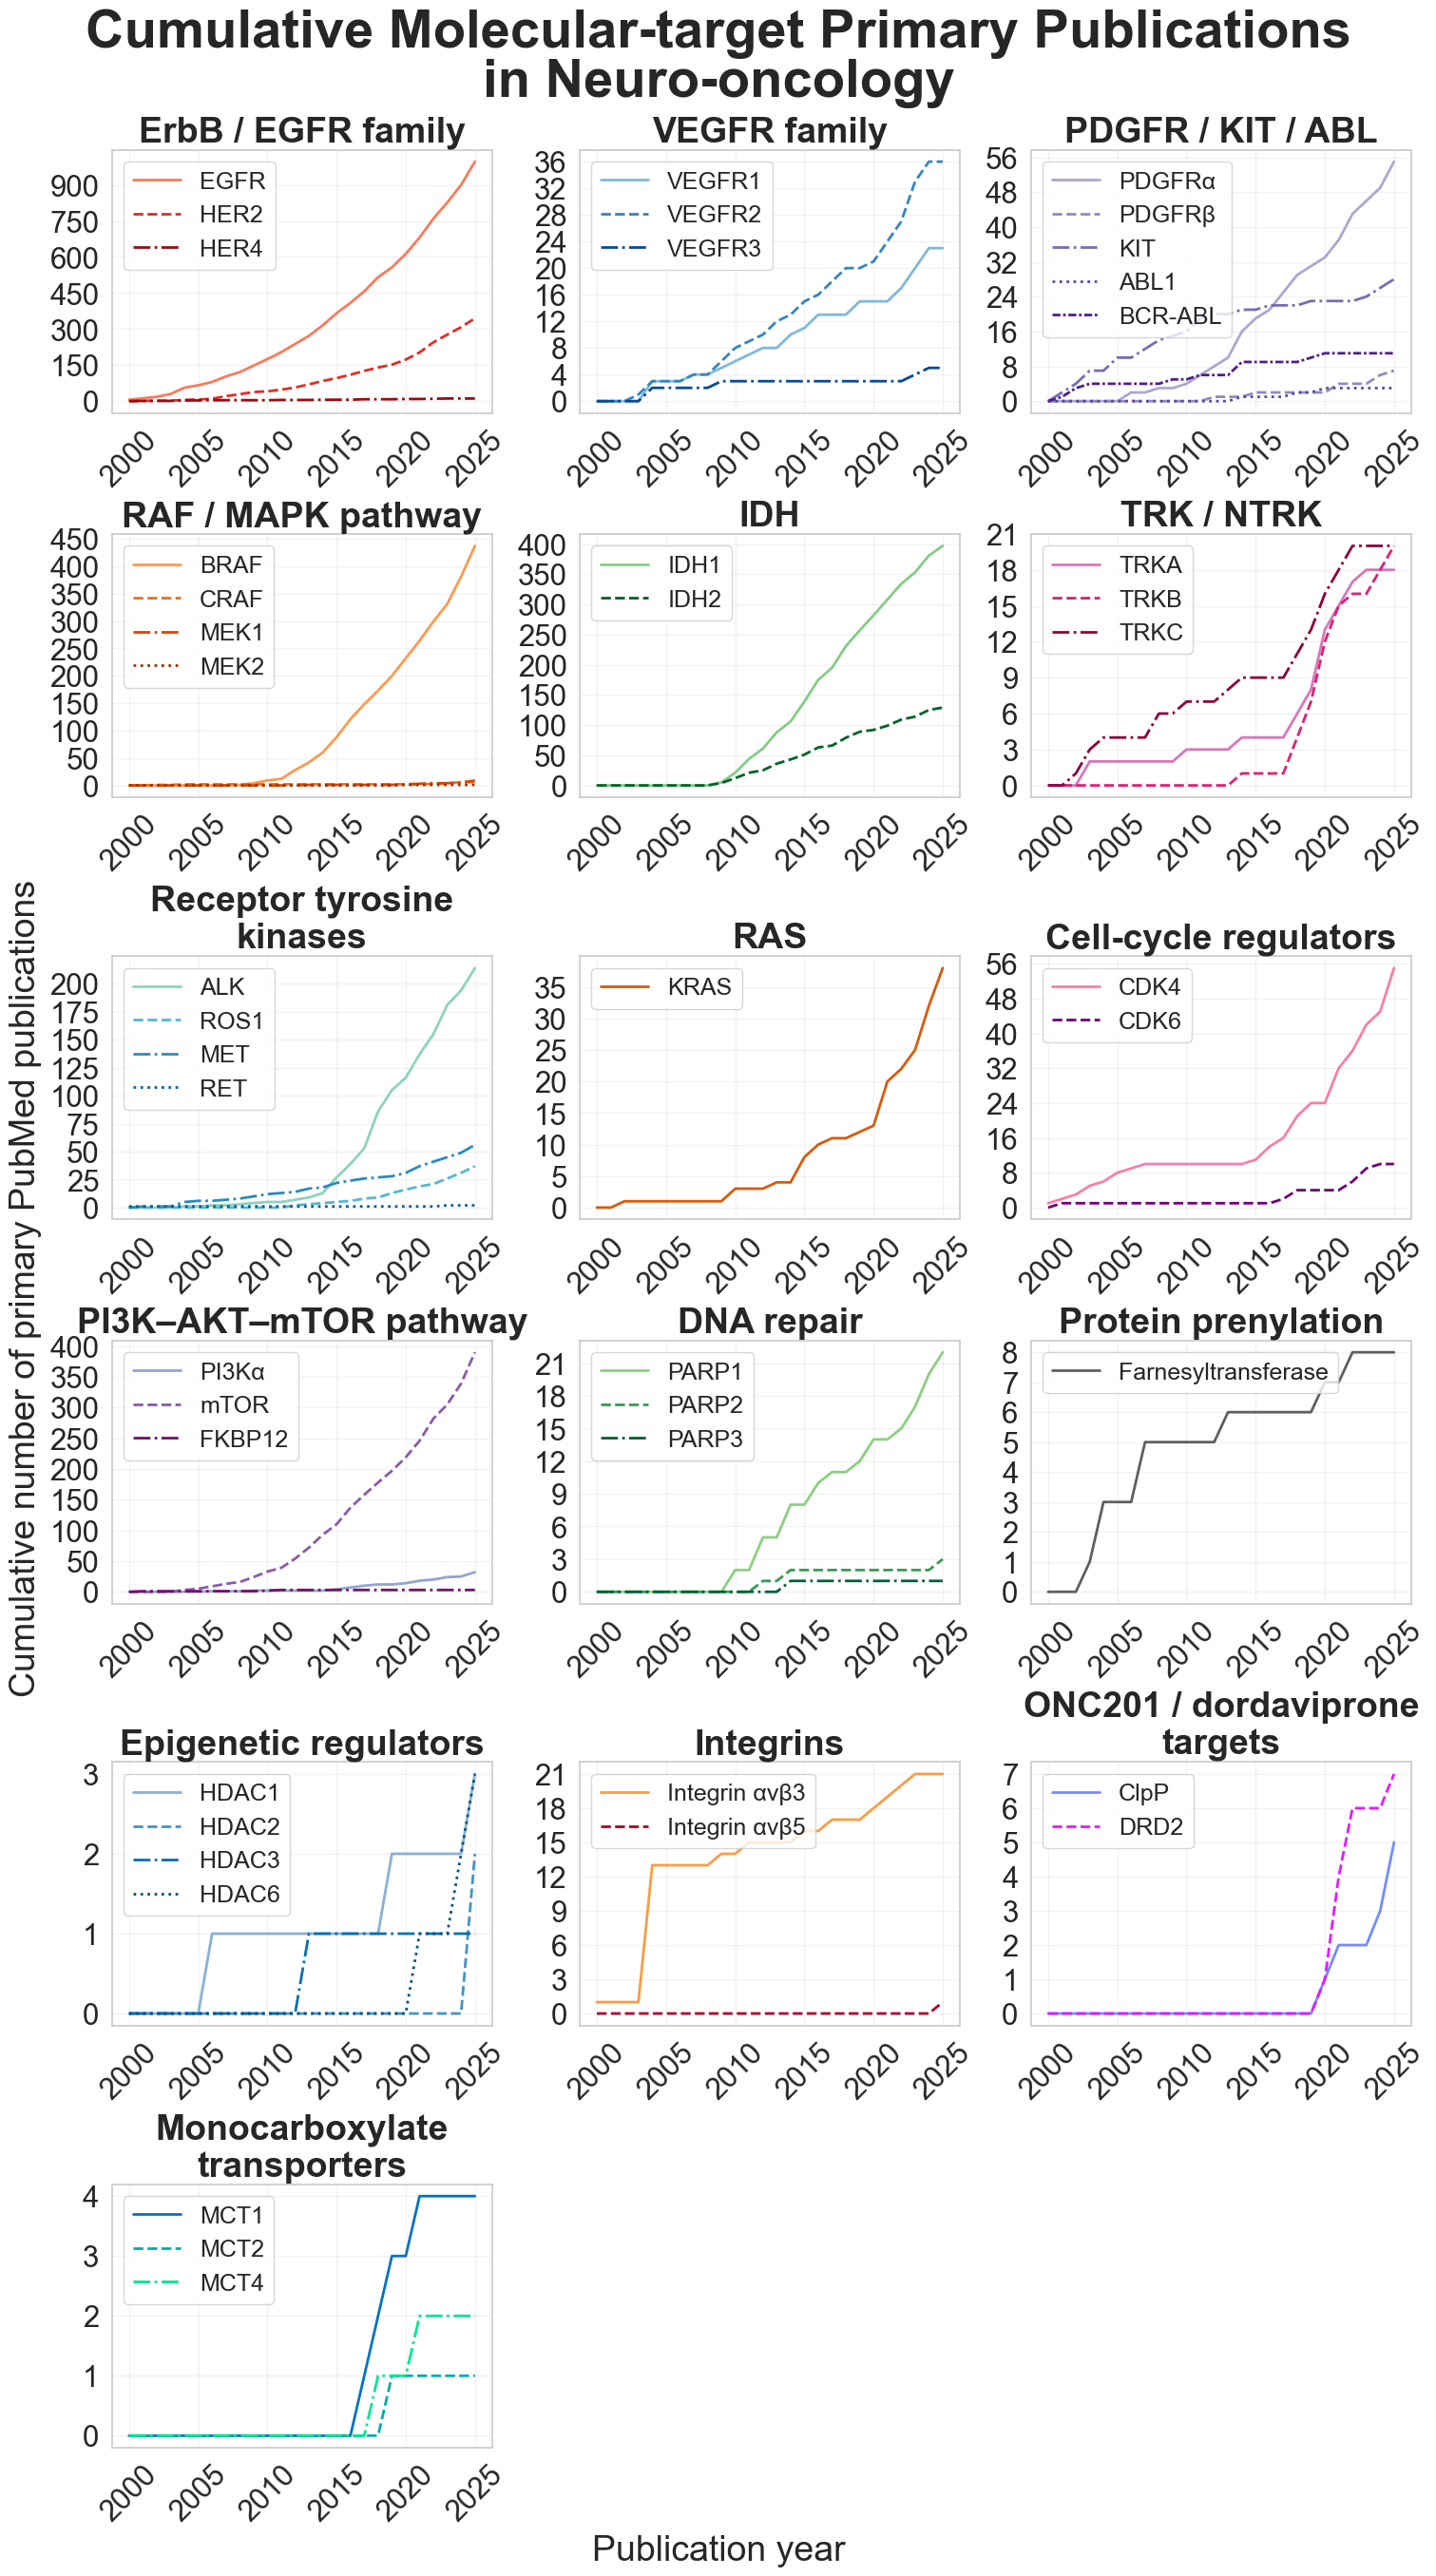

In [32]:
plot_molecular_target_families(
    all_neuro_oncology_target_trends,
    "Cumulative Molecular-target Primary Publications in Neuro-oncology",
)
plt.show()

In [33]:
print("Fetching molecular-target trends for primary CNS tumors...")
primary_cns_target_trends = get_molecular_target_trends(
    "Primary CNS tumors", PRIMARY_CNS_DISEASE_CONTEXT
)

Fetching molecular-target trends for primary CNS tumors...
Primary CNS tumors | ErbB / EGFR family | EGFR: 639 publications
Primary CNS tumors | ErbB / EGFR family | HER2: 73 publications
Primary CNS tumors | ErbB / EGFR family | HER4: 10 publications
Primary CNS tumors | VEGFR family | VEGFR1: 19 publications
Primary CNS tumors | VEGFR family | VEGFR2: 31 publications
Primary CNS tumors | VEGFR family | VEGFR3: 5 publications
Primary CNS tumors | PDGFR / KIT / ABL | PDGFRα: 54 publications
Primary CNS tumors | PDGFR / KIT / ABL | PDGFRβ: 6 publications
Primary CNS tumors | PDGFR / KIT / ABL | KIT: 25 publications
Primary CNS tumors | PDGFR / KIT / ABL | ABL1: 3 publications
Primary CNS tumors | PDGFR / KIT / ABL | BCR-ABL: 11 publications
Primary CNS tumors | RAF / MAPK pathway | BRAF: 327 publications
Primary CNS tumors | RAF / MAPK pathway | CRAF: 6 publications
Primary CNS tumors | RAF / MAPK pathway | ARAF: 0 publications
Primary CNS tumors | RAF / MAPK pathway | MEK1: 9 publicati

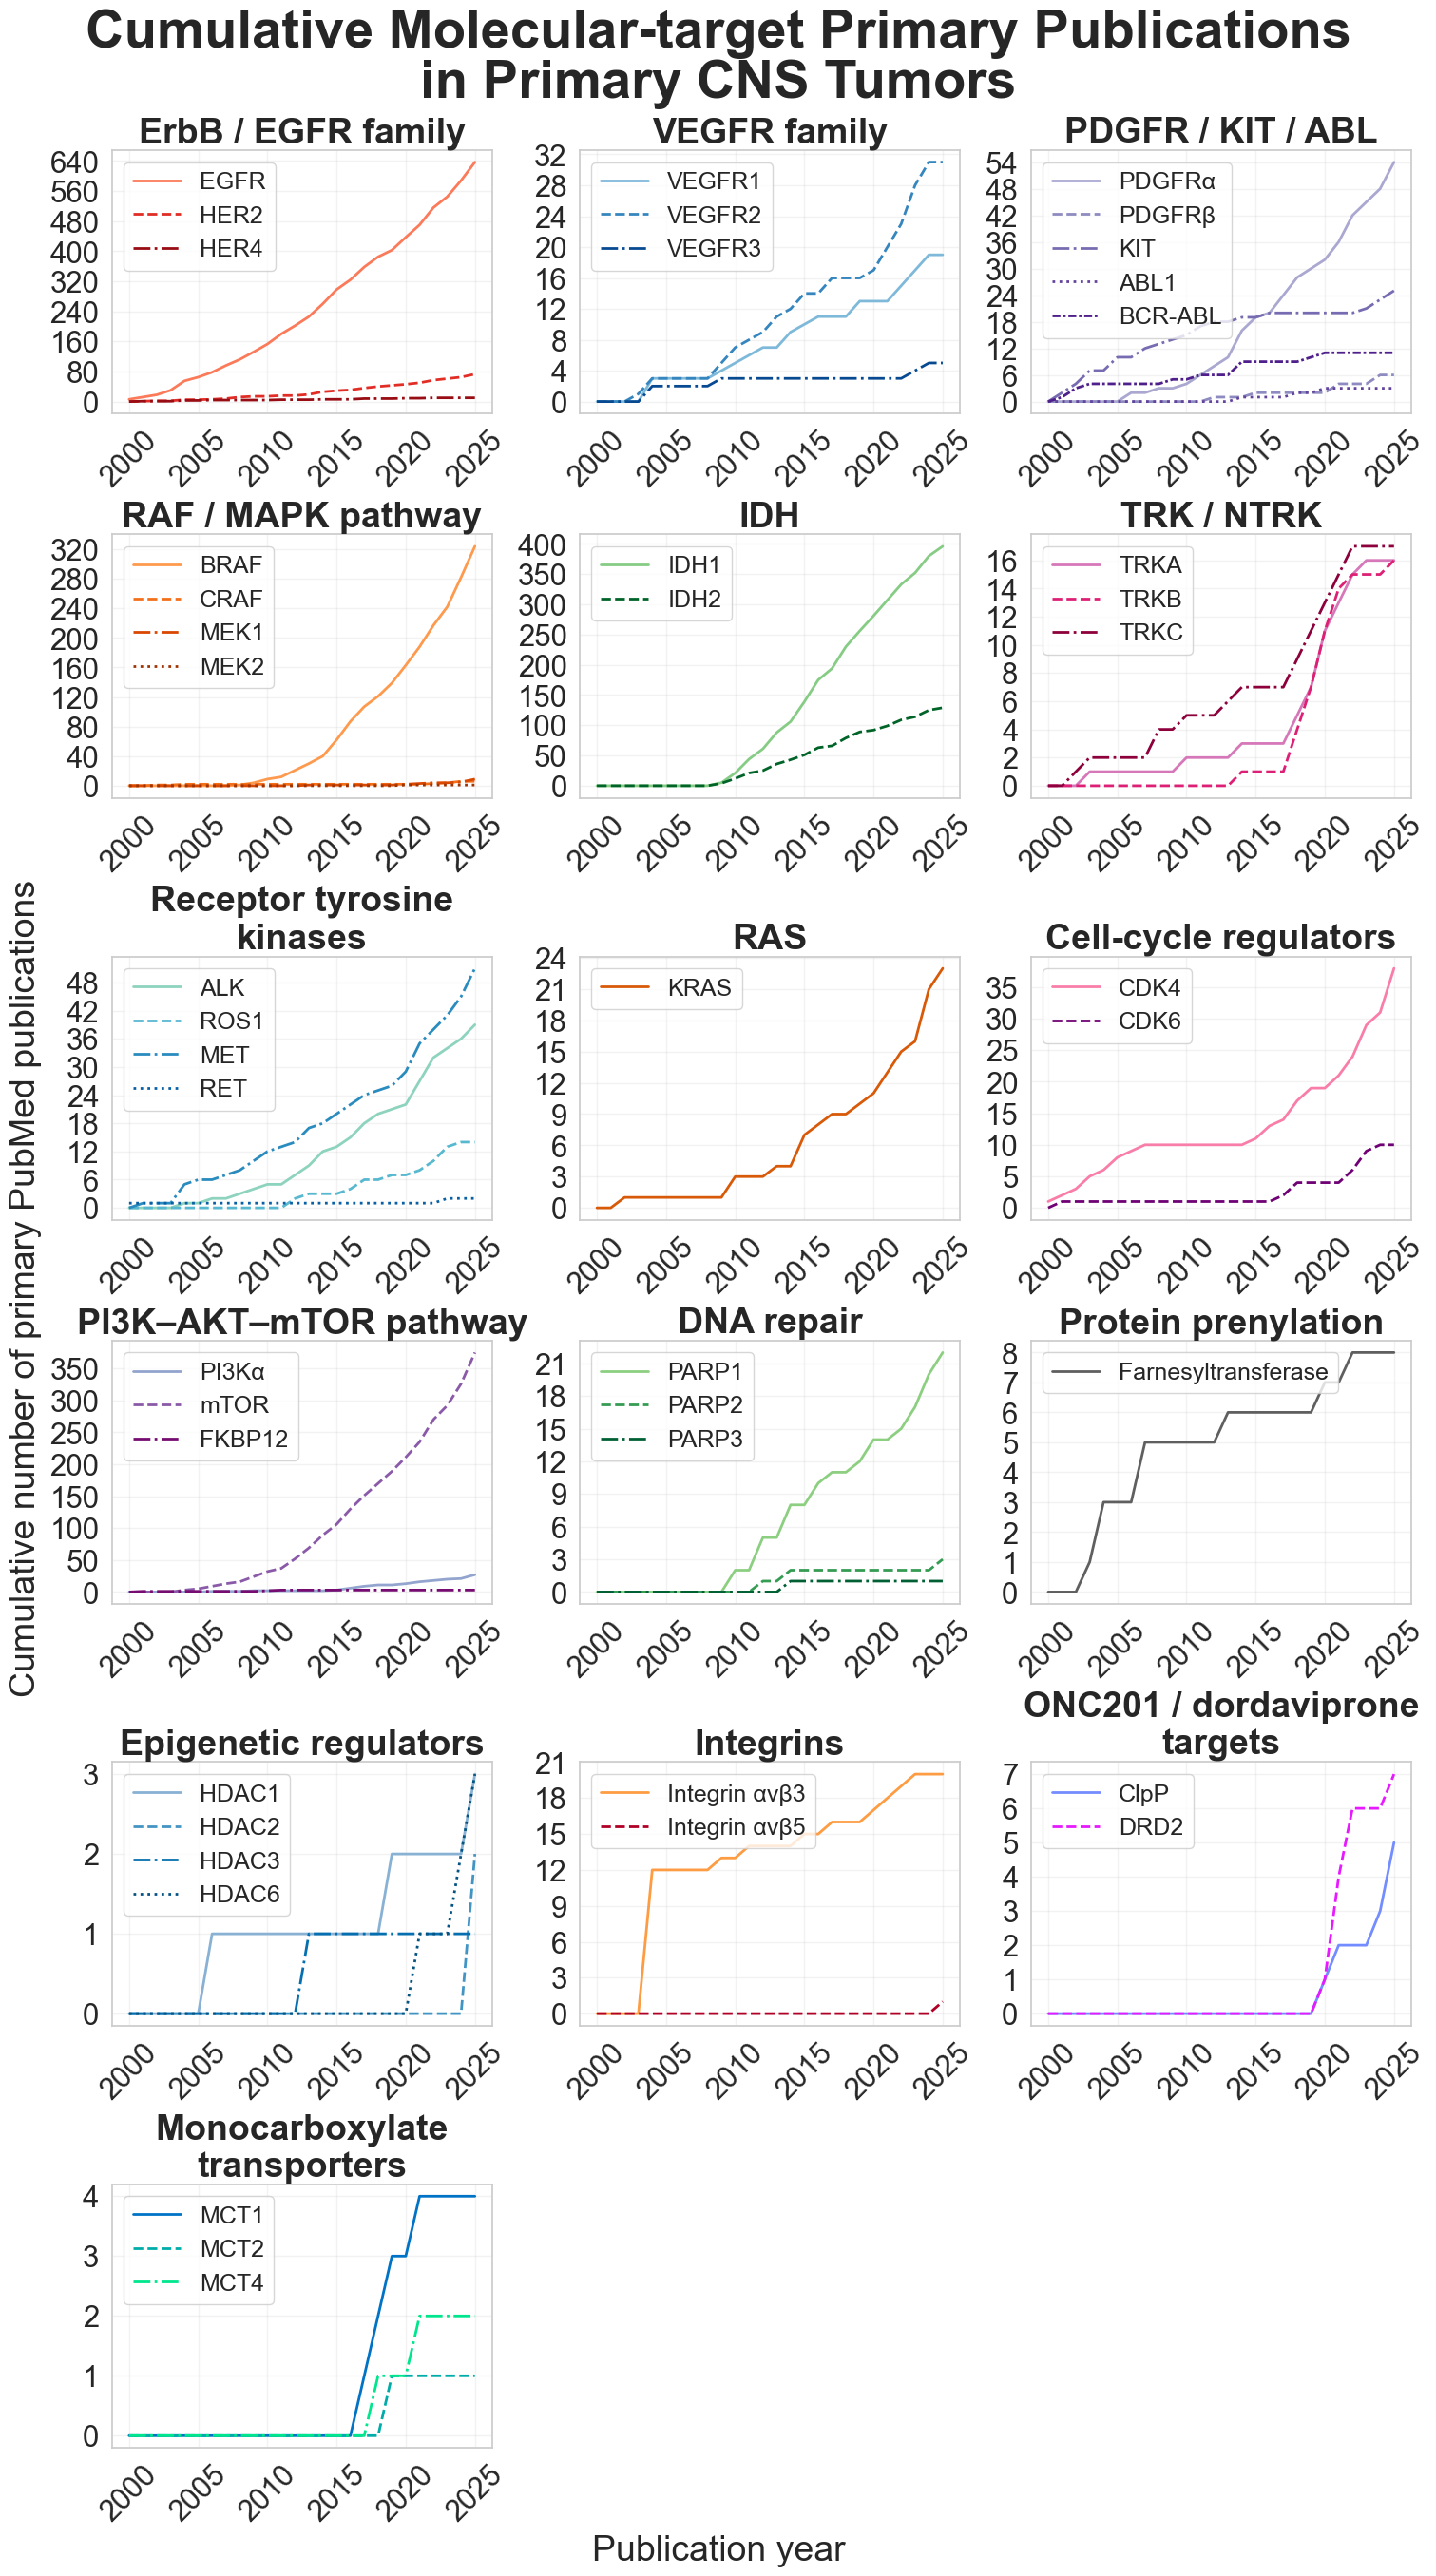

In [34]:
plot_molecular_target_families(
    primary_cns_target_trends,
    "Cumulative Molecular-target Primary Publications in Primary CNS Tumors",
)
plt.show()

In [35]:
print("Fetching molecular-target trends for CNS metastasis...")
cns_metastasis_target_trends = get_molecular_target_trends(
    "CNS metastasis", CNS_METASTASIS_DISEASE_CONTEXT
)

Fetching molecular-target trends for CNS metastasis...
CNS metastasis | ErbB / EGFR family | EGFR: 368 publications
CNS metastasis | ErbB / EGFR family | HER2: 275 publications
CNS metastasis | ErbB / EGFR family | HER4: 1 publications
CNS metastasis | VEGFR family | VEGFR1: 4 publications
CNS metastasis | VEGFR family | VEGFR2: 5 publications
CNS metastasis | VEGFR family | VEGFR3: 0 publications
CNS metastasis | PDGFR / KIT / ABL | PDGFRα: 1 publications
CNS metastasis | PDGFR / KIT / ABL | PDGFRβ: 1 publications
CNS metastasis | PDGFR / KIT / ABL | KIT: 3 publications
CNS metastasis | PDGFR / KIT / ABL | ABL1: 0 publications
CNS metastasis | PDGFR / KIT / ABL | BCR-ABL: 0 publications
CNS metastasis | RAF / MAPK pathway | BRAF: 115 publications
CNS metastasis | RAF / MAPK pathway | CRAF: 0 publications
CNS metastasis | RAF / MAPK pathway | ARAF: 0 publications
CNS metastasis | RAF / MAPK pathway | MEK1: 0 publications
CNS metastasis | RAF / MAPK pathway | MEK2: 0 publications
CNS me

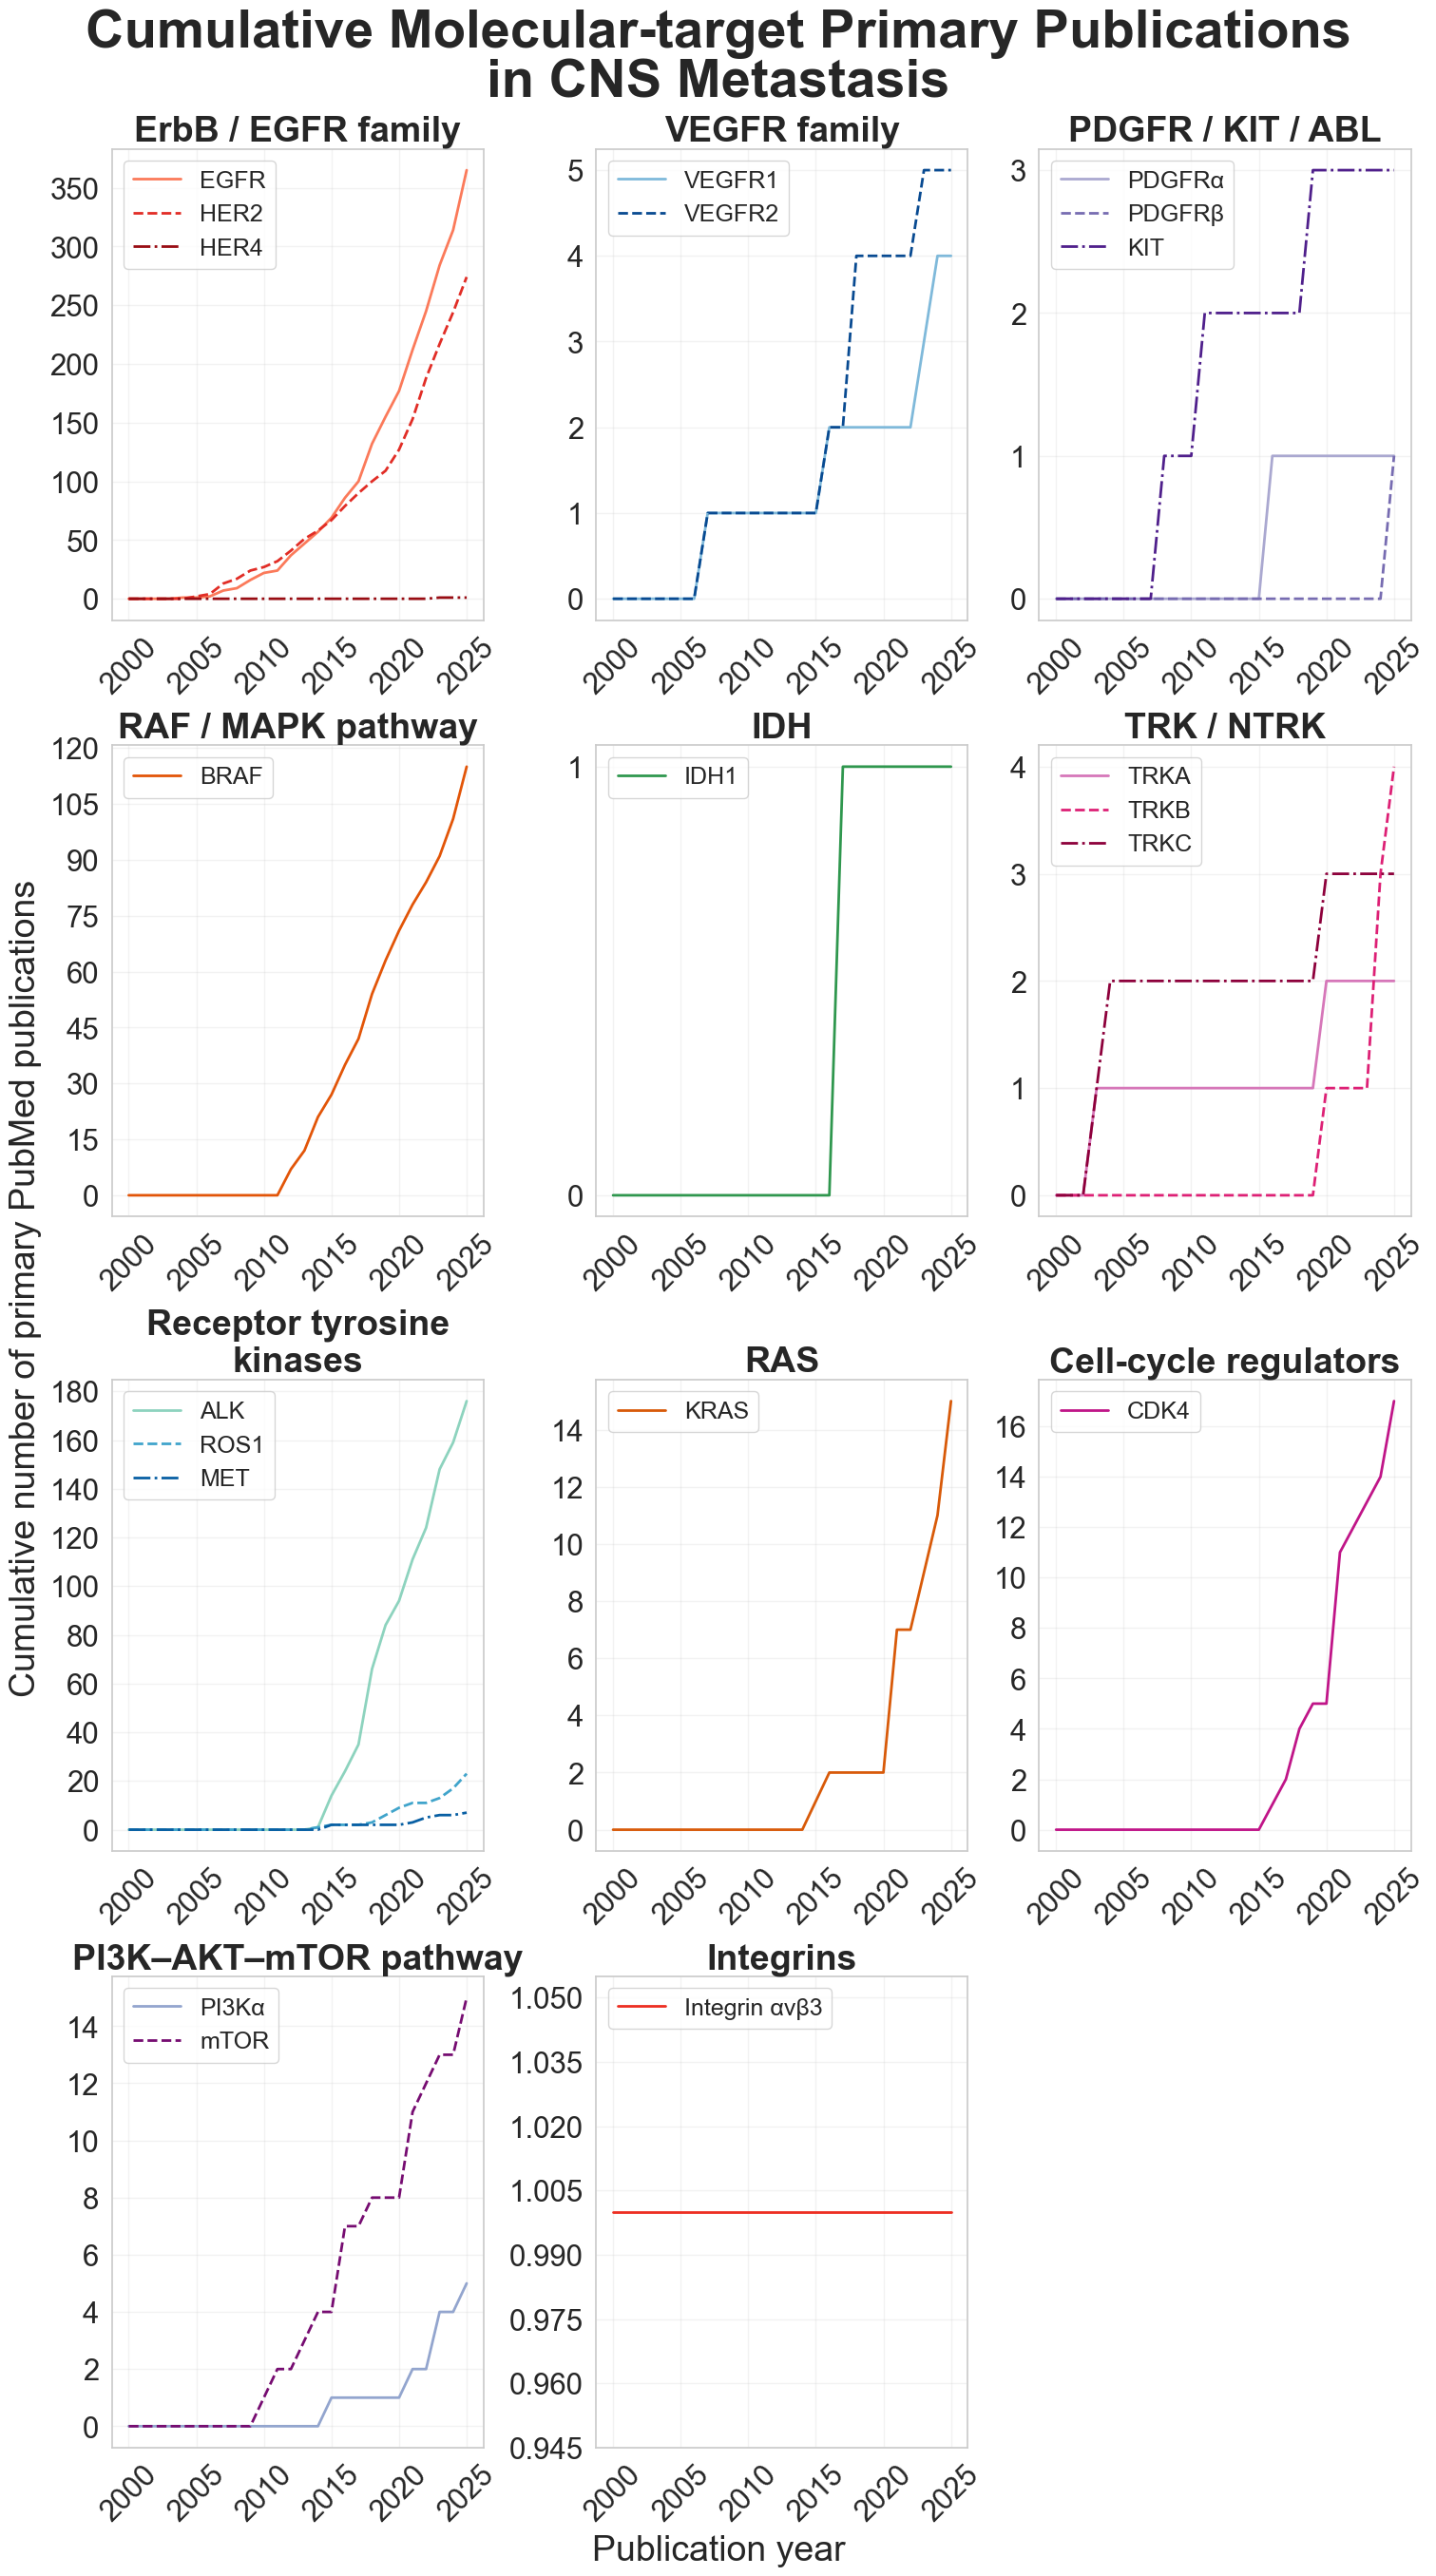

In [36]:
plot_molecular_target_families(
    cns_metastasis_target_trends,
    "Cumulative Molecular-target Primary Publications in CNS Metastasis",
)
plt.show()

## Biologic and antibody-drug conjugate target trends, 2000–2025

This section applies the same target-level approach used above while excluding targets already analyzed in the small-molecule section and the immune checkpoint/immunoregulatory target family. Each biologic target is searched through its supplied symbol/name aliases in PubMed titles and abstracts, then combined with the relevant neuro-oncology disease context and the 2000–2025 publication-date range. Results use the same allowed publication-type filter (Clinical Study, the listed clinical-trial types, Multicenter Study, or Journal Article) and exclude Review, Systematic Review, and Meta-Analysis records.

The family-panel figures show targets separately with related targets in shades of the same family color. Separate analyses are shown for overall neuro-oncology, primary CNS tumors, and CNS metastasis. Within each context, target series with zero publications across the full 2000–2025 interval are omitted. A publication may contribute to more than one target curve when multiple target terms appear in its title or abstract.


In [37]:
BIOLOGIC_TARGET_FAMILIES = {
    "Growth factor / angiogenesis": {
        "VEGF-A": ["VEGFA", "VEGF-A", "vascular endothelial growth factor A"],
    },
    "ErbB receptor family": {
        "HER3 / ERBB3": [
            "HER3",
            "ERBB3",
            "human epidermal growth factor receptor 3",
        ],
    },
    "Cell-surface glycoproteins / adhesion molecules": {
        "TROP2 / TACSTD2": [
            "TROP2",
            "TROP-2",
            "TACSTD2",
            "tumor-associated calcium signal transducer 2",
        ],
        "NECTIN4": ["NECTIN4", "Nectin-4", "PVRL4"],
        "ALCAM / CD166": [
            "ALCAM",
            "CD166",
            "activated leukocyte cell adhesion molecule",
        ],
        "ZIP6 / SLC39A6": ["ZIP6", "SLC39A6", "LIV-1", "zinc transporter ZIP6"],
    },
    "Gangliosides": {
        "GD2": ["GD2", "disialoganglioside GD2"],
    },
    "Folate receptor": {
        "FOLR1 / FRα": [
            "FOLR1",
            "FRα",
            "FRalpha",
            "folate receptor alpha",
        ],
    },
    "Claudins / tight-junction proteins": {
        "CLDN6": ["CLDN6", "claudin 6"],
        "CLDN18.2": ["CLDN18.2", "claudin 18.2", "CLDN18 isoform 2"],
    },
    "Coagulation-related surface target": {
        "Tissue Factor / CD142": [
            "Tissue Factor",
            "CD142",
            "coagulation factor III",
        ],
    },
    "Receptor tyrosine kinase-like orphan receptors": {
        "ROR1": ["ROR1", "receptor tyrosine kinase-like orphan receptor 1"],
        "ROR2": ["ROR2", "receptor tyrosine kinase-like orphan receptor 2"],
    },
}

BIOLOGIC_TARGET_FAMILY_COLORMAPS = {
    "Growth factor / angiogenesis": "Greens",
    "ErbB receptor family": "Reds",
    "Cell-surface glycoproteins / adhesion molecules": "Blues",
    "Gangliosides": "Oranges",
    "Folate receptor": "YlGn",
    "Claudins / tight-junction proteins": "PuRd",
    "Coagulation-related surface target": "Greys",
    "Receptor tyrosine kinase-like orphan receptors": "GnBu",
}


def get_biologic_target_trends(
    context_label,
    context_query,
    start_year=2000,
    end_year=2025,
):
    rows = []
    for family, targets in BIOLOGIC_TARGET_FAMILIES.items():
        for target, aliases in targets.items():
            yearly_counts, total_records = get_target_year_counts(
                context_query,
                aliases,
                start_year,
                end_year,
            )
            print(
                f"{context_label} | {family} | {target}: "
                f"{total_records:,} publications"
            )
            rows.extend(
                {
                    "Context": context_label,
                    "Family": family,
                    "Target": target,
                    "Year": year,
                    "Publications": count,
                }
                for year, count in yearly_counts.items()
            )
    return remove_zero_only_target_series(pd.DataFrame(rows))


def _biologic_target_styles():
    styles = {}
    line_styles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]
    for family, targets in BIOLOGIC_TARGET_FAMILIES.items():
        cmap = plt.get_cmap(BIOLOGIC_TARGET_FAMILY_COLORMAPS[family])
        shade_positions = (
            np.linspace(0.45, 0.9, len(targets))
            if len(targets) > 1
            else [0.7]
        )
        for index, (target, shade_position) in enumerate(
            zip(targets, shade_positions)
        ):
            styles[target] = {
                "family": family,
                "color": cmap(shade_position),
                "linestyle": line_styles[index % len(line_styles)],
            }
    return styles


def plot_biologic_target_families(data, title):
    families = [
        family for family in BIOLOGIC_TARGET_FAMILIES
        if family in set(data["Family"])
    ]
    styles = _biologic_target_styles()
    ncols = 3
    nrows = math.ceil(len(families) / ncols)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(15, 27),
        constrained_layout=True,
    )
    for ax, family in zip(axes.flat, families):
        targets = [
            target for target in BIOLOGIC_TARGET_FAMILIES[family]
            if target in set(data.loc[data["Family"] == family, "Target"])
        ]
        for target in targets:
            target_data = data[
                (data["Family"] == family) & (data["Target"] == target)
            ].sort_values("Year").copy()
            target_data["Cumulative publications"] = target_data["Publications"].cumsum()
            style = styles[target]
            ax.plot(
                target_data["Year"],
                target_data["Cumulative publications"],
                label=target,
                color=style["color"],
                linestyle=style["linestyle"],
                linewidth=2.2,
            )
        ax.set_title(textwrap.fill(family, width=24), fontsize=27, fontweight="bold")
        ax.set_xticks([2000, 2005, 2010, 2015, 2020, 2025])
        ax.tick_params(axis="x", rotation=45, labelsize=22.5)
        ax.tick_params(axis="y", labelsize=22.5)
        ax.grid(alpha=0.25)
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        ax.legend(loc="upper left", fontsize=18, frameon=True)
    for ax in axes.flat[len(families):]:
        ax.set_visible(False)
    wrapped_title = title.replace(" Publications in ", " Publications\nin ")
    fig.suptitle(wrapped_title, fontsize=40.5, fontweight="bold", linespacing=1.0)
    fig.supxlabel("Publication year", fontsize=27)
    fig.supylabel("Cumulative number of primary PubMed publications", fontsize=27)
    return fig


print("Fetching biologic-target trends for overall neuro-oncology...")
all_neuro_oncology_biologic_target_trends = get_biologic_target_trends(
    "Overall neuro-oncology",
    NEURO_ONCOLOGY_DISEASE_CONTEXT,
)


Fetching biologic-target trends for overall neuro-oncology...
Overall neuro-oncology | Growth factor / angiogenesis | VEGF-A: 44 publications
Overall neuro-oncology | ErbB receptor family | HER3 / ERBB3: 14 publications
Overall neuro-oncology | Cell-surface glycoproteins / adhesion molecules | TROP2 / TACSTD2: 5 publications
Overall neuro-oncology | Cell-surface glycoproteins / adhesion molecules | NECTIN4: 2 publications
Overall neuro-oncology | Cell-surface glycoproteins / adhesion molecules | ALCAM / CD166: 0 publications
Overall neuro-oncology | Cell-surface glycoproteins / adhesion molecules | ZIP6 / SLC39A6: 1 publications
Overall neuro-oncology | Gangliosides | GD2: 16 publications
Overall neuro-oncology | Folate receptor | FOLR1 / FRα: 0 publications
Overall neuro-oncology | Claudins / tight-junction proteins | CLDN6: 0 publications
Overall neuro-oncology | Claudins / tight-junction proteins | CLDN18.2: 0 publications
Overall neuro-oncology | Coagulation-related surface target 

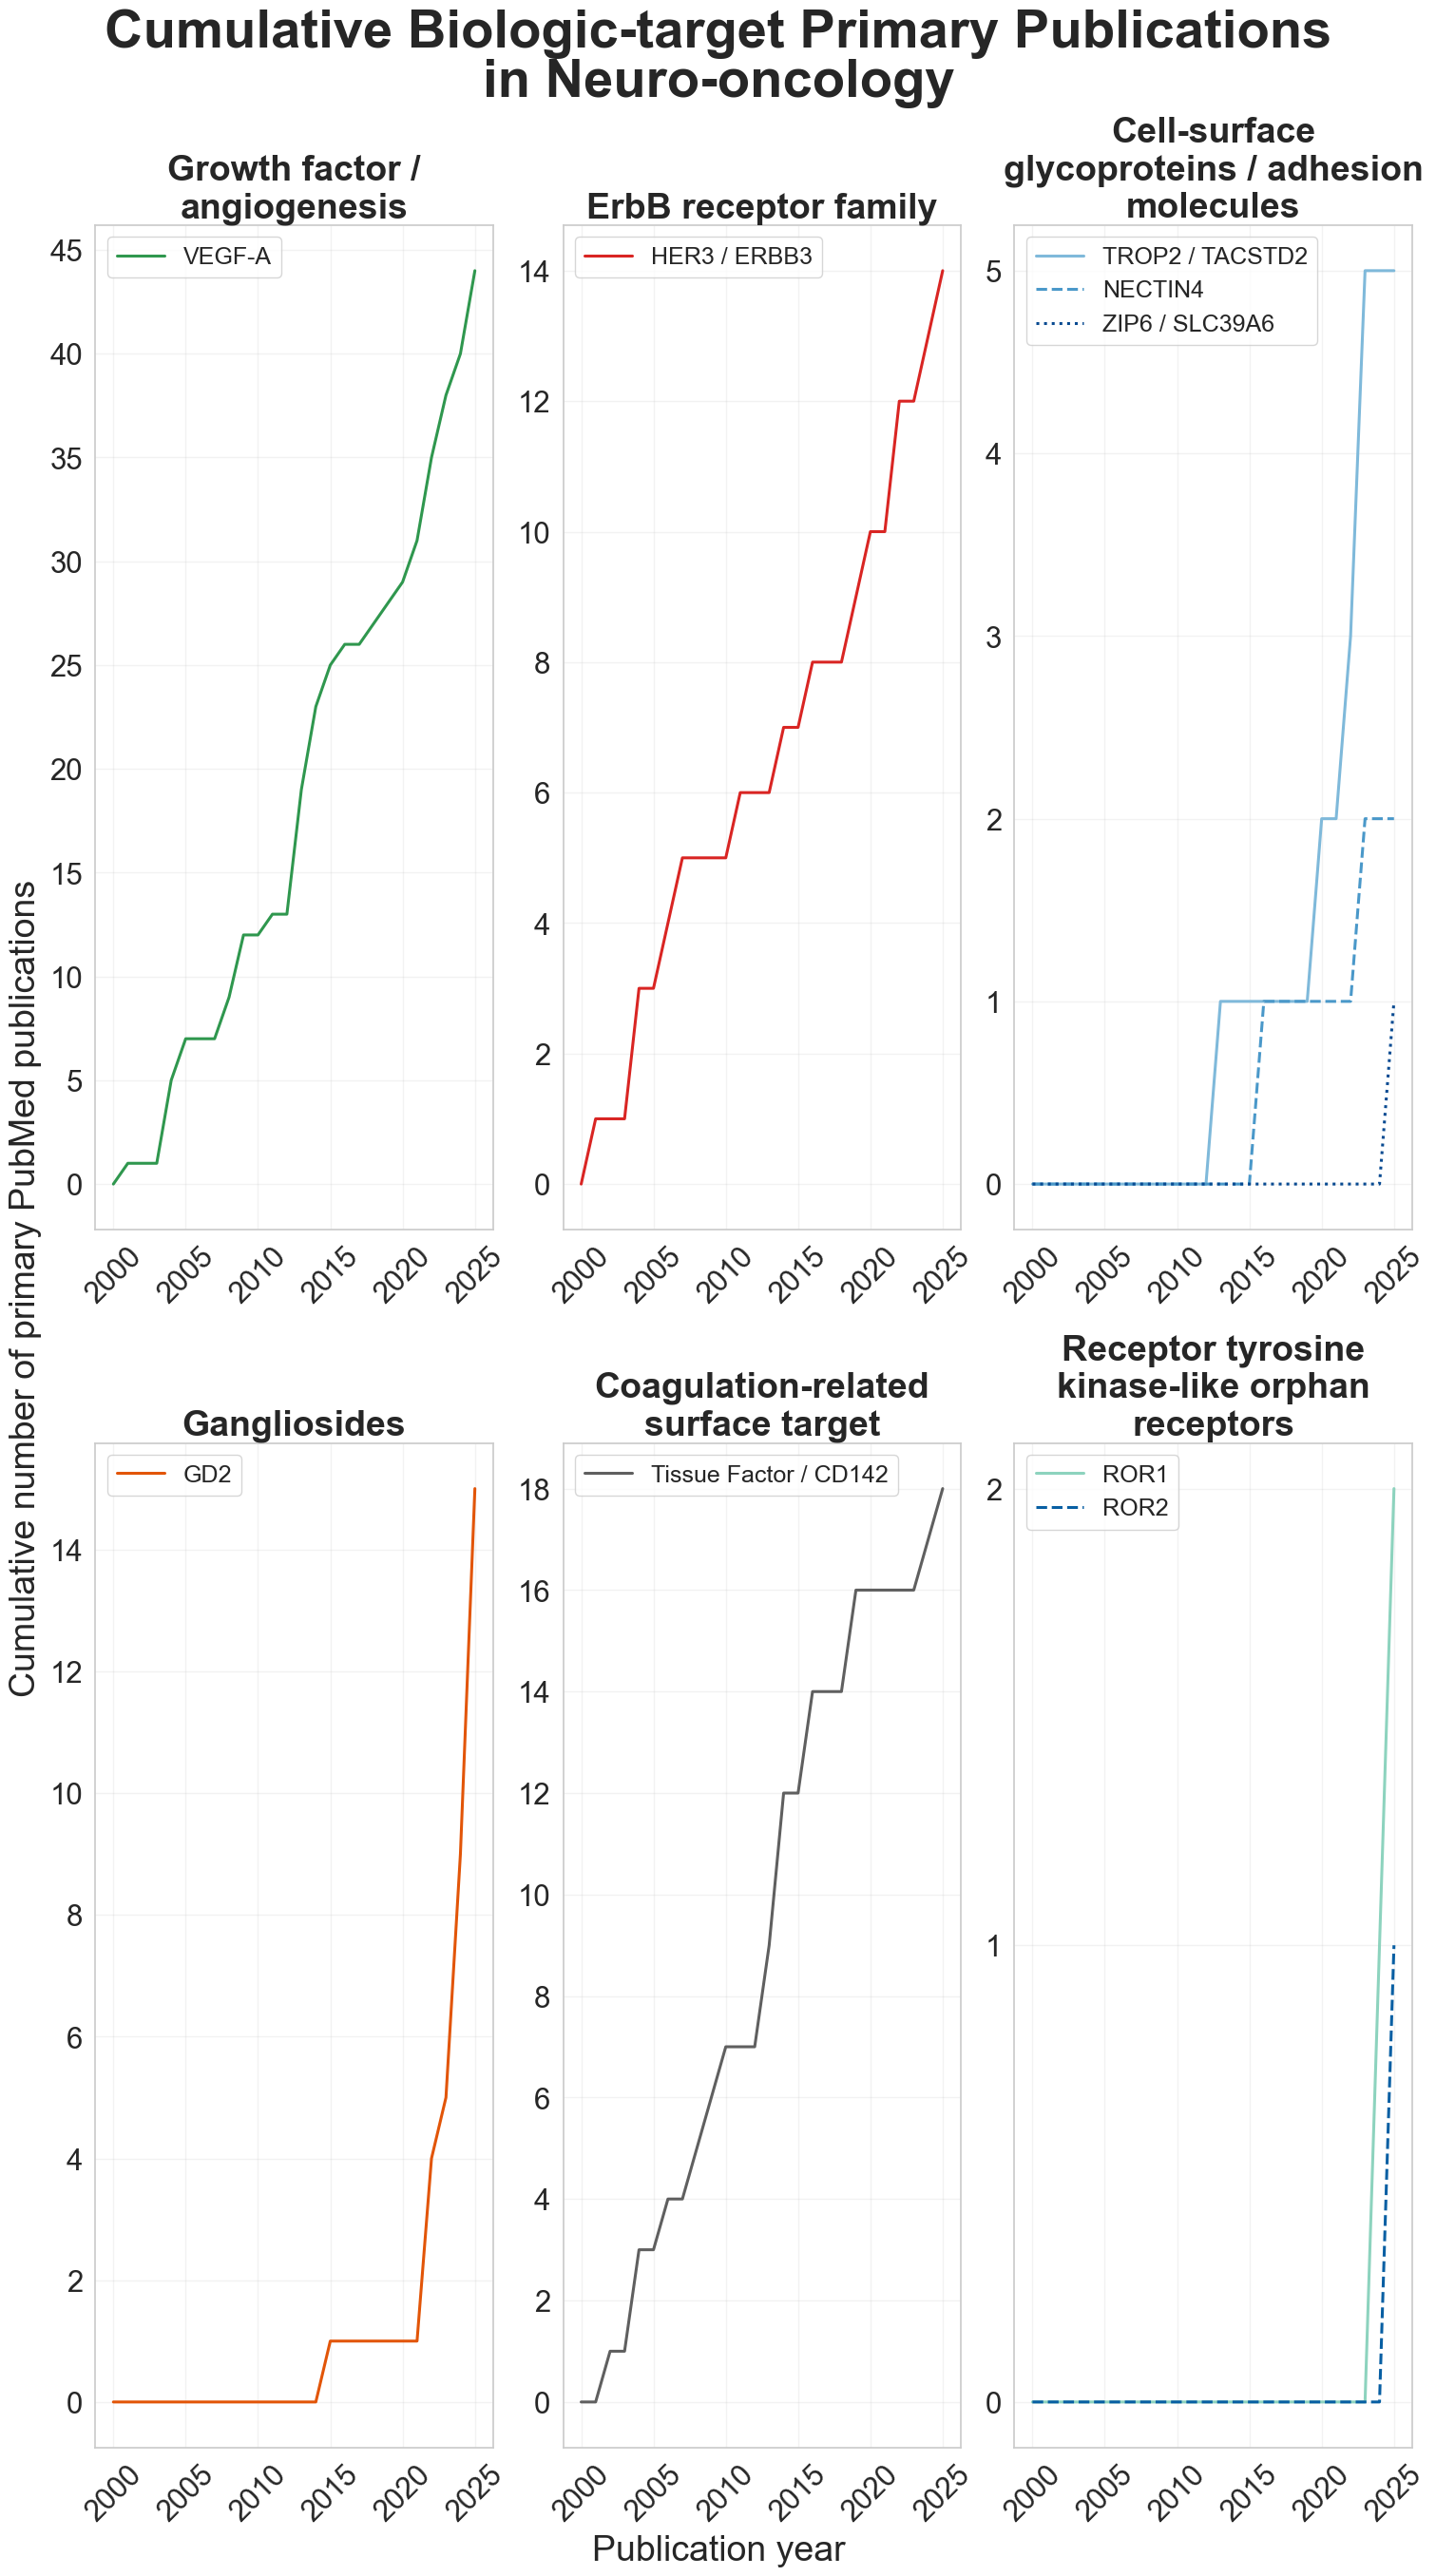

In [38]:
plot_biologic_target_families(
    all_neuro_oncology_biologic_target_trends,
    "Cumulative Biologic-target Primary Publications in Neuro-oncology",
)
plt.show()


In [39]:
print("Fetching biologic-target trends for primary CNS tumors...")
primary_cns_biologic_target_trends = get_biologic_target_trends(
    "Primary CNS tumors",
    PRIMARY_CNS_DISEASE_CONTEXT,
)


Fetching biologic-target trends for primary CNS tumors...
Primary CNS tumors | Growth factor / angiogenesis | VEGF-A: 41 publications
Primary CNS tumors | ErbB receptor family | HER3 / ERBB3: 12 publications
Primary CNS tumors | Cell-surface glycoproteins / adhesion molecules | TROP2 / TACSTD2: 3 publications
Primary CNS tumors | Cell-surface glycoproteins / adhesion molecules | NECTIN4: 2 publications
Primary CNS tumors | Cell-surface glycoproteins / adhesion molecules | ALCAM / CD166: 0 publications
Primary CNS tumors | Cell-surface glycoproteins / adhesion molecules | ZIP6 / SLC39A6: 1 publications
Primary CNS tumors | Gangliosides | GD2: 15 publications
Primary CNS tumors | Folate receptor | FOLR1 / FRα: 0 publications
Primary CNS tumors | Claudins / tight-junction proteins | CLDN6: 0 publications
Primary CNS tumors | Claudins / tight-junction proteins | CLDN18.2: 0 publications
Primary CNS tumors | Coagulation-related surface target | Tissue Factor / CD142: 19 publications
Primary

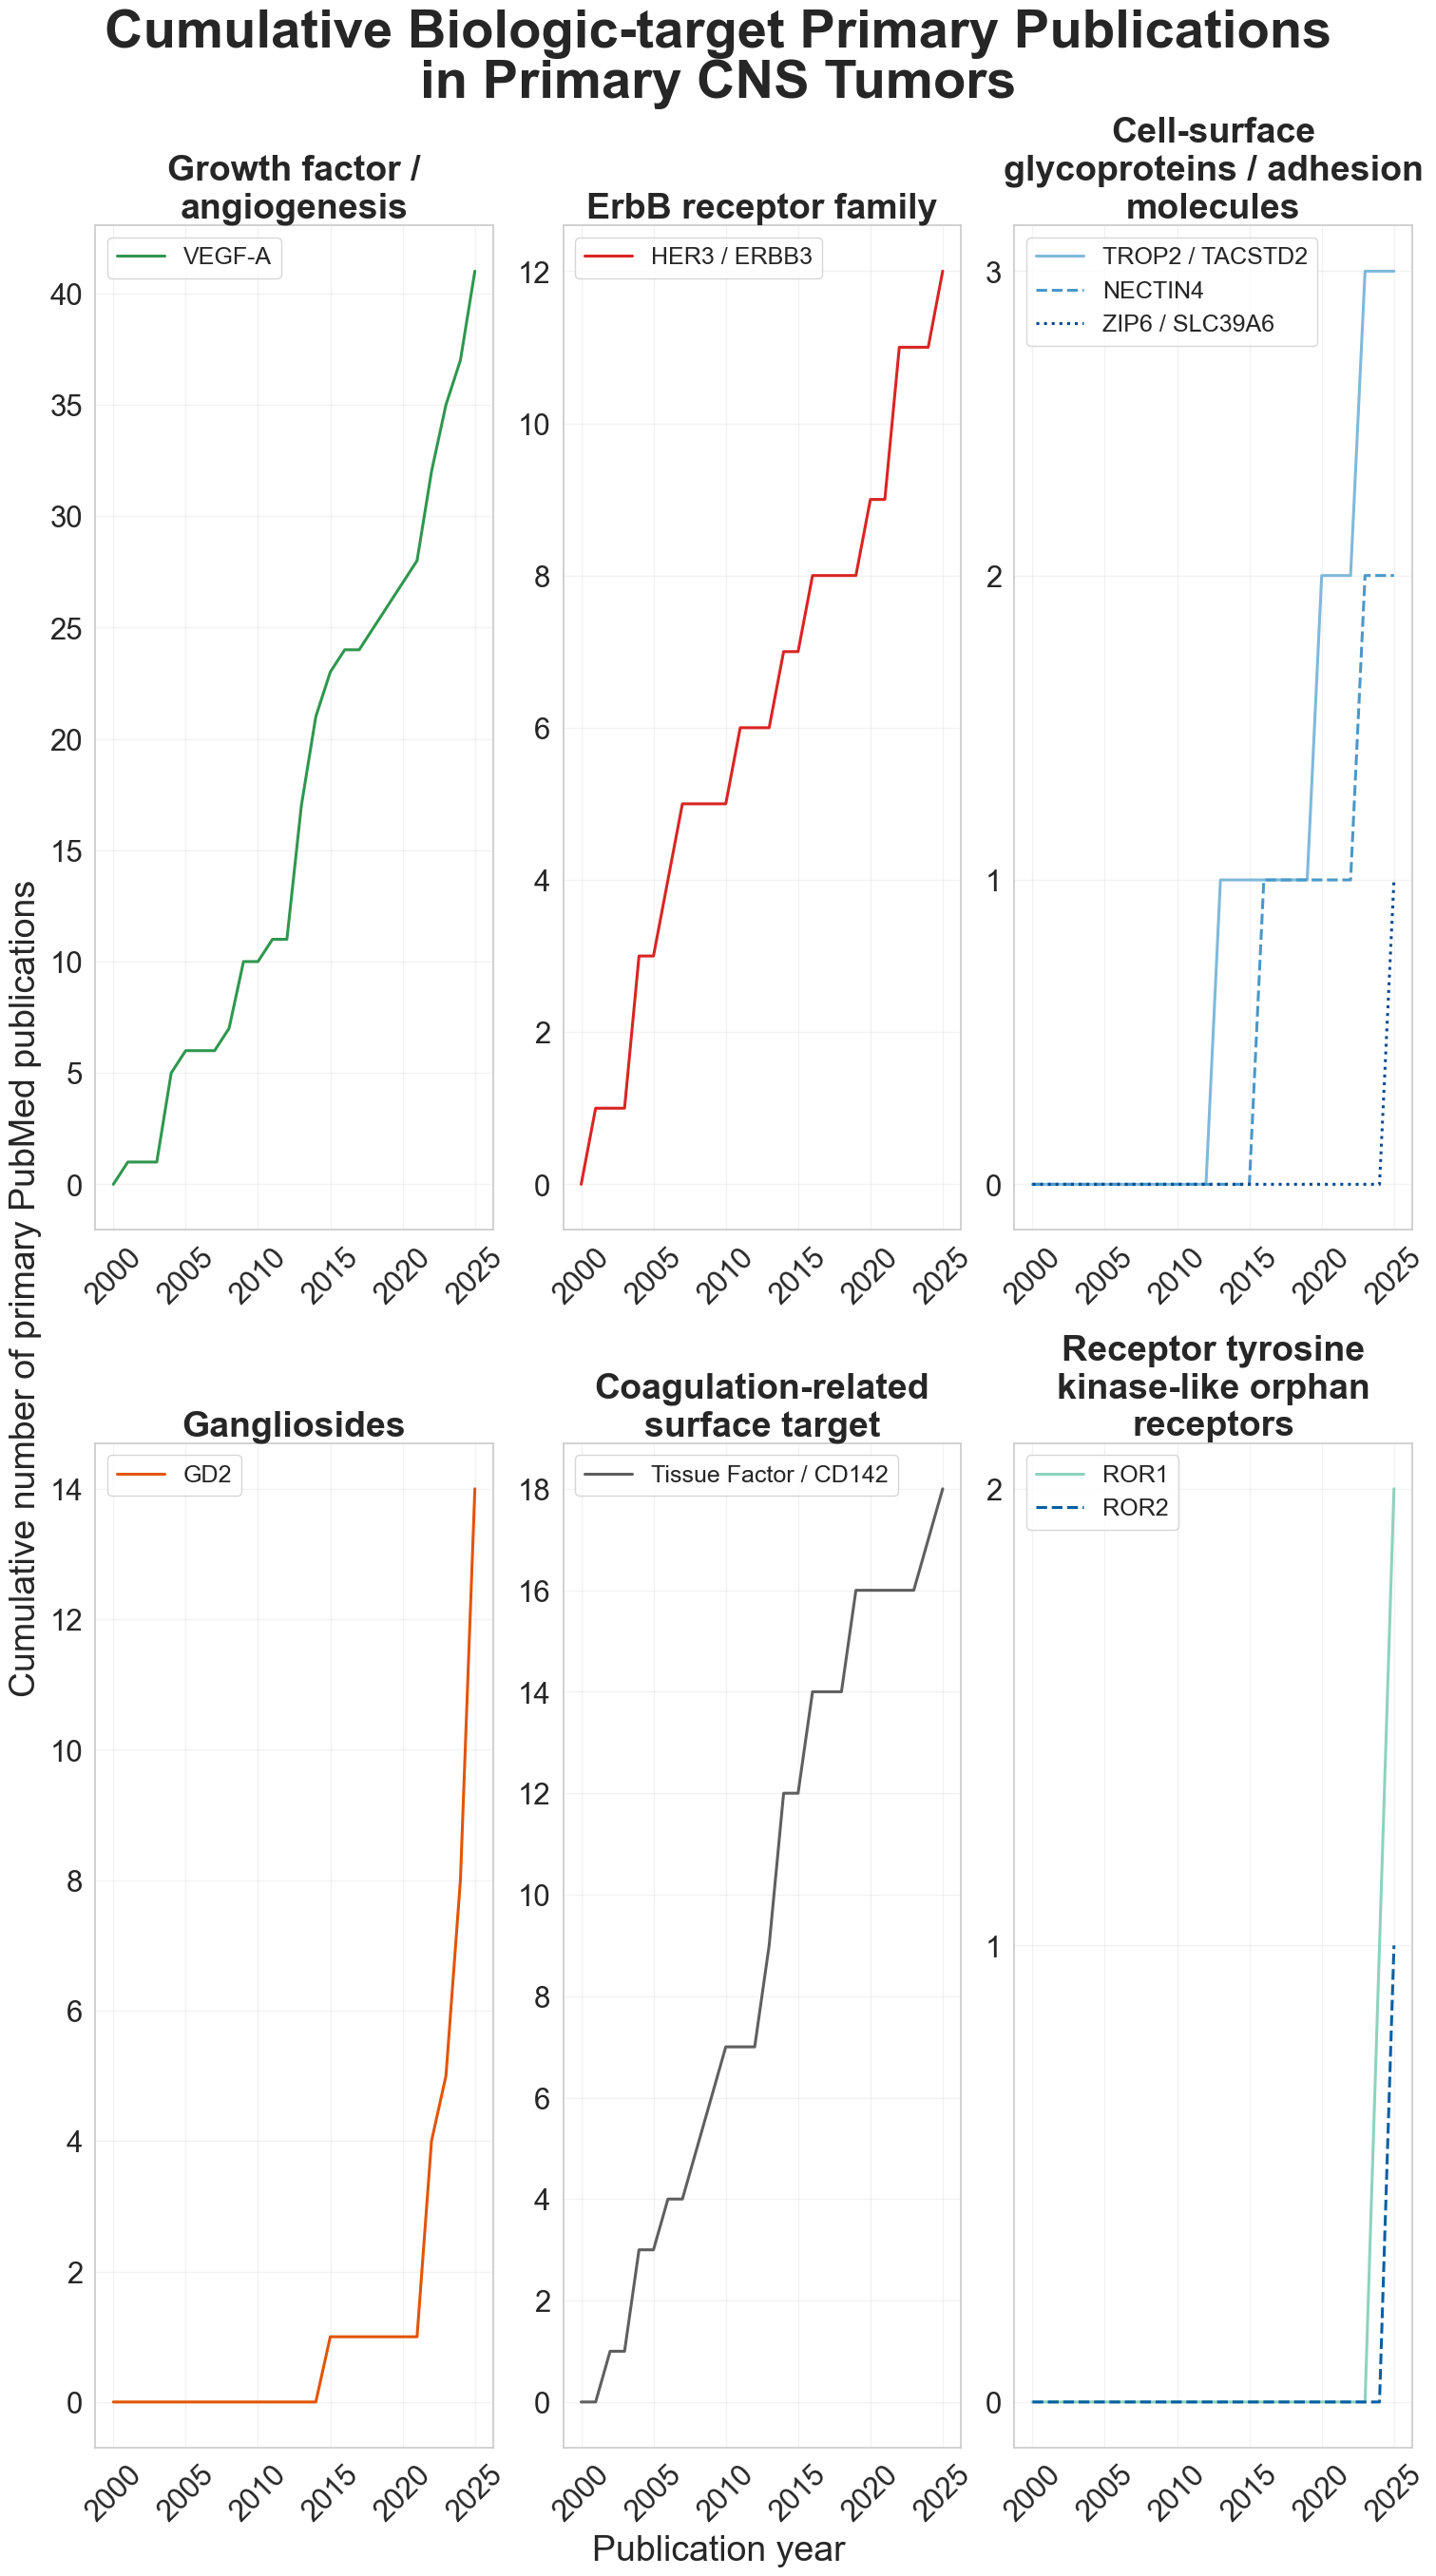

In [40]:
plot_biologic_target_families(
    primary_cns_biologic_target_trends,
    "Cumulative Biologic-target Primary Publications in Primary CNS Tumors",
)
plt.show()


In [41]:
print("Fetching biologic-target trends for CNS metastasis...")
cns_metastasis_biologic_target_trends = get_biologic_target_trends(
    "CNS metastasis",
    CNS_METASTASIS_DISEASE_CONTEXT,
)


Fetching biologic-target trends for CNS metastasis...
CNS metastasis | Growth factor / angiogenesis | VEGF-A: 4 publications
CNS metastasis | ErbB receptor family | HER3 / ERBB3: 2 publications
CNS metastasis | Cell-surface glycoproteins / adhesion molecules | TROP2 / TACSTD2: 3 publications
CNS metastasis | Cell-surface glycoproteins / adhesion molecules | NECTIN4: 0 publications
CNS metastasis | Cell-surface glycoproteins / adhesion molecules | ALCAM / CD166: 0 publications
CNS metastasis | Cell-surface glycoproteins / adhesion molecules | ZIP6 / SLC39A6: 0 publications
CNS metastasis | Gangliosides | GD2: 1 publications
CNS metastasis | Folate receptor | FOLR1 / FRα: 0 publications
CNS metastasis | Claudins / tight-junction proteins | CLDN6: 0 publications
CNS metastasis | Claudins / tight-junction proteins | CLDN18.2: 0 publications
CNS metastasis | Coagulation-related surface target | Tissue Factor / CD142: 1 publications
CNS metastasis | Receptor tyrosine kinase-like orphan recep

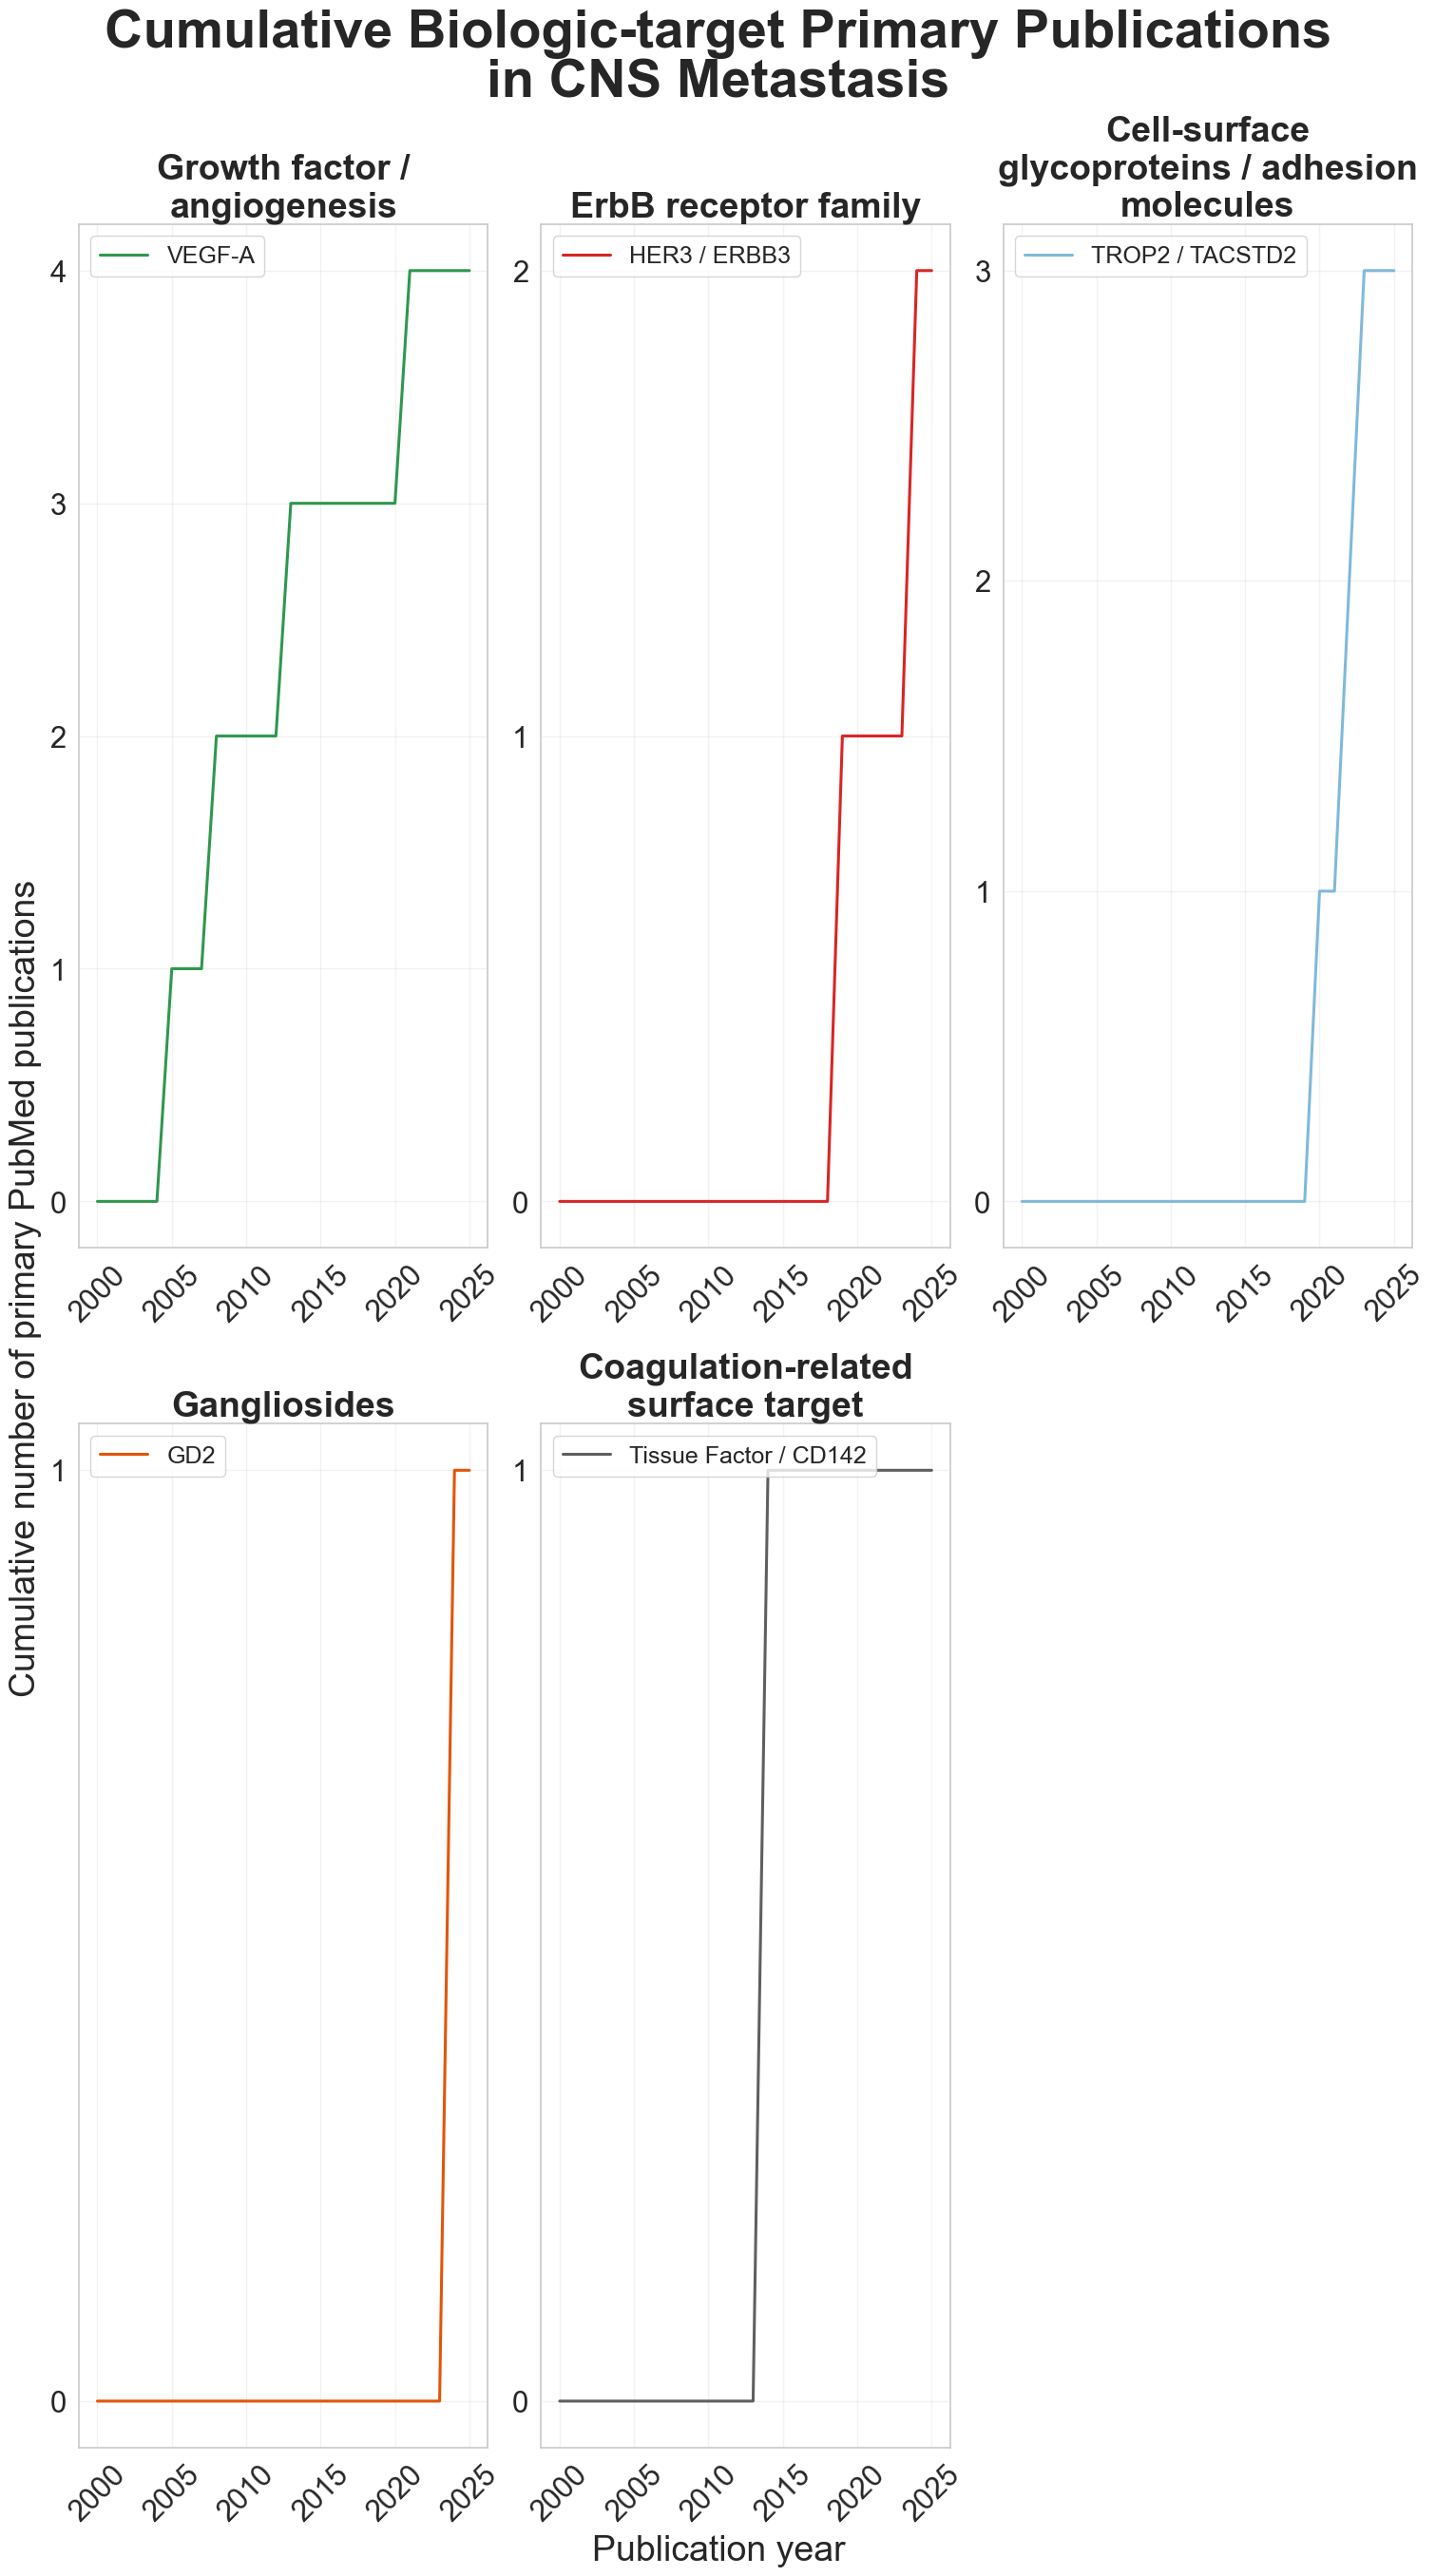

In [42]:
plot_biologic_target_families(
    cns_metastasis_biologic_target_trends,
    "Cumulative Biologic-target Primary Publications in CNS Metastasis",
)
plt.show()


## Immune and cell-therapy publication trends, 2000–2025

This section applies the same target-level method used for the small-molecule and biologic analyses. Each target or agent is searched through its supplied names and established aliases in PubMed titles and abstracts and must also match a family-specific therapy concept: checkpoint inhibition/immunotherapy, vaccination, chimeric antigen receptor therapy, or oncolytic virotherapy. The resulting therapy query is combined with the relevant neuro-oncology disease context and the 2000–2025 publication-date range.

Results use the same allowed publication-type filter (Clinical Study, the listed clinical-trial types, Multicenter Study, or Journal Article) and exclude Review, Systematic Review, and Meta-Analysis records. The family-panel figures show each therapy or target separately, use a shared color scheme within each family, and place legends consistently in the upper-left. Within each context, series with zero publications across the full interval are omitted. Separate figures are shown for overall neuro-oncology, primary CNS tumors, and CNS metastasis.


In [43]:
IMMUNE_CELL_THERAPY_FAMILIES = {
    "Immune checkpoint targets": {
        "PD-1 / PDCD1": [
            "PD-1",
            "PDCD1",
            "programmed cell death protein 1",
            "programmed death-1",
        ],
        "PD-L1 / CD274": [
            "PD-L1",
            "PDL1",
            "CD274",
            "programmed death-ligand 1",
            "programmed death ligand 1",
        ],
        "CTLA-4": [
            "CTLA-4",
            "CTLA4",
            "cytotoxic T-lymphocyte-associated protein 4",
        ],
        "TIM-3 / HAVCR2": [
            "TIM-3",
            "TIM3",
            "HAVCR2",
            "T-cell immunoglobulin and mucin-domain containing-3",
        ],
        "LAG-3": ["LAG-3", "LAG3", "lymphocyte activation gene 3"],
    },
    "Cancer vaccine targets": {
        "WT1": ["WT1", "Wilms tumor 1"],
        "CMV pp65 / UL83": ["CMV pp65", "cytomegalovirus pp65", "UL83"],
        "BCAN": ["BCAN", "brevican"],
        "CSPG4": ["CSPG4", "chondroitin sulfate proteoglycan 4"],
        "FABP7": ["FABP7", "fatty acid binding protein 7", "brain lipid-binding protein"],
        "IGF2BP3": [
            "IGF2BP3",
            "insulin-like growth factor 2 mRNA-binding protein 3",
        ],
        "NLGN4X": ["NLGN4X", "neuroligin 4 X-linked"],
        "NRCAM": ["NRCAM", "neuronal cell adhesion molecule"],
        "PTPRZ1": ["PTPRZ1", "protein tyrosine phosphatase receptor type Z1"],
        "TNC": ["TNC", "tenascin-C"],
        "BIRC5 / Survivin": [
            "BIRC5",
            "Survivin",
            "baculoviral IAP repeat containing 5",
        ],
    },
    "CAR-T": {
        "IL13Rα2 CAR-T": [
            "IL13Rα2",
            "IL13Ralpha2",
            "IL13RA2",
            "interleukin-13 receptor alpha 2",
        ],
        "EGFRvIII CAR-T": ["EGFRvIII", "EGFR variant III"],
        "HER2 CAR-T": ["HER2", "ERBB2"],
        "EphA2 CAR-T": ["EphA2", "EPHA2"],
        "GD2 CAR-T": ["GD2", "disialoganglioside GD2"],
        "B7-H3 CAR-T": ["B7-H3", "CD276"],
        "Chlorotoxin CAR-T": ["Chlorotoxin", "CLTX"],
        "CD317 CAR-T": ["CD317", "BST2", "tetherin"],
        "TanCAR / Tandem CAR-T": [
            "TanCAR",
            "TanCART",
            "Tandem CAR",
            "tandem chimeric antigen receptor",
        ],
    },
    "Oncolytic virus": {
        "DNX-2401 / Delta-24-RGD": [
            "DNX-2401",
            "DNX2401",
            "Delta-24-RGD",
            "Delta24-RGD",
        ],
        "PVSRIPO": ["PVSRIPO", "l poliovirus:rhinovirus chimera"],
        "G47Δ": ["G47Δ", "G47-delta", "G47delta", "teserpaturev"],
        "Toca 511": ["Toca 511", "vocimagene amiretrorepvec"],
        "ONYX-015": ["ONYX-015", "dl1520"],
        "Reovirus": ["Reovirus", "oncolytic reovirus", "pelareorep"],
        "Parvovirus": ["Parvovirus", "H-1 parvovirus", "ParvOryx"],
        "Newcastle Disease Virus": [
            "Newcastle Disease Virus",
            "oncolytic Newcastle disease virus",
            "NDV",
        ],
    },
}

IMMUNE_CELL_THERAPY_QUALIFIERS = {
    "Immune checkpoint targets": [
        "immune checkpoint inhibitor",
        "checkpoint inhibitor",
        "immune checkpoint blockade",
        "checkpoint blockade",
        "immunotherapy",
    ],
    "Cancer vaccine targets": [
        "cancer vaccine",
        "tumor vaccine",
        "peptide vaccine",
        "dendritic cell vaccine",
        "vaccine",
        "vaccination",
        "immunization",
    ],
    "CAR-T": [
        "CAR-T",
        "CAR T",
        "CAR T-cell",
        "CAR T cell",
        "chimeric antigen receptor",
    ],
    "Oncolytic virus": [
        "oncolytic virus",
        "oncolytic viruses",
        "oncolytic virotherapy",
        "oncolytic viral therapy",
        "virotherapy",
        "viral therapy",
    ],
}

IMMUNE_CELL_THERAPY_COLORMAPS = {
    "Immune checkpoint targets": "Reds",
    "Cancer vaccine targets": "Blues",
    "CAR-T": "Purples",
    "Oncolytic virus": "Greens",
}


def build_immune_cell_therapy_query(family, aliases):
    target_query = build_target_query(aliases)
    qualifier_query = build_target_query(
        IMMUNE_CELL_THERAPY_QUALIFIERS[family]
    )
    return f"({target_query}) AND ({qualifier_query})"


def get_therapy_query_year_counts(
    context_query,
    therapy_query,
    start_year=2000,
    end_year=2025,
    force_refresh=False,
):
    search_query = (
        f"({context_query}) AND ({therapy_query}) "
        f"AND ({start_year}:{end_year}[pdat]) "
        f"AND {PRIMARY_LITERATURE_FILTER}"
    )
    normalized_query = _normalize_pubmed_query(search_query)
    query_key = _pubmed_query_key(search_query)

    if not force_refresh:
        with _open_pubmed_cache() as connection:
            cached = connection.execute(
                """
                SELECT yearly_counts_json, total_records
                FROM target_year_counts
                WHERE query_key = ?
                """,
                (query_key,),
            ).fetchone()
        if cached is not None:
            yearly_counts = {
                int(year): int(count)
                for year, count in json.loads(cached[0]).items()
            }
            return yearly_counts, int(cached[1])

    search_record = read_entrez_with_retries(
        lambda: Entrez.esearch(
            db="pubmed",
            term=search_query,
            retmax=0,
            usehistory="y",
        ),
        "immune/cell-therapy search",
    )
    total_records = int(search_record["Count"])
    yearly_counts = {year: 0 for year in range(start_year, end_year + 1)}
    batch_size = 1000
    for retstart in range(0, total_records, batch_size):
        summaries = read_entrez_with_retries(
            lambda retstart=retstart: Entrez.esummary(
                db="pubmed",
                query_key=search_record["QueryKey"],
                WebEnv=search_record["WebEnv"],
                retstart=retstart,
                retmax=batch_size,
            ),
            f"immune/cell-therapy summaries starting at {retstart}",
        )
        for summary in summaries:
            year_match = re.search(
                r"\b(19|20)\d{2}\b",
                str(summary.get("PubDate", "")),
            )
            if year_match:
                year = int(year_match.group(0))
                if year in yearly_counts:
                    yearly_counts[year] += 1

    with _open_pubmed_cache() as connection:
        connection.execute(
            """
            INSERT INTO target_year_counts
                (query_key, normalized_query, start_year, end_year,
                 yearly_counts_json, total_records, fetched_at)
            VALUES (?, ?, ?, ?, ?, ?, CURRENT_TIMESTAMP)
            ON CONFLICT(query_key) DO UPDATE SET
                normalized_query = excluded.normalized_query,
                start_year = excluded.start_year,
                end_year = excluded.end_year,
                yearly_counts_json = excluded.yearly_counts_json,
                total_records = excluded.total_records,
                fetched_at = CURRENT_TIMESTAMP
            """,
            (
                query_key,
                normalized_query,
                start_year,
                end_year,
                json.dumps(yearly_counts, sort_keys=True),
                total_records,
            ),
        )
    return yearly_counts, total_records


def get_immune_cell_therapy_trends(
    context_label,
    context_query,
    start_year=2000,
    end_year=2025,
):
    rows = []
    for family, targets in IMMUNE_CELL_THERAPY_FAMILIES.items():
        for target, aliases in targets.items():
            therapy_query = build_immune_cell_therapy_query(
                family,
                aliases,
            )
            yearly_counts, total_records = get_therapy_query_year_counts(
                context_query,
                therapy_query,
                start_year,
                end_year,
            )
            print(
                f"{context_label} | {family} | {target}: "
                f"{total_records:,} publications"
            )
            rows.extend(
                {
                    "Context": context_label,
                    "Family": family,
                    "Target": target,
                    "Year": year,
                    "Publications": count,
                }
                for year, count in yearly_counts.items()
            )
    return remove_zero_only_target_series(pd.DataFrame(rows))


def plot_immune_cell_therapy_families(data, title):
    families = [
        family for family in IMMUNE_CELL_THERAPY_FAMILIES
        if family in set(data["Family"])
    ]
    ncols = 2
    nrows = math.ceil(len(families) / ncols)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(15, 27),
        constrained_layout=True,
        squeeze=False,
    )
    line_styles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]
    for ax, family in zip(axes.flat, families):
        targets = [
            target for target in IMMUNE_CELL_THERAPY_FAMILIES[family]
            if target in set(data.loc[data["Family"] == family, "Target"])
        ]
        cmap = plt.get_cmap(IMMUNE_CELL_THERAPY_COLORMAPS[family])
        shade_positions = (
            np.linspace(0.35, 0.9, len(targets))
            if len(targets) > 1
            else [0.7]
        )
        for index, (target, shade_position) in enumerate(
            zip(targets, shade_positions)
        ):
            target_data = data[
                (data["Family"] == family) & (data["Target"] == target)
            ].sort_values("Year").copy()
            target_data["Cumulative publications"] = target_data["Publications"].cumsum()
            ax.plot(
                target_data["Year"],
                target_data["Cumulative publications"],
                label=target,
                color=cmap(shade_position),
                linestyle=line_styles[index % len(line_styles)],
                linewidth=2.1,
            )
        ax.set_title(textwrap.fill(family, width=24), fontsize=27, fontweight="bold")
        ax.set_xticks([2000, 2005, 2010, 2015, 2020, 2025])
        ax.tick_params(axis="x", rotation=45, labelsize=22.5)
        ax.tick_params(axis="y", labelsize=22.5)
        ax.grid(alpha=0.25)
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        ax.legend(
            loc="upper left",
            fontsize=18,
            frameon=True,
            ncol=1,
        )
    for ax in axes.flat[len(families):]:
        ax.set_visible(False)
    wrapped_title = textwrap.fill(title, width=42)
    fig.suptitle(wrapped_title, fontsize=40.5, fontweight="bold", linespacing=1.0)
    fig.supxlabel("Publication year", fontsize=27)
    fig.supylabel("Cumulative number of primary PubMed publications", fontsize=27)
    return fig


print("Fetching immune/cell-therapy trends for overall neuro-oncology...")
all_neuro_oncology_immune_cell_trends = get_immune_cell_therapy_trends(
    "Overall neuro-oncology",
    NEURO_ONCOLOGY_DISEASE_CONTEXT,
)


Fetching immune/cell-therapy trends for overall neuro-oncology...
Overall neuro-oncology | Immune checkpoint targets | PD-1 / PDCD1: 184 publications
Overall neuro-oncology | Immune checkpoint targets | PD-L1 / CD274: 159 publications
Overall neuro-oncology | Immune checkpoint targets | CTLA-4: 90 publications
Overall neuro-oncology | Immune checkpoint targets | TIM-3 / HAVCR2: 5 publications
Overall neuro-oncology | Immune checkpoint targets | LAG-3: 11 publications
Overall neuro-oncology | Cancer vaccine targets | WT1: 2 publications
Overall neuro-oncology | Cancer vaccine targets | CMV pp65 / UL83: 1 publications
Overall neuro-oncology | Cancer vaccine targets | BCAN: 0 publications
Overall neuro-oncology | Cancer vaccine targets | CSPG4: 0 publications
Overall neuro-oncology | Cancer vaccine targets | FABP7: 0 publications
Overall neuro-oncology | Cancer vaccine targets | IGF2BP3: 0 publications
Overall neuro-oncology | Cancer vaccine targets | NLGN4X: 0 publications
Overall neuro-

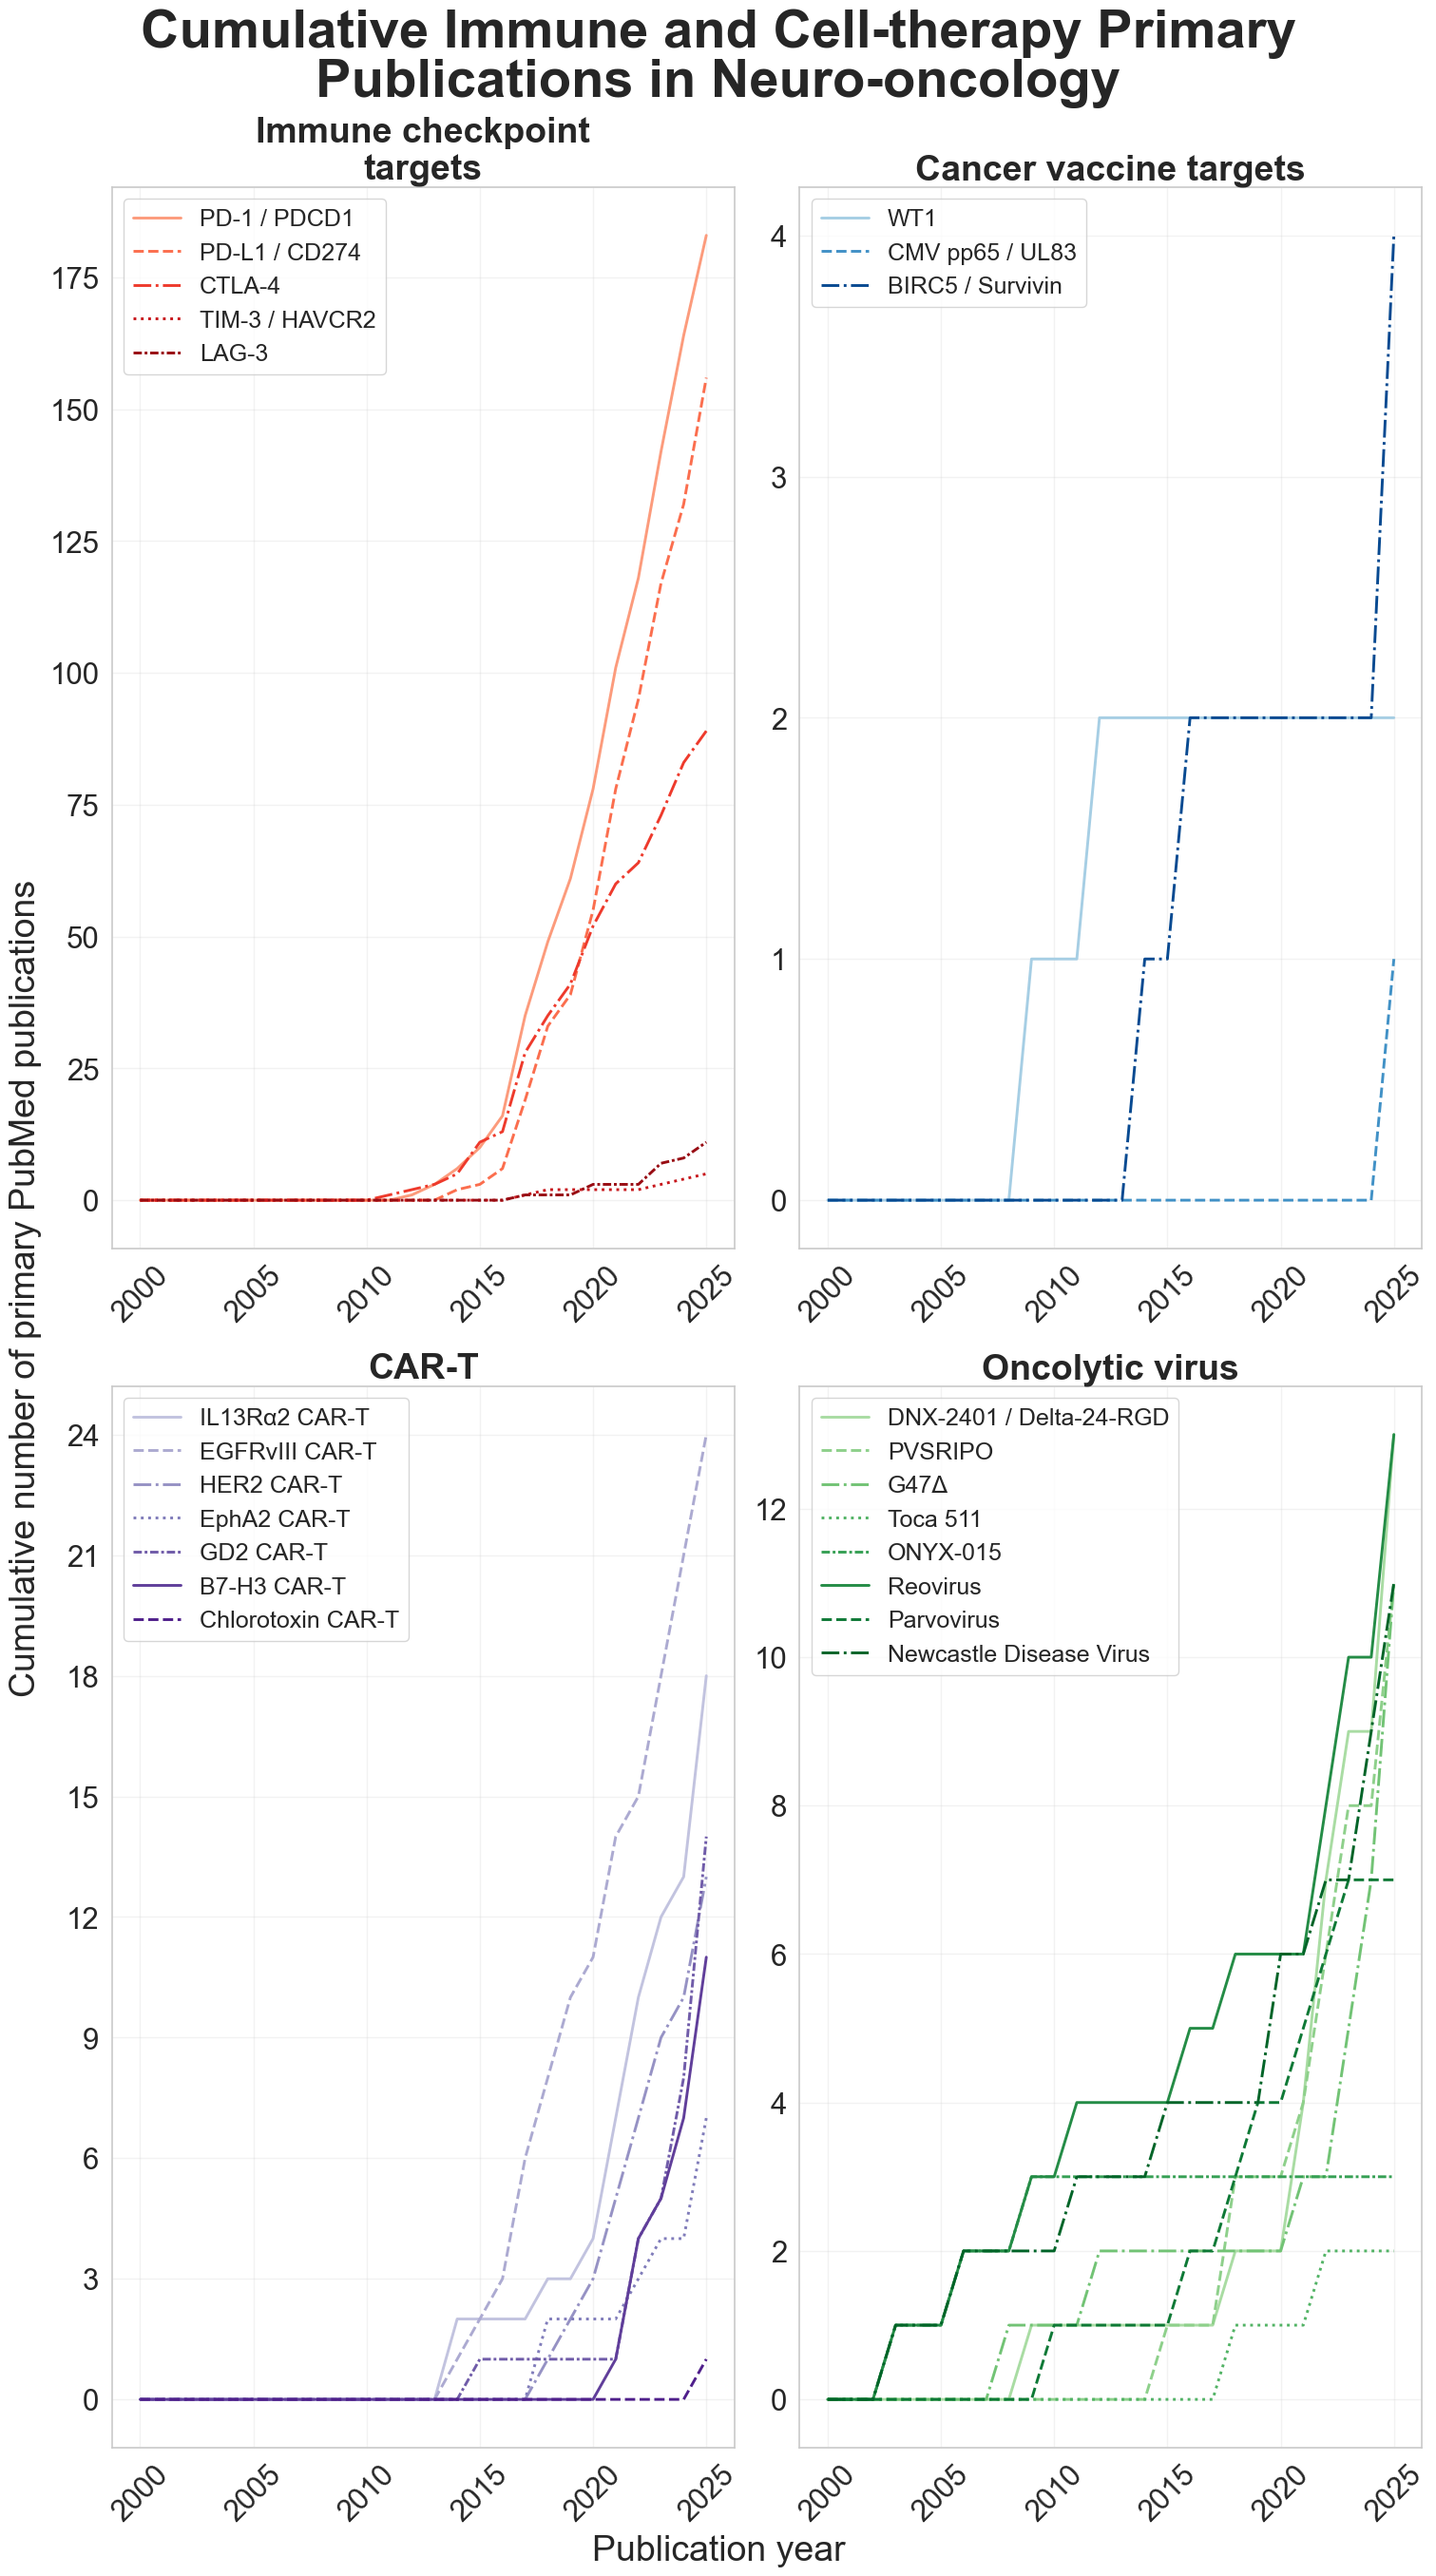

In [44]:
plot_immune_cell_therapy_families(
    all_neuro_oncology_immune_cell_trends,
    "Cumulative Immune and Cell-therapy Primary Publications in Neuro-oncology",
)
plt.show()


In [45]:
print("Fetching immune/cell-therapy trends for primary CNS tumors...")
primary_cns_immune_cell_trends = get_immune_cell_therapy_trends(
    "Primary CNS tumors",
    PRIMARY_CNS_DISEASE_CONTEXT,
)


Fetching immune/cell-therapy trends for primary CNS tumors...
Primary CNS tumors | Immune checkpoint targets | PD-1 / PDCD1: 102 publications
Primary CNS tumors | Immune checkpoint targets | PD-L1 / CD274: 90 publications
Primary CNS tumors | Immune checkpoint targets | CTLA-4: 45 publications
Primary CNS tumors | Immune checkpoint targets | TIM-3 / HAVCR2: 4 publications
Primary CNS tumors | Immune checkpoint targets | LAG-3: 4 publications
Primary CNS tumors | Cancer vaccine targets | WT1: 2 publications
Primary CNS tumors | Cancer vaccine targets | CMV pp65 / UL83: 1 publications
Primary CNS tumors | Cancer vaccine targets | BCAN: 0 publications
Primary CNS tumors | Cancer vaccine targets | CSPG4: 0 publications
Primary CNS tumors | Cancer vaccine targets | FABP7: 0 publications
Primary CNS tumors | Cancer vaccine targets | IGF2BP3: 0 publications
Primary CNS tumors | Cancer vaccine targets | NLGN4X: 0 publications
Primary CNS tumors | Cancer vaccine targets | NRCAM: 0 publications


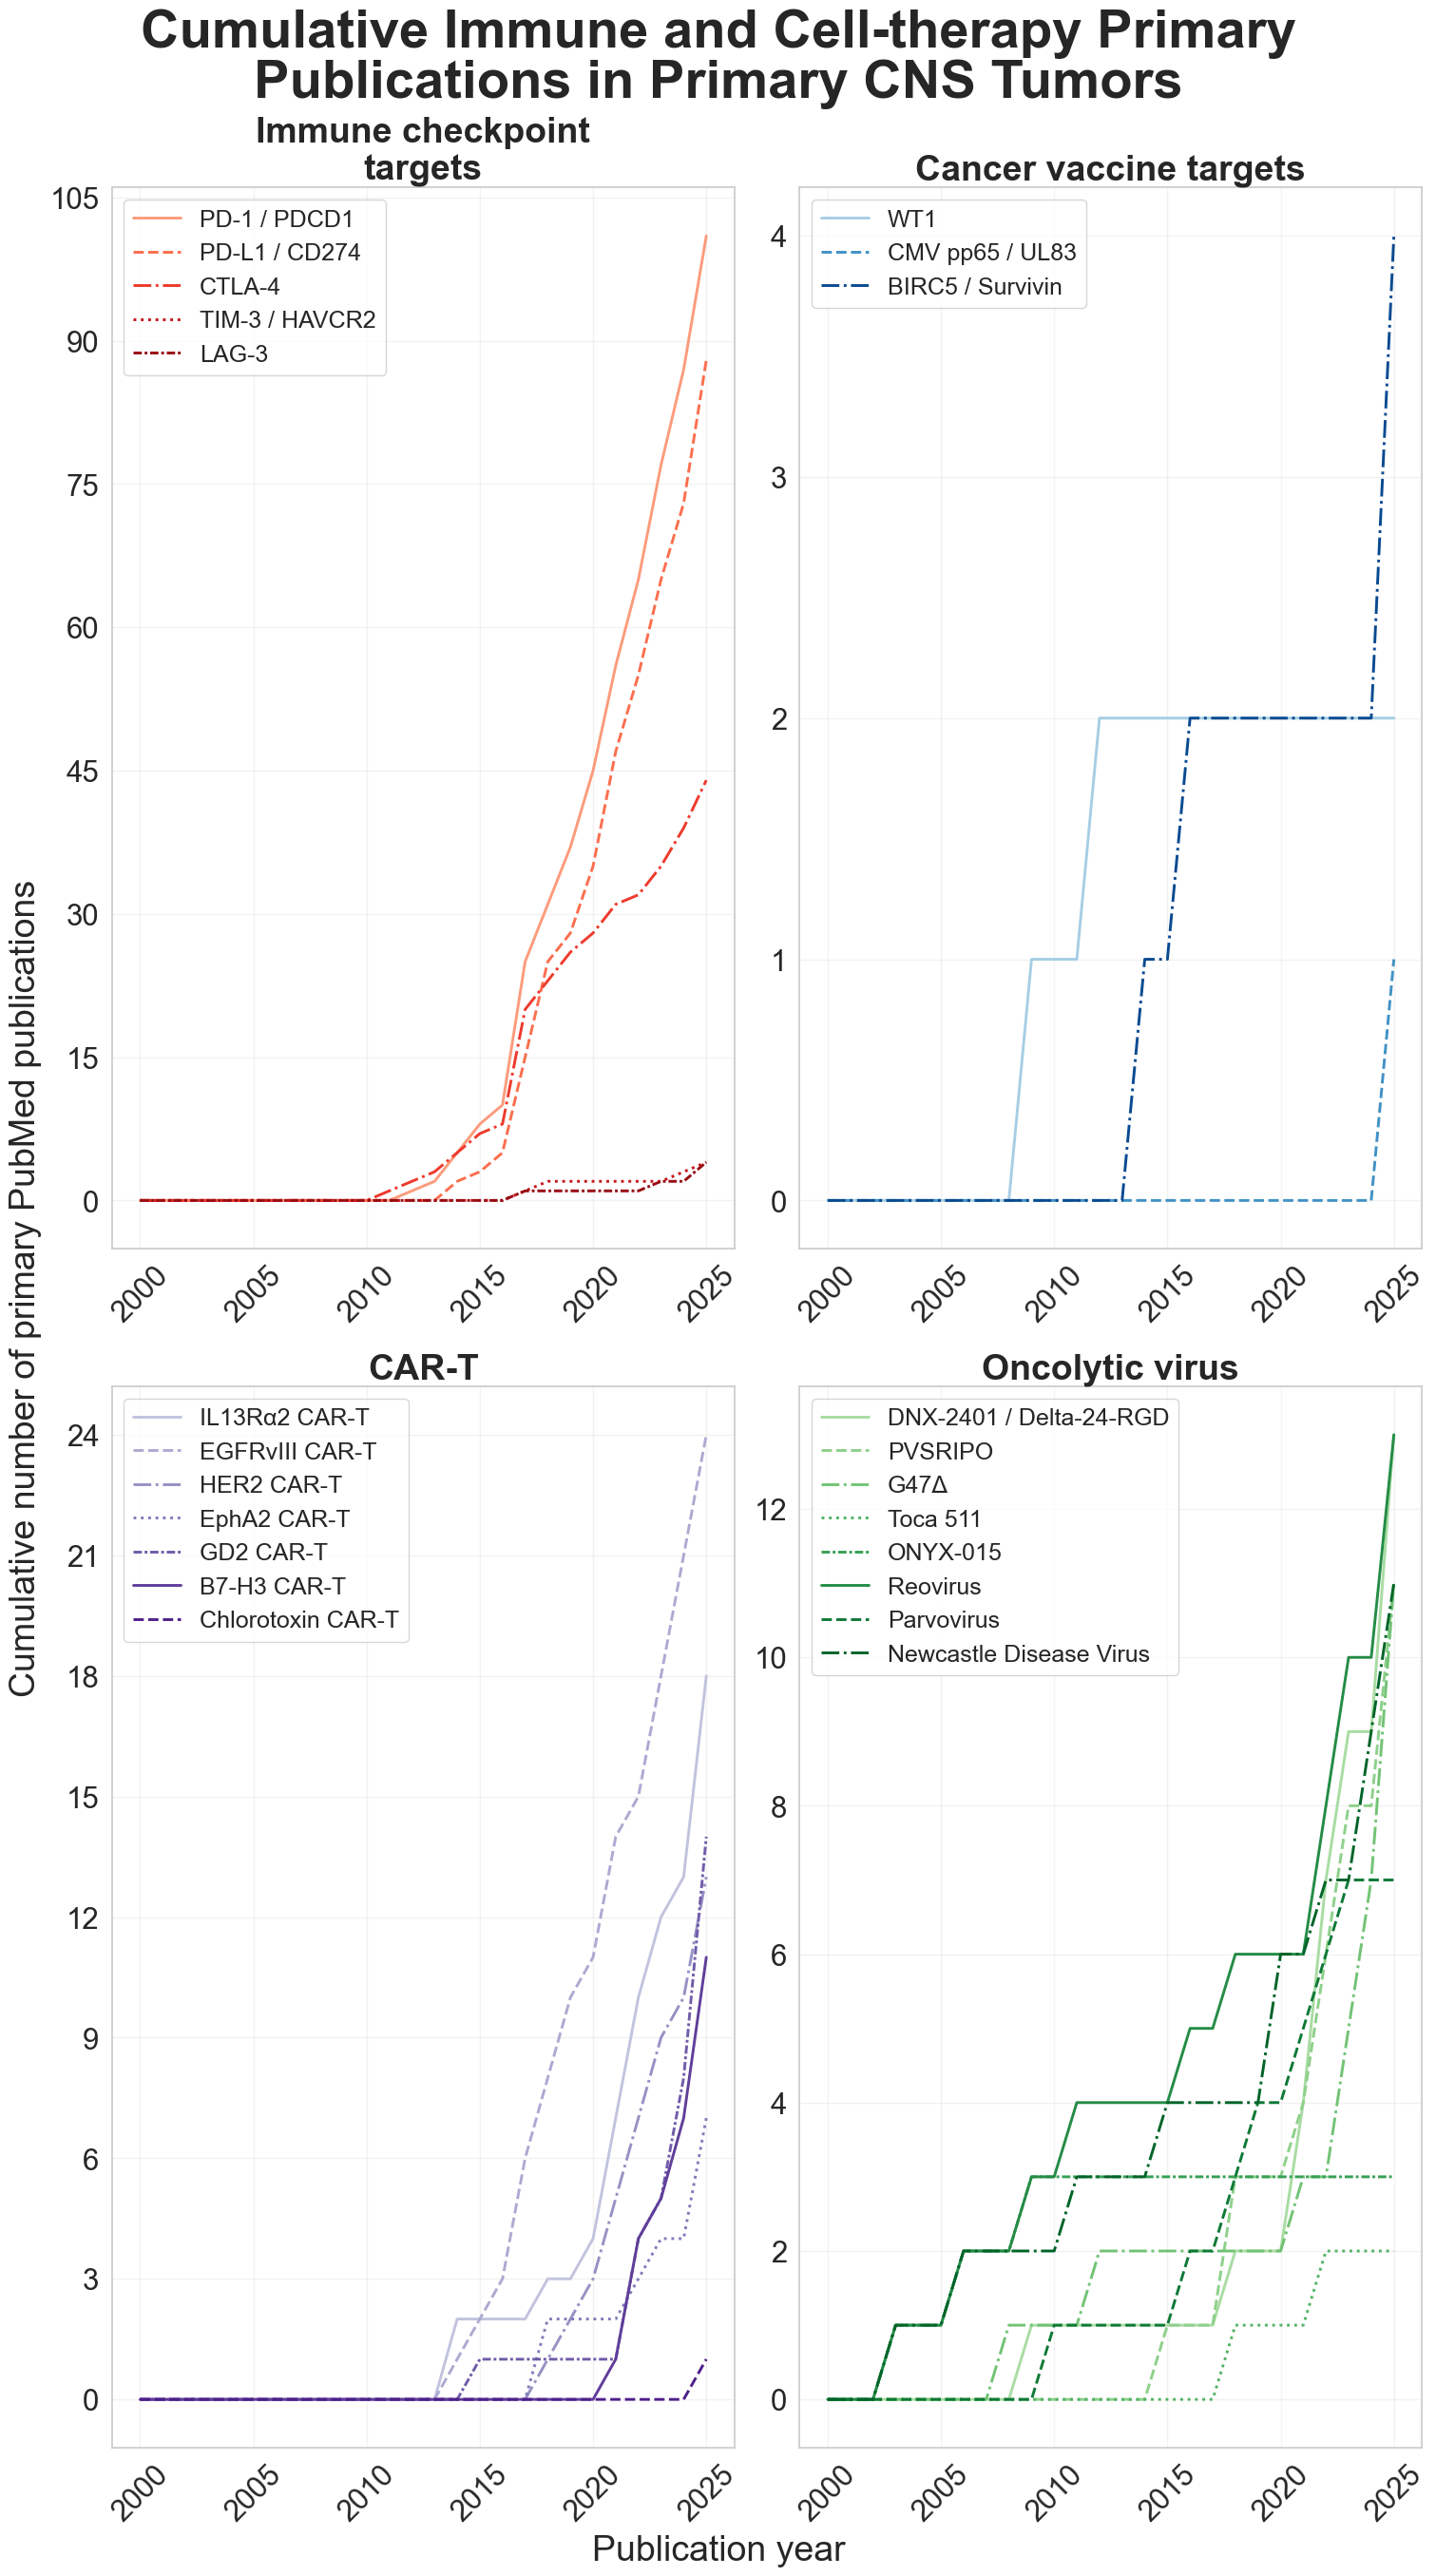

In [46]:
plot_immune_cell_therapy_families(
    primary_cns_immune_cell_trends,
    "Cumulative Immune and Cell-therapy Primary Publications in Primary CNS Tumors",
)
plt.show()


In [47]:
print("Fetching immune/cell-therapy trends for CNS metastasis...")
cns_metastasis_immune_cell_trends = get_immune_cell_therapy_trends(
    "CNS metastasis",
    CNS_METASTASIS_DISEASE_CONTEXT,
)


Fetching immune/cell-therapy trends for CNS metastasis...
CNS metastasis | Immune checkpoint targets | PD-1 / PDCD1: 84 publications
CNS metastasis | Immune checkpoint targets | PD-L1 / CD274: 70 publications
CNS metastasis | Immune checkpoint targets | CTLA-4: 47 publications
CNS metastasis | Immune checkpoint targets | TIM-3 / HAVCR2: 1 publications
CNS metastasis | Immune checkpoint targets | LAG-3: 7 publications
CNS metastasis | Cancer vaccine targets | WT1: 0 publications
CNS metastasis | Cancer vaccine targets | CMV pp65 / UL83: 0 publications
CNS metastasis | Cancer vaccine targets | BCAN: 0 publications
CNS metastasis | Cancer vaccine targets | CSPG4: 0 publications
CNS metastasis | Cancer vaccine targets | FABP7: 0 publications
CNS metastasis | Cancer vaccine targets | IGF2BP3: 0 publications
CNS metastasis | Cancer vaccine targets | NLGN4X: 0 publications
CNS metastasis | Cancer vaccine targets | NRCAM: 0 publications
CNS metastasis | Cancer vaccine targets | PTPRZ1: 0 publi

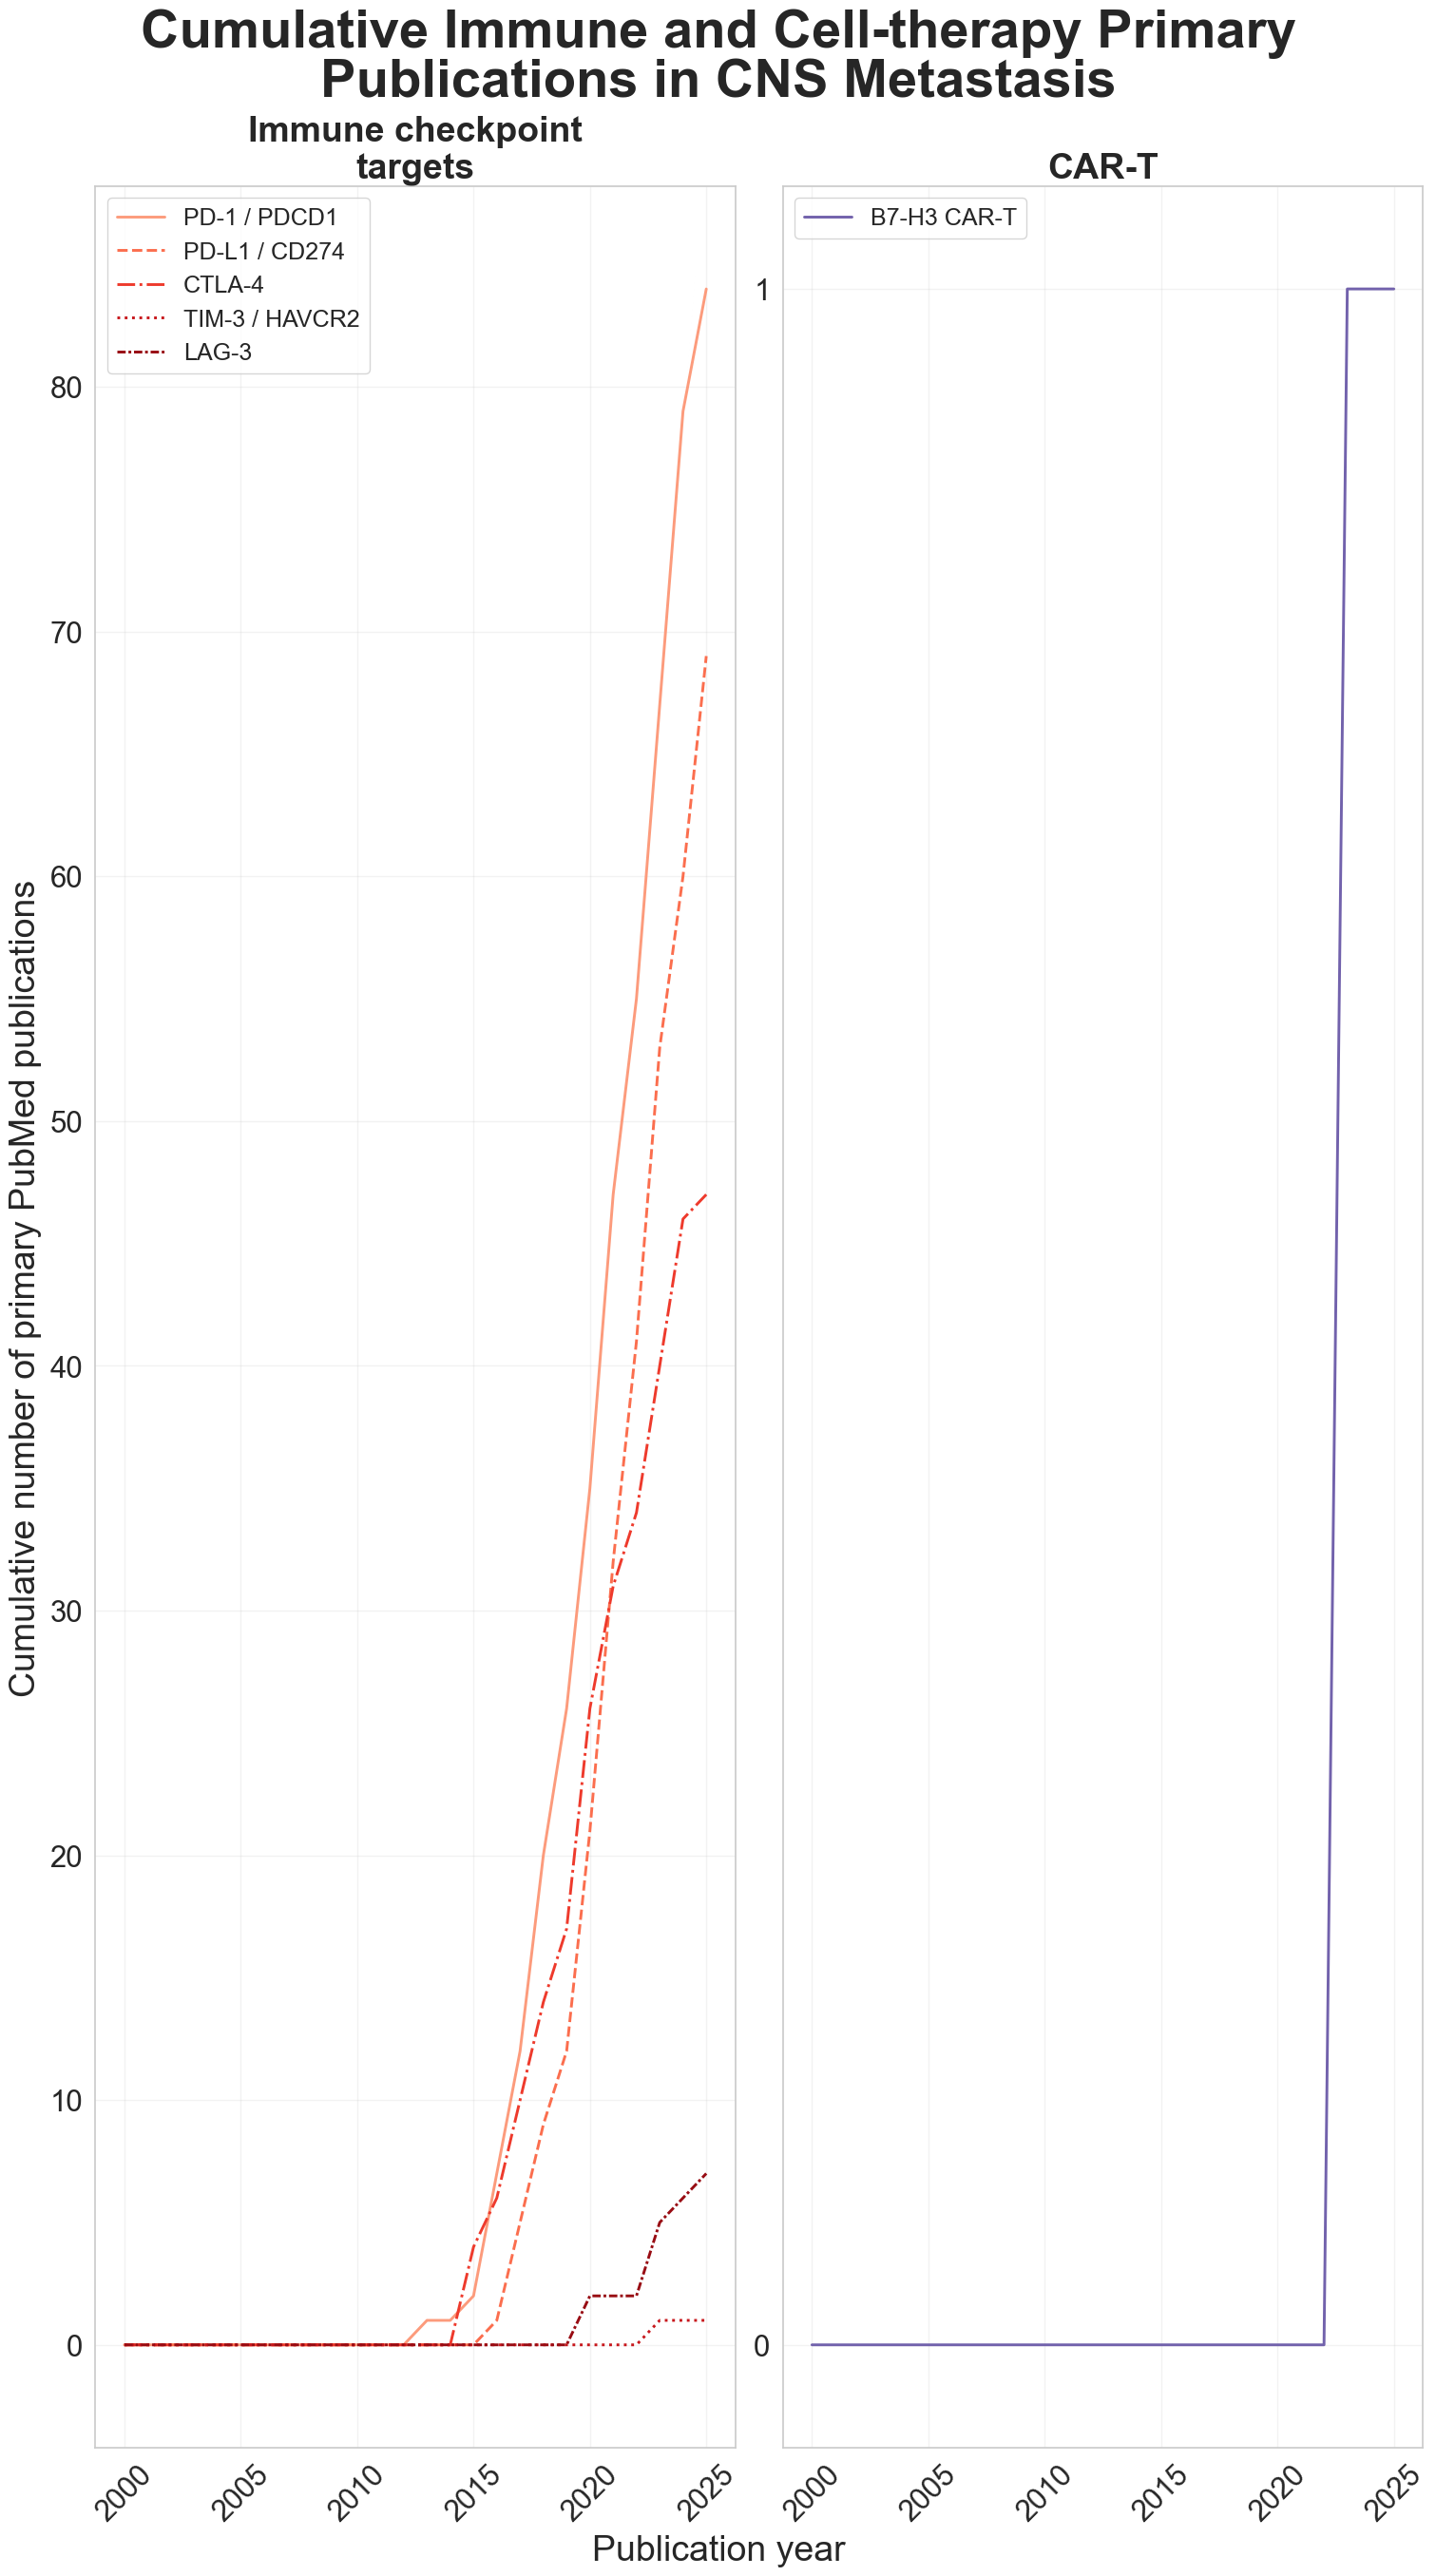

In [48]:
plot_immune_cell_therapy_families(
    cns_metastasis_immune_cell_trends,
    "Cumulative Immune and Cell-therapy Primary Publications in CNS Metastasis",
)
plt.show()


### Immune and cell-therapy trend summary

- **Checkpoint studies dominate the literature.** Under the updated publication-type filter, overall neuro-oncology contains 184 PD-1/PDCD1, 159 PD-L1/CD274, and 90 CTLA-4 primary-literature records. Most PD-1 and PD-L1 records were published during 2021–2025, indicating continued recent growth. CNS-metastasis literature is likewise dominated by PD-1, PD-L1, and CTLA-4.
- **CAR-T research is concentrated in primary CNS tumors.** EGFRvIII CAR-T appears earliest and has the largest cumulative primary-CNS count, while IL13Rα2, GD2, HER2, B7-H3, and EphA2 CAR-T publications are weighted strongly toward 2021–2025. B7-H3 CAR-T first appears in this search in 2021. Only one nonzero CAR-T series, B7-H3 CAR-T, remains in the CNS-metastasis panel.
- **Oncolytic-virus research is smaller but spans a longer period.** Reovirus and Newcastle disease virus records begin in 2003. DNX-2401/Delta-24-RGD, PVSRIPO, and G47Δ show a more recent concentration, with most matching records published during 2021–2025. These series are confined to the primary-CNS context under the current disease definitions.
- **Therapy-qualified cancer-vaccine target literature is sparse.** BIRC5/Survivin, WT1, and CMV pp65/UL83 are the only nonzero vaccine-target series after applying the primary-literature, neuro-oncology, and vaccine-therapy requirements.

Counts above are the final cumulative totals for 2000–2025. Targets with zero publications across the full interval are omitted from each context-specific figure.
